**LOAD** OF ICRSAR DATA

In [ ]:
import pandas as pd

# Load your CSV file
df = pd.read_csv("/content/ICRISAT-District Level Data.csv")

# Display column names
print(df.columns)


Index(['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name',
       'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)',
       'RICE YIELD (Kg per ha)', 'WHEAT AREA (1000 ha)',
       'WHEAT PRODUCTION (1000 tons)', 'WHEAT YIELD (Kg per ha)',
       'KHARIF SORGHUM AREA (1000 ha)',
       'KHARIF SORGHUM PRODUCTION (1000 tons)',
       'KHARIF SORGHUM YIELD (Kg per ha)', 'RABI SORGHUM AREA (1000 ha)',
       'RABI SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM YIELD (Kg per ha)',
       'SORGHUM AREA (1000 ha)', 'SORGHUM PRODUCTION (1000 tons)',
       'SORGHUM YIELD (Kg per ha)', 'PEARL MILLET AREA (1000 ha)',
       'PEARL MILLET PRODUCTION (1000 tons)', 'PEARL MILLET YIELD (Kg per ha)',
       'MAIZE AREA (1000 ha)', 'MAIZE PRODUCTION (1000 tons)',
       'MAIZE YIELD (Kg per ha)', 'FINGER MILLET AREA (1000 ha)',
       'FINGER MILLET PRODUCTION (1000 tons)',
       'FINGER MILLET YIELD (Kg per ha)', 'BARLEY AREA (1000 ha)',
       'BARLEY PRODUCTION (1000 tons)', 'BARLEY 

LOAD OF MONTHLY RAINFALL DATA

In [ ]:
import pandas as pd

# Load your CSV file
df = pd.read_csv("/content/rain.csv")

# Display column names
print(df.columns)


Index(['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec'],
      dtype='object')


MERGED DATA OF RAINFALL 1996 TO 2015

In [ ]:
import pandas as pd

# Load the datasets
icrisat_df = pd.read_csv('/content/ICRISAT-District Level Data.csv')
rain_df = pd.read_csv('/content/rain.csv')

# Standardize the state/subdivision name columns to uppercase for consistency
icrisat_df['State Name'] = icrisat_df['State Name'].str.strip().str.upper()
# Use 'SUBDIVISION' from rain_df as it seems to represent the state/region
rain_df['SUBDIVISION'] = rain_df['SUBDIVISION'].str.strip().str.upper()

# Rename 'YEAR' in rain_df for consistency if needed
# Assuming 'YEAR' is already in uppercase, if not, convert
rain_df['YEAR'] = rain_df['YEAR'].astype(int)

# Filter data between 1966 and 2015
icrisat_df = icrisat_df[(icrisat_df['Year'] >= 1966) & (icrisat_df['Year'] <= 2015)]
rain_df = rain_df[(rain_df['YEAR'] >= 1966) & (rain_df['YEAR'] <= 2015)]

# Merge datasets on 'State Name' (from icrisat_df) and 'SUBDIVISION' (from rain_df), and 'Year'/'YEAR'
merged_df = pd.merge(
    icrisat_df,
    rain_df,
    left_on=['State Name', 'Year'],
    right_on=['SUBDIVISION', 'YEAR'],  # Use 'SUBDIVISION' for rain_df
    how='inner'
)

# Select only relevant columns
# From icrisat_df: assuming columns like 'Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)'
# From rain_df: assuming columns like 'JAN', 'FEB', ..., 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec' and 'SUBDIVISION', 'YEAR'
columns_to_keep = [
    'Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name',
    'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)',
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC',
    'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec'
    # 'SUBDIVISION', 'YEAR' # You might want to keep these as well, but the original list didn't include them explicitly
]

final_df = merged_df[columns_to_keep]

# Save the merged dataset
final_df.to_csv('/content/merged_yield_rainfall_1966_2015.csv', index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


FITTING REGRESSION WITH VARIABILITY RATIO

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric
    for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Calculate the rainfall standard deviation for June-September
    def calc_rainfall_std(row):
        rainfall_months = [row['JUN'], row['JUL'], row['AUG'], row['SEP']]
        # Remove NaN values for accurate std calculation
        rainfall_months = [val for val in rainfall_months if pd.notna(val)]
        if len(rainfall_months) > 1:
            return np.std(rainfall_months, ddof=1)  # sample std
        else:
            return 0  # if only one or no valid months, std is zero

    # Apply the function for each row
    state_df['Rainfall_Std'] = state_df.apply(calc_rainfall_std, axis=1)

    # Calculate total rainfall for June-September
    state_df['Total_Rainfall_JuneSep'] = state_df[['JUN', 'JUL', 'AUG', 'SEP']].sum(axis=1, skipna=True)

    # Create the ratio variable
    # Handle division by zero
    state_df['Rainfall_Variability_Ratio'] = np.where(
        state_df['Total_Rainfall_JuneSep'] > 0,
        state_df['Rainfall_Std'] / state_df['Total_Rainfall_JuneSep'],
        0  # or np.nan, depending on your preference
    )

    # Prepare independent variables without district dummies
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'Rainfall_Variability_Ratio']]
    y = state_df['RICE YIELD (Kg per ha)']

    # Final conversions
    X = X.astype(np.float64)
    y = y.astype(np.float64)

    # Check if data is sufficient
    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit model
    try:
        model = sm.OLS(y, X).fit()
        print(f"\nRegression Summary for {state}:\n")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Regression Summary for CHHATTISGARH:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.639
Model:                                OLS   Adj. R-squared:                  0.635
Method:                     Least Squares   F-statistic:                     130.8
Date:                    Fri, 06 Jun 2025   Prob (F-statistic):           4.34e-64
Time:                            11:14:29   Log-Likelihood:                -2059.3
No. Observations:                     300   AIC:                             4129.
Df Residuals:                         295   BIC:                             4147.
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                                 coef    std err          

FITTING REGRESSION WITH RAIN STANDARD DEVIATION

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric
    for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Calculate the rainfall standard deviation for June-September
    def calc_rainfall_std(row):
        rainfall_months = [row['JUN'], row['JUL'], row['AUG'], row['SEP']]
        # Remove NaN values for accurate std calculation
        rainfall_months = [val for val in rainfall_months if pd.notna(val)]
        if len(rainfall_months) > 1:
            return np.std(rainfall_months, ddof=1)  # sample std
        else:
            return 0  # if only one or no valid months, std is zero

    # Apply the function for each row
    state_df['Rainfall_Std'] = state_df.apply(calc_rainfall_std, axis=1)

    # Prepare independent variables: only include 'Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'Rainfall_Std'
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'Rainfall_Std']]
    y = state_df['RICE YIELD (Kg per ha)']

    # Final conversions
    X = X.astype(np.float64)
    y = y.astype(np.float64)

    # Check if data is sufficient
    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit model
    try:
        model = sm.OLS(y, X).fit()
        print(f"\nRegression Summary for {state}:\n")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Regression Summary for CHHATTISGARH:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.639
Model:                                OLS   Adj. R-squared:                  0.634
Method:                     Least Squares   F-statistic:                     130.7
Date:                    Fri, 06 Jun 2025   Prob (F-statistic):           4.74e-64
Time:                            11:16:40   Log-Likelihood:                -2059.4
No. Observations:                     300   AIC:                             4129.
Df Residuals:                         295   BIC:                             4147.
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      

MULTILINEAR REGRESSION WITH COEFFICIENTS OF CONST,JUN-SEP,RIICE-AREA,YEAR

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric
    for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Prepare independent variables (excluding Rainfall_Std)
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year']]
    y = state_df['RICE YIELD (Kg per ha)']

    # Final conversions
    X = X.astype(np.float64)
    y = y.astype(np.float64)

    # Check if data is sufficient
    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit model
    try:
        model = sm.OLS(y, X).fit()
        print(f"\nRegression Summary for {state}:\n")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Regression Summary for CHHATTISGARH:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.638
Model:                                OLS   Adj. R-squared:                  0.635
Method:                     Least Squares   F-statistic:                     174.3
Date:                    Fri, 06 Jun 2025   Prob (F-statistic):           4.41e-65
Time:                            11:30:42   Log-Likelihood:                -2059.7
No. Observations:                     300   AIC:                             4127.
Df Residuals:                         296   BIC:                             4142.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      

INDIA LEVEL REGRESSION

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# Filter data for India
if 'Country' in df.columns:
    india_df = df[df['Country'].str.strip().str.upper() == 'INDIA']
else:
    # Assuming dataset is already for India
    india_df = df

# For each year, calculate aggregated variables
# For rainfall months, sum across all data points within the year
yearly_data = []

# Group by Year
grouped = india_df.groupby('Year')

for year, group in grouped:
    # Ensure numeric conversion
    group = group.copy()
    for col in ['RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        if col in group.columns:
            group[col] = pd.to_numeric(group[col], errors='coerce')
    # Aggregate rainfall
    rainfall_sum = group[['JUN', 'JUL', 'AUG', 'SEP']].sum()
    # Determine Jun-Sep indicator (if any rainfall)
    jun_sep_indicator = 1 if (rainfall_sum > 0).any() else 0
    # Aggregate other variables (mean or sum)
    rice_yield = group['RICE YIELD (Kg per ha)'].mean()
    rice_area = group['RICE AREA (1000 ha)'].sum()
    jun = rainfall_sum['JUN']
    jul = rainfall_sum['JUL']
    aug = rainfall_sum['AUG']
    sep = rainfall_sum['SEP']

    yearly_data.append({
        'Year': year,
        'RICE YIELD (Kg per ha)': rice_yield,
        'RICE AREA (1000 ha)': rice_area,
        'Jun-Sep': jun_sep_indicator,
        'JUN': jun,
        'JUL': jul,
        'AUG': aug,
        'SEP': sep
    })

# Create DataFrame
yearly_df = pd.DataFrame(yearly_data)

# Prepare predictors and response
X = yearly_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year']]
y = yearly_df['RICE YIELD (Kg per ha)']

# Convert to numeric
X = X.astype(np.float64)
y = y.astype(np.float64)

# Add constant
X = sm.add_constant(X, has_constant='add')

# Run regression
try:
    model = sm.OLS(y, X).fit()
    print("\nYear-wise Regression Results for All India:\n")
    print(model.summary())
except Exception as e:
    print(f"Error fitting the model for India: {e}")


Year-wise Regression Results for All India:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.951
Model:                                OLS   Adj. R-squared:                  0.949
Method:                     Least Squares   F-statistic:                     459.2
Date:                    Fri, 06 Jun 2025   Prob (F-statistic):           1.43e-31
Time:                            11:32:39   Log-Likelihood:                -301.04
No. Observations:                      50   AIC:                             608.1
Df Residuals:                          47   BIC:                             613.8
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

INDIA LEVEL REGRESSION WITH ALL MONTHS(JUNE TO SEPTEMBER)

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data - ENSURE df is defined in this block
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    # You might want to handle this error more gracefully than exiting
    # For a notebook, it's often better to just print the error and let the user
    # fix the file path or upload the file.
    # raise # Uncomment to raise the error instead of exiting
    # Or assign an empty DataFrame to prevent further errors:
    df = pd.DataFrame() # Assign empty DataFrame to allow the rest of the code to run without error if file is missing

if not df.empty:
    # Instead of creating a binary indicator, sum rainfall amounts for June-September
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    # Define all monthly columns to ensure they are checked/converted
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

    # Convert monthly columns to numeric
    for m_col in monthly_cols: # Iterate through all potential monthly columns
        if m_col in df.columns:
            # Use errors='coerce' to turn non-numeric values into NaN
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            # Warning if a standard monthly column is missing
            print(f"Warning: Monthly rainfall column '{m_col}' not found in the dataframe.")


    # Sum rainfall in June to September - use min_count=1 so if all are NaN, result is NaN
    # Check if the rainfall_months are actually in the DataFrame columns before summing
    existing_rainfall_months = [col for col in rainfall_months if col in df.columns]
    if existing_rainfall_months:
        df['Rainfall_JuneSep'] = df[existing_rainfall_months].sum(axis=1, min_count=1)
        print("'Rainfall_JuneSep' column created by summing June-September rainfall.")
    else:
        print("Warning: None of the June-September rainfall columns were found. 'Rainfall_JuneSep' will not be created.")
        # Create a placeholder column if needed to prevent errors later
        df['Rainfall_JuneSep'] = np.nan # Use NaN or 0 depending on how it's used later


    # --- Aggregation for All India at a Yearly Level ---
    # Assuming the dataset is already for India or represents all of India
    # If you need to filter for India first, add that step here
    # E.g., if 'Country' column exists: india_df = df[df['Country'].str.strip().str.upper() == 'INDIA'].copy()
    # Otherwise, assume df is the India-wide data.

    # Drop rows with missing values in critical aggregation columns
    # Check for existence of columns before dropping
    agg_subset_cols = ['Year', 'RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)', 'Rainfall_JuneSep']
    existing_agg_cols = [col for col in agg_subset_cols if col in df.columns]

    if len(existing_agg_cols) < len(agg_subset_cols):
        missing = set(agg_subset_cols) - set(existing_agg_cols)
        print(f"Warning: Missing columns required for yearly aggregation: {missing}. Skipping aggregation.")
        # Skip the rest of the aggregation and regression block
    else:
        df_agg_clean = df.dropna(subset=existing_agg_cols).copy()

        # Group by Year and aggregate data
        # Aggregate Rainfall_JuneSep by sum
        # Aggregate Yield and Area by mean (or sum depending on analysis level)
        # Using mean for yield and sum for area seems reasonable for India level
        aggregation_dict = {
            'RICE YIELD (Kg per ha)': 'mean',
            'RICE AREA (1000 ha)': 'sum',
            'Rainfall_JuneSep': 'sum'
        }
        # Ensure all keys in the dict are in the cleaned dataframe columns
        valid_aggregation_dict = {k: v for k, v in aggregation_dict.items() if k in df_agg_clean.columns}

        if not valid_aggregation_dict:
             print("Error: No valid columns found for aggregation.")
             # Skip the rest of the regression
        else:
            grouped_yearly = df_agg_clean.groupby('Year').agg(valid_aggregation_dict).reset_index()

            yearly_df = grouped_yearly.copy() # Use the aggregated DataFrame

            # Prepare predictors and response
            # Ensure columns exist before selecting
            predictors = ['Rainfall_JuneSep', 'RICE AREA (1000 ha)', 'Year']
            existing_predictors = [p for p in predictors if p in yearly_df.columns]

            if len(existing_predictors) < len(predictors):
                missing_p = set(predictors) - set(existing_predictors)
                print(f"Error: Missing predictor columns after aggregation: {missing_p}. Cannot run regression.")
                # Skip the rest of the regression
            elif 'RICE YIELD (Kg per ha)' not in yearly_df.columns:
                print("Error: Dependent variable 'RICE YIELD (Kg per ha)' not found after aggregation. Cannot run regression.")
                # Skip the rest of the regression
            else:
                X = yearly_df[existing_predictors]
                y = yearly_df['RICE YIELD (Kg per ha)']

                # Convert to numeric - this should already be the case after aggregation
                # but good practice to ensure. Use errors='coerce' defensively.
                X = X.apply(pd.to_numeric, errors='coerce')
                y = pd.to_numeric(y, errors='coerce')

                # Drop any NaNs that might have been introduced by coercion (should be minimal post-agg_clean)
                # Combine X and y to drop rows consistently
                regression_df = pd.concat([X, y], axis=1).dropna()
                X_clean = regression_df[X.columns]
                y_clean = regression_df[y.name]


                # Check if data is sufficient after cleaning
                if len(y_clean) < 2 or X_clean.shape[0] <= X_clean.shape[1]:
                    print(f"Insufficient observations ({len(y_clean)}) compared to the number of predictors ({X_clean.shape[1]}) after cleaning for yearly regression. Cannot run regression.")
                else:
                    # Add constant
                    # Ensure X_clean is DataFrame or Series before adding constant
                    X_clean = sm.add_constant(X_clean, has_constant='add')


                    # Run regression
                    try:
                        model = sm.OLS(y_clean, X_clean).fit()
                        print("\nYear-wise Regression Results with Continuous Rainfall in Jun-Sep:\n")
                        print(model.summary())
                    except Exception as e:
                        print(f"Error fitting the model: {e}")
else:
    print("Data loading failed, skipping regression.")

'Rainfall_JuneSep' column created by summing June-September rainfall.

Year-wise Regression Results with Continuous Rainfall in Jun-Sep:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.959
Model:                                OLS   Adj. R-squared:                  0.957
Method:                     Least Squares   F-statistic:                     360.5
Date:                    Fri, 06 Jun 2025   Prob (F-statistic):           5.97e-32
Time:                            11:37:33   Log-Likelihood:                -296.62
No. Observations:                      50   AIC:                             601.2
Df Residuals:                          46   BIC:                             608.9
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                          coef  

STATEWISE REGRESSION WITH DISTRICT AS UNITS WHERE Y=B0+B1(%CHANGE IN RAINFALL)+B2(%CHANGE IN AREA)+B3(YEAR)

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Recreate 'Jun-Sep' if needed
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Jun-Sep'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    print("'Jun-Sep' indicator recreated.")

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric and clean data
    for col in key_cols:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Replace zeros in rainfall with small value to avoid infinite percentage changes
    rainfall_cols = ['Jun-Sep', 'JUN', 'JUL', 'AUG', 'SEP']
    for col in rainfall_cols:
        if col in state_df.columns:
            state_df[col] = state_df[col].replace(0, 0.001)

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 3:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Calculate percentage changes for yield, rainfall, and area
    state_df = state_df.sort_values('Year')
    state_df['Yield_Perc_Change'] = state_df['RICE YIELD (Kg per ha)'].pct_change() * 100
    state_df['Rainfall_Perc_Change'] = state_df['Jun-Sep'].pct_change() * 100
    state_df['Area_Perc_Change'] = state_df['RICE AREA (1000 ha)'].pct_change() * 100

    # Drop first row with NaN in pct_change
    state_df = state_df.dropna(subset=['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change'])

    # Check for infinite values
    if np.isinf(state_df[['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change']].values).any():
        print(f"Infinite values detected in percentage changes for {state}. Cleaning data...")
        state_df = state_df.replace([np.inf, -np.inf], np.nan).dropna()

    if len(state_df) < 3:
        print(f"Not enough data after cleaning infinite values for {state}. Skipping.")
        continue

    # Prepare independent variables: percentage changes + total area + year
    X = state_df[['Rainfall_Perc_Change', 'Area_Perc_Change', 'RICE AREA (1000 ha)', 'Year']]
    y = state_df['Yield_Perc_Change']

    # Convert to float and ensure no inf/nan values
    X = X.astype(np.float64).replace([np.inf, -np.inf], np.nan).dropna()
    y = y.astype(np.float64).replace([np.inf, -np.inf], np.nan).dropna()

    # Align indices after dropping NaNs
    common_index = X.index.intersection(y.index)
    X = X.loc[common_index]
    y = y.loc[common_index]

    # Check if data points are sufficient
    if len(X) <= len(X.columns) + 1:  # Need at least n+1 observations for n predictors
        print(f"Insufficient observations for regression in {state} (have {len(X)}, need at least {len(X.columns)+1}). Skipping.")
        continue

    # Add constant term
    X = sm.add_constant(X, has_constant='add')

    # Fit the regression model
    try:
        model = sm.OLS(y, X).fit()
        print(f"\nRegression Results for {state}:\n")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH

Regression Results for CHHATTISGARH:

                            OLS Regression Results                            
Dep. Variable:      Yield_Perc_Change   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     40.22
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           7.25e-27
Time:                        11:41:36   Log-Likelihood:                -1390.0
No. Observations:                 299   AIC:                             2790.
Df Residuals:                     294   BIC:                             2808.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

ALL INDIA LEVEL REGRESSION ON PERCENTAGE CHANGE

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Recreate 'Jun-Sep' if needed
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Jun-Sep'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    print("'Jun-Sep' indicator recreated.")

# Aggregate data across all states for each year
aggregated = df.groupby('Year').agg({
    'RICE YIELD (Kg per ha)': 'mean',     # or sum, depending on context
    'RICE AREA (1000 ha)': 'sum',          # total area
    'Jun-Sep': 'mean'                       # average rainfall
}).reset_index()

# Ensure data is sorted by Year
aggregated = aggregated.sort_values('Year')

# Calculate percentage changes
aggregated['Yield_Perc_Change'] = aggregated['RICE YIELD (Kg per ha)'].pct_change() * 100
aggregated['Rainfall_Perc_Change'] = aggregated['Jun-Sep'].pct_change() * 100
aggregated['Area_Perc_Change'] = aggregated['RICE AREA (1000 ha)'].pct_change() * 100

# Drop the first row (NaN in percentage change)
aggregated = aggregated.dropna(subset=['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change'])

# Prepare independent variables
X = aggregated[['Rainfall_Perc_Change', 'Area_Perc_Change', 'RICE AREA (1000 ha)', 'Year']]
y = aggregated['Yield_Perc_Change']

# Convert to float
X = X.astype(np.float64)
y = y.astype(np.float64)

# Add constant
X = sm.add_constant(X, has_constant='add')

# Fit the regression model
try:
    model = sm.OLS(y, X).fit()
    print("\nRegression Results for All India (Aggregated Data):\n")
    print(model.summary())
except Exception as e:
    print(f"Error fitting the model for all India: {e}")


Regression Results for All India (Aggregated Data):

                            OLS Regression Results                            
Dep. Variable:      Yield_Perc_Change   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     9.001
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           2.11e-05
Time:                        11:43:06   Log-Likelihood:                -160.62
No. Observations:                  49   AIC:                             331.2
Df Residuals:                      44   BIC:                             340.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

STATEWISE REGRESSION WITH KEEPING SIGNIFICANT VARIABLES ONLY

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Recreate 'Jun-Sep' indicator if missing
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric
    for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Prepare independent variables
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year']]
    y = state_df['RICE YIELD (Kg per ha)']

    # Convert to float
    X = X.astype(np.float64)
    y = y.astype(np.float64)

    # Check if data is sufficient
    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit model
    try:
        model = sm.OLS(y, X).fit()
        # Extract significant variables
        significant_vars = model.pvalues[model.pvalues < 0.05]
        # Remove intercept if not significant
        significant_vars = significant_vars.drop('const', errors='ignore')

        print(f"\nSignificant variables for {state} (p < 0.05):")
        if len(significant_vars) > 0:
            for var, p_val in significant_vars.items():
                coef = model.params[var]
                print(f"{var}: Coefficient={coef:.4f}, p-value={p_val:.4f}")
        else:
            print("No variables are significant at p < 0.05.")
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Significant variables for CHHATTISGARH (p < 0.05):
Jun-Sep: Coefficient=0.7486, p-value=0.0000
RICE AREA (1000 ha): Coefficient=0.5166, p-value=0.0000
Year: Coefficient=16.8259, p-value=0.0000

Processing state: TELANGANA
Total observations for TELANGANA: 450

Significant variables for TELANGANA (p < 0.05):
Jun-Sep: Coefficient=0.3439, p-value=0.0000
RICE AREA (1000 ha): Coefficient=3.1732, p-value=0.0000
Year: Coefficient=35.8035, p-value=0.0000

Processing state: TAMIL NADU
Total observations for TAMIL NADU: 600

Significant variables for TAMIL NADU (p < 0.05):
Jun-Sep: Coefficient=0.8996, p-value=0.0171
RICE AREA (1000 ha): Coefficient=-1.0990, p-value=0.0000
Year: Coefficient=49.3202, p-value=0.0000

Processing state: PUNJAB
Total observations for PUNJAB: 550

Significant variables for PUNJAB (p < 0.05):
RICE AREA (1000 ha): Coefficient=1.0328, p-value=0.0000
Year: Coefficient=40.9984, p-value=0.0000

Process

FINALIZING WITH SIGNIFICANT VARIABLES OF STATELEVEL REGRESSION WITH DISTRICTS AS UNITS

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data and prepare as before...
# (Include your earlier data loading and cleaning code here)

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist and convert to numeric
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    for col in key_cols:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Prepare variables
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)', 'Year']]
    y = state_df['RICE YIELD (Kg per ha)']

    X = X.astype(np.float64)
    y = y.astype(np.float64)

    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    X = sm.add_constant(X, has_constant='add')

    try:
        model = sm.OLS(y, X).fit()

        # Filter significant variables
        p_values = model.pvalues
        significance_level = 0.05
        significant_vars = p_values[p_values < significance_level].index

        # Create a new summary with only significant variables
        print(f"\nSignificant variables for {state} (p < {significance_level}):")
        print(model.summary2().tables[1].loc[significant_vars])

    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Significant variables for CHHATTISGARH (p < 0.05):
                            Coef.     Std.Err.          t         P>|t|  \
const               -33608.516470  1948.174092 -17.251290  1.223871e-46   
Jun-Sep                  0.748564     0.078608   9.522696  6.295660e-19   
RICE AREA (1000 ha)      0.516635     0.074962   6.891995  3.318827e-11   
Year                    16.825885     0.981183  17.148578  2.969911e-46   

                           [0.025        0.975]  
const               -37442.543981 -29774.488958  
Jun-Sep                  0.593861      0.903266  
RICE AREA (1000 ha)      0.369110      0.664160  
Year                    14.894907     18.756862  

Processing state: TELANGANA
Total observations for TELANGANA: 450

Significant variables for TELANGANA (p < 0.05):
                            Coef.     Std.Err.          t          P>|t|  \
const               -69825.893315  2175.934954 -32.090065

FINALIZING THE ALL INDIA LEVEL REGRESSION WITH KEEPING THE SIGNIFICANT VARIABLES

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    df = pd.DataFrame()

if not df.empty:
    # Define all monthly columns
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']

    # Convert monthly columns to numeric
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found in the dataframe.")

    # Sum rainfall June-September
    existing_rainfall_months = [col for col in rainfall_months if col in df.columns]
    if existing_rainfall_months:
        df['Rainfall_JuneSep'] = df[existing_rainfall_months].sum(axis=1, min_count=1)
        print("'Rainfall_JuneSep' column created by summing June-September rainfall.")
    else:
        print("Warning: None of the June-September rainfall columns were found. 'Rainfall_JuneSep' will not be created.")
        df['Rainfall_JuneSep'] = np.nan

    # --- Aggregation for All India at a Yearly Level ---
    agg_subset_cols = ['Year', 'RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)', 'Rainfall_JuneSep']
    existing_agg_cols = [col for col in agg_subset_cols if col in df.columns]

    if len(existing_agg_cols) < len(agg_subset_cols):
        missing = set(agg_subset_cols) - set(existing_agg_cols)
        print(f"Warning: Missing columns for aggregation: {missing}. Skipping aggregation.")
    else:
        df_agg_clean = df.dropna(subset=existing_agg_cols).copy()

        aggregation_dict = {
            'RICE YIELD (Kg per ha)': 'mean',
            'RICE AREA (1000 ha)': 'sum',
            'Rainfall_JuneSep': 'sum'
        }
        valid_aggregation_dict = {k: v for k, v in aggregation_dict.items() if k in df_agg_clean.columns}

        if not valid_aggregation_dict:
            print("Error: No valid columns for aggregation.")
        else:
            grouped_yearly = df_agg_clean.groupby('Year').agg(valid_aggregation_dict).reset_index()

            yearly_df = grouped_yearly.copy()

            # Prepare predictors and response
            predictors = ['Rainfall_JuneSep', 'RICE AREA (1000 ha)', 'Year']
            existing_predictors = [p for p in predictors if p in yearly_df.columns]

            if len(existing_predictors) < len(predictors):
                missing_p = set(predictors) - set(existing_predictors)
                print(f"Error: Missing predictor columns: {missing_p}. Cannot run regression.")
            elif 'RICE YIELD (Kg per ha)' not in yearly_df.columns:
                print("Error: Dependent variable 'RICE YIELD (Kg per ha)' not found after aggregation.")
            else:
                X = yearly_df[existing_predictors]
                y = yearly_df['RICE YIELD (Kg per ha)']

                # Convert to numeric
                X = X.apply(pd.to_numeric, errors='coerce')
                y = pd.to_numeric(y, errors='coerce')

                # Drop rows with NaNs
                regression_df = pd.concat([X, y], axis=1).dropna()
                X_clean = regression_df[X.columns]
                y_clean = regression_df[y.name]

                # Check for sufficient data
                if len(y_clean) < 2 or X_clean.shape[0] <= X_clean.shape[1]:
                    print(f"Insufficient data ({len(y_clean)} observations) for regression.")
                else:
                    # Add constant
                    X_clean = sm.add_constant(X_clean, has_constant='add')

                    # Run regression
                    try:
                        model = sm.OLS(y_clean, X_clean).fit()

                        # Keep only significant variables (p <= 0.05)
                        significance_level = 0.05
                        pvalues = model.pvalues
                        significant_vars = pvalues[pvalues <= significance_level].index
                        # Exclude the intercept if desired
                        significant_vars = [var for var in significant_vars if var != 'const']

                        print(f"\nVariables with p <= {significance_level} (significant):")
                        print(model.summary2().tables[1].loc[significant_vars])

                    except Exception as e:
                        print(f"Error fitting or processing the model: {e}")
else:
    print("Data loading failed, skipping regression.")

'Rainfall_JuneSep' column created by summing June-September rainfall.

Variables with p <= 0.05 (significant):
                      Coef.  Std.Err.          t         P>|t|     [0.025  \
Rainfall_JuneSep   0.005119  0.001716   2.983204  4.552747e-03   0.001665   
Year              29.323035  1.313228  22.328978  2.514691e-26  26.679644   

                     0.975]  
Rainfall_JuneSep   0.008573  
Year              31.966425  


STATEWISE REGRESSION ANALYSIS 2 OF PERCENTAGE CHANGE IN YEILD AND PERCENTAGE CHANGE IN RAINFALL

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Recreate 'Jun-Sep' if needed
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Jun-Sep'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    print("'Jun-Sep' indicator recreated.")

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric and clean data
    for col in key_cols:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Replace zeros in rainfall with small value to avoid division issues
    rainfall_cols = ['Jun-Sep', 'JUN', 'JUL', 'AUG', 'SEP']
    for col in rainfall_cols:
        if col in state_df.columns:
            state_df[col] = state_df[col].replace(0, 0.001)

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 3:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Calculate percentage changes
    state_df = state_df.sort_values('Year')
    state_df['Yield_Perc_Change'] = state_df['RICE YIELD (Kg per ha)'].pct_change() * 100
    state_df['Rainfall_Perc_Change'] = state_df['Jun-Sep'].pct_change() * 100
    state_df['Area_Perc_Change'] = state_df['RICE AREA (1000 ha)'].pct_change() * 100

    # Drop NaNs from pct_change
    state_df = state_df.dropna(subset=['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change'])

    # Clean infinite values
    if np.isinf(state_df[['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change']].values).any():
        print(f"Infinite values detected in percentage changes for {state}. Cleaning data...")
        state_df = state_df.replace([np.inf, -np.inf], np.nan).dropna()

    if len(state_df) < 3:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Prepare predictors and response
    X = state_df[['Rainfall_Perc_Change', 'Area_Perc_Change', 'RICE AREA (1000 ha)', 'Year']]
    y = state_df['Yield_Perc_Change']

    # Convert to float and clean
    X = X.astype(np.float64).replace([np.inf, -np.inf], np.nan).dropna()
    y = y.astype(np.float64).replace([np.inf, -np.inf], np.nan).dropna()

    # Align indices
    common_index = X.index.intersection(y.index)
    X = X.loc[common_index]
    y = y.loc[common_index]

    # Check for enough data
    if len(X) <= len(X.columns):  # need at least n+1 observations for n predictors
        print(f"Insufficient observations for regression in {state} (have {len(X)}, need more than {len(X.columns)}). Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit the model
    try:
        model = sm.OLS(y, X).fit()

        # Extract p-values
        pvalues = model.pvalues

        # Keep only variables with p-value ≤ 0.05 (excluding intercept)
        significance_level = 0.05
        significant_vars = pvalues[pvalues <= significance_level].index
        significant_vars = [var for var in significant_vars if var != 'const']

        print(f"\nSignificant variables (p ≤ {significance_level}) for {state}:\n")
        if significant_vars:
            print(model.summary2().tables[1].loc[significant_vars])
        else:
            print("No significant predictors at p ≤ 0.05.")

    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH

Significant variables (p ≤ 0.05) for CHHATTISGARH:

                         Coef.  Std.Err.         t         P>|t|    [0.025  \
Rainfall_Perc_Change  1.322091  0.133555  9.899193  3.973008e-20  1.059245   
Area_Perc_Change      0.195854  0.038214  5.125244  5.393526e-07  0.120647   

                        0.975]  
Rainfall_Perc_Change  1.584937  
Area_Perc_Change      0.271061  

Processing state: TELANGANA

Significant variables (p ≤ 0.05) for TELANGANA:

                     Coef.  Std.Err.         t         P>|t|    [0.025  \
Area_Perc_Change  0.115901  0.016350  7.088763  5.357194e-12  0.083768   
Year             -0.261546  0.106194 -2.462913  1.415985e-02 -0.470250   

                    0.975]  
Area_Perc_Change  0.148034  
Year             -0.052841  

Processing state: TAMIL NADU

Significant variables (p ≤ 0.05) for TAMIL NADU:

                        Coef.  Std.Err.         t     P>|t|   [0.025    0.975]
RICE AREA (1000 ha) -0.065511   

ALL INDIA LEVEL REGRESSION OF SECOND ANALYSIS WITH PERCENTAGE CHANGEOF RAINFALL AND PERCENTAGE CHANGE IN YEILS

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Recreate 'Jun-Sep' if needed
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Jun-Sep'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    print("'Jun-Sep' indicator recreated.")

# Aggregate data across all states for each year
aggregated = df.groupby('Year').agg({
    'RICE YIELD (Kg per ha)': 'mean',     # or sum, depending on context
    'RICE AREA (1000 ha)': 'sum',          # total area
    'Jun-Sep': 'mean'                       # average rainfall
}).reset_index()

# Ensure data is sorted by Year
aggregated = aggregated.sort_values('Year')

# Calculate percentage changes
aggregated['Yield_Perc_Change'] = aggregated['RICE YIELD (Kg per ha)'].pct_change() * 100
aggregated['Rainfall_Perc_Change'] = aggregated['Jun-Sep'].pct_change() * 100
aggregated['Area_Perc_Change'] = aggregated['RICE AREA (1000 ha)'].pct_change() * 100

# Drop the first row (NaN in percentage change)
aggregated = aggregated.dropna(subset=['Yield_Perc_Change', 'Rainfall_Perc_Change', 'Area_Perc_Change'])

# Prepare independent variables
X = aggregated[['Rainfall_Perc_Change', 'Area_Perc_Change', 'RICE AREA (1000 ha)', 'Year']]
y = aggregated['Yield_Perc_Change']

# Convert to float
X = X.astype(np.float64)
y = y.astype(np.float64)

# Add constant
X = sm.add_constant(X, has_constant='add')

# Fit the regression model
try:
    model = sm.OLS(y, X).fit()
    print("\nRegression Results for All India (Aggregated Data):\n")
    print(model.summary())

    # Extract p-values
    pvalues = model.pvalues

    # Filter to keep only variables with p-value ≤ 0.05 (excluding intercept)
    significance_level = 0.05
    significant_vars = pvalues[pvalues <= significance_level].index
    significant_vars = [var for var in significant_vars if var != 'const']

    # Get the summary table as a DataFrame
    summary_table = model.summary2().tables[1]

    # Keep only rows with significant variables
    significant_rows = summary_table.loc[significant_vars]

    print(f"\nSignificant predictors (p ≤ {significance_level}):\n")
    print(significant_rows)

except Exception as e:
    print(f"Error fitting the model: {e}")


Regression Results for All India (Aggregated Data):

                            OLS Regression Results                            
Dep. Variable:      Yield_Perc_Change   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     9.001
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           2.11e-05
Time:                        11:55:28   Log-Likelihood:                -160.62
No. Observations:                  49   AIC:                             331.2
Df Residuals:                      44   BIC:                             340.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

INDIAN RAINFALL GRAPH WE ARE ANALYZING THE DISTRIBUTION (DENSITY VS ANNUAL RAINFALL)

Error fitting weibull: module 'scipy.stats.distributions' has no attribute 'weibull'


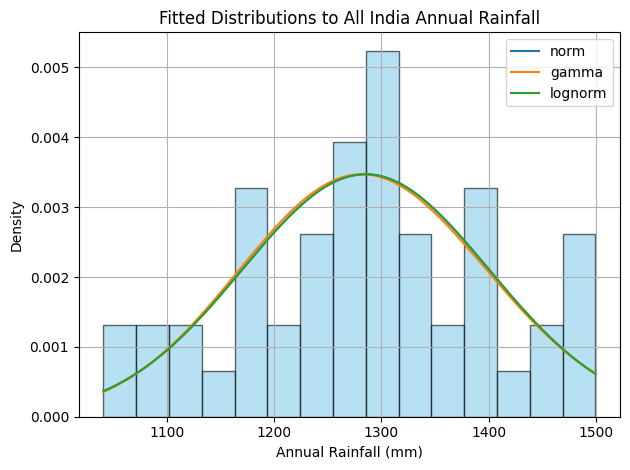


Best fitting distribution: gamma
Parameters: (np.float64(1118.888899641869), np.float64(-2561.1036334185374), np.float64(3.437430579477488))
KS-statistic: 0.0687


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load the dataset
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Step 1: Focus on ANNUAL rainfall across all states
rainfall_column = 'ANNUAL'
df_clean = df[['Year', 'State Name', rainfall_column]].dropna()

# Step 2: Aggregate to All-India level (mean rainfall across states per year)
df_all_india = df_clean.groupby('Year')[rainfall_column].mean().reset_index()
rainfall_data = df_all_india[rainfall_column].values

# Step 3: Plot histogram
plt.hist(rainfall_data, bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Step 4: Fit candidate distributions
distributions = {
    'norm': stats.norm,
    'gamma': stats.gamma,
    'weibull': stats.weibull_min,
    'lognorm': stats.lognorm
}

fit_results = {}

# Step 5: Fit and plot each distribution
x = np.linspace(min(rainfall_data), max(rainfall_data), 1000)

for name, dist in distributions.items():
    try:
        params = dist.fit(rainfall_data)
        pdf = dist.pdf(x, *params)
        fit_results[name] = {
            'params': params,
            'ks_stat': stats.kstest(rainfall_data, name, args=params).statistic
        }
        plt.plot(x, pdf, label=name)
    except Exception as e:
        print(f"Error fitting {name}: {e}")

# Step 6: Display
plt.title("Fitted Distributions to All India Annual Rainfall")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Print best fit based on KS-stat
best_fit = min(fit_results, key=lambda k: fit_results[k]['ks_stat'])
print(f"\nBest fitting distribution: {best_fit}")
print(f"Parameters: {fit_results[best_fit]['params']}")
print(f"KS-statistic: {fit_results[best_fit]['ks_stat']:.4f}")


Trend slope for mean RICE YIELD (Kg per ha)
Trend slope for std dev RICE YIELD (Kg per ha)

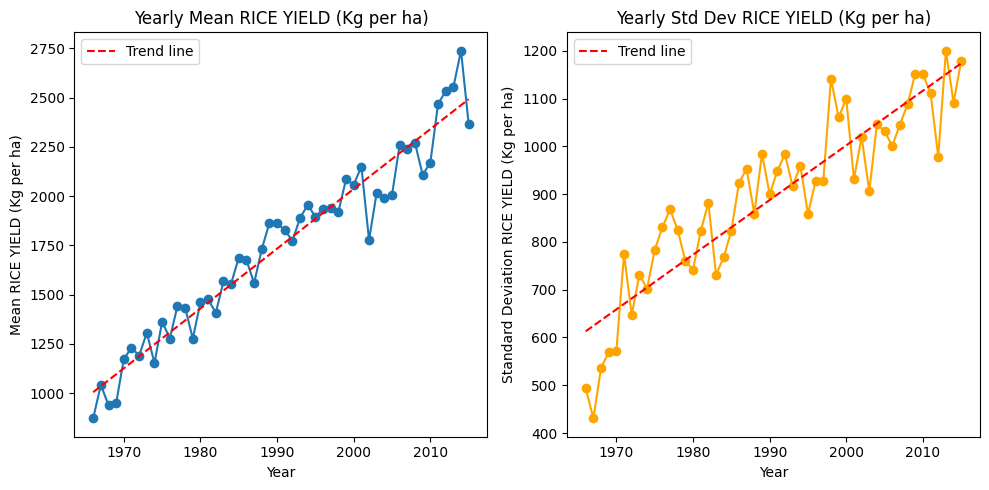

Trend slope for mean RICE YIELD (Kg per ha): 30.34316113225992
Trend slope for std dev RICE YIELD (Kg per ha): 11.442871793476241


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import pandas as pd # Import pandas as it was used in previous cells to load df

# Assuming df is already loaded from a previous cell like:
# df = pd.read_csv('/content/merged_yield_rainfall_1966_2015.csv')

# Specify the column to analyze, for example 'RICE YIELD (Kg per ha)'
# Replace 'RICE YIELD (Kg per ha)' with the actual column name you want to analyze
column_to_analyze = 'RICE YIELD (Kg per ha)'

# Check if the specified column exists before proceeding
if column_to_analyze not in df.columns:
    print(f"Error: Column '{column_to_analyze}' not found in the DataFrame.")
else:
    # Ensure the column is numeric before grouping and aggregating
    df[column_to_analyze] = pd.to_numeric(df[column_to_analyze], errors='coerce')
    # Drop rows where the column_to_analyze is NaN after coercion if necessary
    df_clean = df.dropna(subset=[column_to_analyze, 'Year']).copy()

    # Group by Year
    # Use the specified column name instead of 'Value'
    yearly_stats = df_clean.groupby('Year')[column_to_analyze].agg(['mean', 'std']).reset_index()

    # Drop rows with NaN in the aggregated results (e.g., if a year had no data after cleaning)
    yearly_stats = yearly_stats.dropna(subset=['mean', 'std'])

    # Check if there is enough data points (at least 2 years) to plot and regress
    if len(yearly_stats) < 2:
        print(f"Not enough yearly data points ({len(yearly_stats)}) after cleaning to plot and perform regression.")
    else:
        # Plot mean over years
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(yearly_stats['Year'], yearly_stats['mean'], marker='o')
        plt.xlabel('Year')
        plt.ylabel(f'Mean {column_to_analyze}') # Update y-axis label
        plt.title(f'Yearly Mean {column_to_analyze}') # Update title

        # Fit trend line for mean
        slope_mean, intercept_mean, r_value, p_value, std_err = linregress(yearly_stats['Year'], yearly_stats['mean'])
        plt.plot(yearly_stats['Year'], intercept_mean + slope_mean * yearly_stats['Year'], 'r--', label='Trend line')
        plt.legend()

        # Plot std deviation over years
        plt.subplot(1, 2, 2)
        plt.plot(yearly_stats['Year'], yearly_stats['std'], marker='o', color='orange')
        plt.xlabel('Year')
        plt.ylabel(f'Standard Deviation {column_to_analyze}') # Update y-axis label
        plt.title(f'Yearly Std Dev {column_to_analyze}') # Update title

        # Fit trend line for std deviation
        slope_std, intercept_std, r_value, p_value, std_err = linregress(yearly_stats['Year'], yearly_stats['std'])
        plt.plot(yearly_stats['Year'], intercept_std + slope_std * yearly_stats['Year'], 'r--', label='Trend line')
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Check slopes
        print(f"Trend slope for mean {column_to_analyze}: {slope_mean}")
        print(f"Trend slope for std dev {column_to_analyze}: {slope_std}")

STEP2 - USE OF DAILY RAINFALL DATA AND PREDICTION OF PREMIUM AND FITTING LOG NORMAL DISTRIBUTION AND PREDICTION OF INSURANCE

INDIA LEVEL LOG NORMAL RAINFALL

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Load your data
data = pd.read_excel('/content/daily-rainfal.xlsx')  # replace with your filename

# Convert date to datetime
data['date'] = pd.to_datetime(data['date'])

# Filter for June to September
data_filtered = data[(data['date'].dt.month >= 6) & (data['date'].dt.month <= 9)]

# Extract year for filtering
data_filtered['year'] = data_filtered['date'].dt.year

# Filter for years 2009 to 2015
data_filtered = data_filtered[(data_filtered['year'] >= 2009) & (data_filtered['year'] <= 2015)]

# Initialize list to store results
results = []

def fit_lognormal(data_series, identifier_dict):
    data_values = data_series.values
    data_values = data_values[data_values > 0]
    if data_values.size > 0:
        shape, loc, scale = lognorm.fit(data_values, floc=0)
        # Generate x range
        if np.min(data_values) != np.max(data_values):
            x = np.linspace(np.min(data_values), np.max(data_values), 100)
        else:
            x = np.array([np.min(data_values)])
        pdf = lognorm.pdf(x, shape, loc=0, scale=scale)
        # Prepare DataFrame with all info
        df_list = []
        for xi, p in zip(x, pdf):
            row = {
                'Year': identifier_dict.get('year'),
                'Level': 'India',
                'Name': '',  # no name for India level
                'Shape': shape,
                'Scale': scale,
                'x': xi,
                'pdf': p
            }
            df_list.append(row)
        return pd.DataFrame(df_list)
    else:
        print(f"Skipping year {identifier_dict.get('year')}: No positive data.")
        return pd.DataFrame()

# Process India level
india_data = data_filtered.groupby('year')['actual'].sum().reset_index()
for _, row in india_data.iterrows():
    year = row['year']
    data_year = data_filtered[data_filtered['year'] == year]['actual']
    result_df = fit_lognormal(data_year, {'year': year})
    if not result_df.empty:
        results.append(result_df)

# Concatenate all results
if results:
    full_df = pd.concat(results, ignore_index=True)
    # Save to Excel
    full_df.to_excel('India_level_lognormal_2009_2015.xlsx', index=False)
    print("Results saved to 'India_level_lognormal_2009_2015.xlsx'")
else:
    print("No data to save.")

Results saved to 'India_level_lognormal_2009_2015.xlsx'


<ipython-input-24-d3cc6c92b452>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['year'] = data_filtered['date'].dt.year


ALL INDIA DISTRICT LEVEL LOGNORMAL DATA

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Load your data
data = pd.read_excel('/content/daily-rainfal.xlsx')  # replace with your filename

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'])

# Filter for June to September
data_filtered = data[(data['date'].dt.month >= 6) & (data['date'].dt.month <= 9)]

# Extract year for filtering
data_filtered['year'] = data_filtered['date'].dt.year

# Filter for years 2009 to 2015
data_filtered = data_filtered[(data_filtered['year'] >= 2009) & (data_filtered['year'] <= 2015)]

# Initialize list to store results
results = []

def fit_lognormal(data_series, year):
    # Filter positive values
    data_values = data_series.values
    data_values = data_values[data_values > 0]
    if len(data_values) > 0:
        # Fit log-normal distribution
        shape, loc, scale = lognorm.fit(data_values, floc=0)
        # Generate x range for plotting
        x_min, x_max = np.min(data_values), np.max(data_values)
        if x_min != x_max:
            x = np.linspace(x_min, x_max, 100)
        else:
            x = np.array([x_min])
        # PDF values
        pdf = lognorm.pdf(x, shape, loc=0, scale=scale)
        # Create DataFrame for output
        df_list = []
        for xi, p in zip(x, pdf):
            df_list.append({
                'Year': year,
                'Level': 'India',      # All India level
                'Shape': shape,
                'Scale': scale,
                'x': xi,
                'pdf': p
            })
        return pd.DataFrame(df_list)
    else:
        print(f"Year {year}: No positive data to fit.")
        return pd.DataFrame()

# Loop over each year
for year in range(2009, 2016):
    # Get all district observations for the year
    year_data = data_filtered[data_filtered['year'] == year]
    all_observations = year_data['actual']
    # Fit log-normal distribution
    result_df = fit_lognormal(all_observations, year)
    if not result_df.empty:
        results.append(result_df)

# Concatenate all yearly results
if results:
    final_df = pd.concat(results, ignore_index=True)
    # Save to Excel
    final_df.to_excel('All_India_Districts_Lognormal_2009_2015.xlsx', index=False)
    print("Results saved to 'All_India_Districts_Lognormal_2009_2015.xlsx'")
else:
    print("No data to save.")

Results saved to 'All_India_Districts_Lognormal_2009_2015.xlsx'


<ipython-input-25-115586ecd325>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['year'] = data_filtered['date'].dt.year


DATA CHECKING FOR ROWS AND COLOUMNS

In [ ]:
# Method 1: Using .shape
print("Number of rows using .shape:", df.shape[0])

# Method 2: Using len()
print("Number of rows using len():", len(df))

# Method 3: Using .info()
print("\nUsing .info():")
df.info()

# Method 4: Using .count() (less direct for total rows, but shows per-row count)
# print("\nUsing .count(axis='columns'):")
# print(df.count(axis='columns')) # This will print count per row, not the total number of rows.
# To get the total number of rows using count, you could do:
print("\nNumber of rows using .count() index length:", len(df.count(axis='columns')))

Number of rows using .shape: 4784
Number of rows using len(): 4784

Using .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4784 entries, 0 to 4783
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Dist Code                    4784 non-null   int64  
 1   Year                         4784 non-null   int64  
 2   State Code                   4784 non-null   int64  
 3   State Name                   4784 non-null   object 
 4   Dist Name                    4784 non-null   object 
 5   RICE AREA (1000 ha)          4784 non-null   float64
 6   RICE PRODUCTION (1000 tons)  4784 non-null   float64
 7   RICE YIELD (Kg per ha)       4784 non-null   float64
 8   JAN                          4784 non-null   float64
 9   FEB                          4784 non-null   float64
 10  MAR                          4784 non-null   float64
 11  APR                          4784 non-null   float6

DISTRICTWISE GROUPED 2009-2015 RAINFALL DATA

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'daily-rainfal.xlsx'  # Change path if needed
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure DATE column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter for June to September
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[df['Year'].between(2009, 2015)]

# Sort by Year, District, Date
df = df.sort_values(by=['Year', 'district_name', 'date'])

# Write to Excel with each year as a separate sheet
with pd.ExcelWriter('Districtwise_Rainfall_Grouped_2009_2015.xlsx') as writer:
    for year in range(2009, 2016):
        yearly_df = df[df['Year'] == year]
        yearly_df.to_excel(writer, sheet_name=str(year), index=False)


<ipython-input-27-82dbf0ce6db8>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


STUDY ON HISTOGRAMS DISTRICT VS TOTAL RAINFALL BASICALLY ANALYSIS OF YEARLY RAINFALL

<ipython-input-28-5f8258e19eb9>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


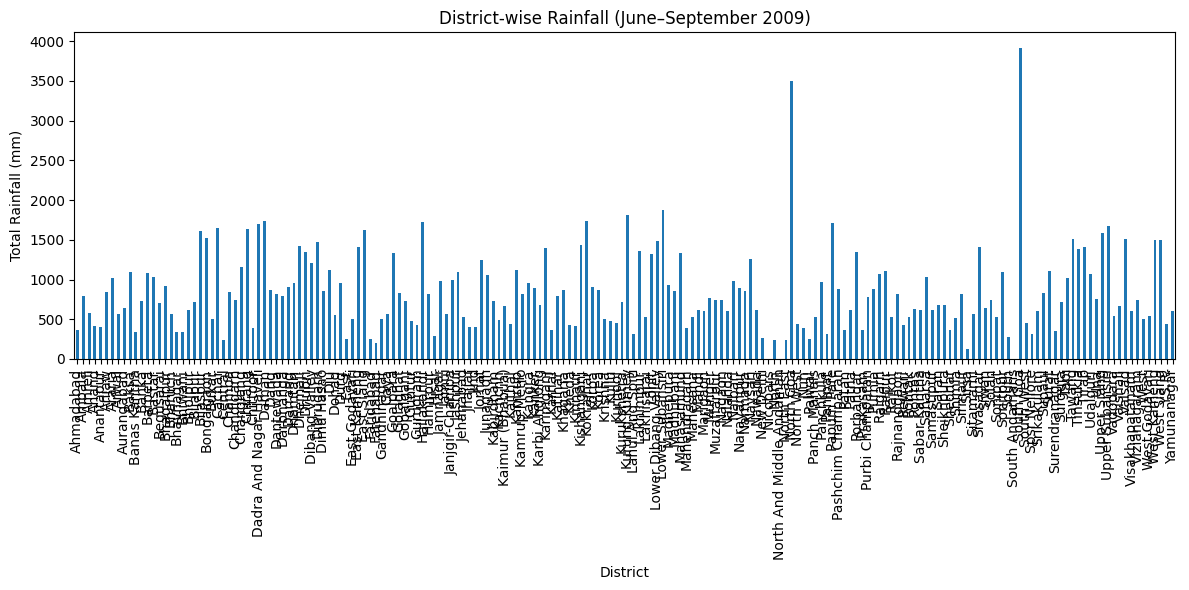

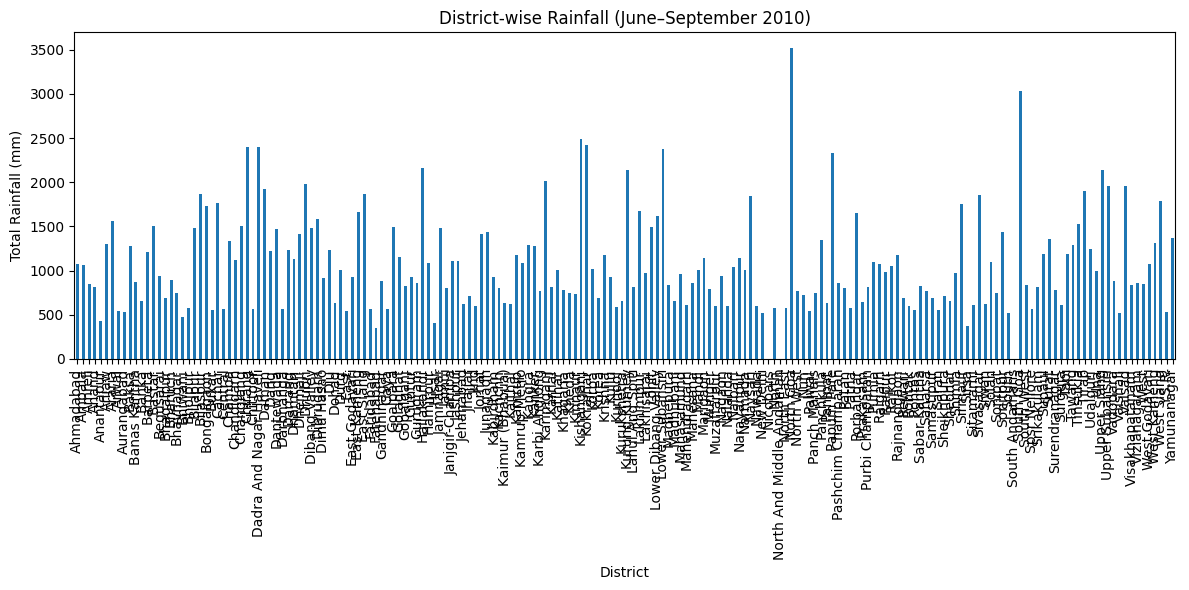

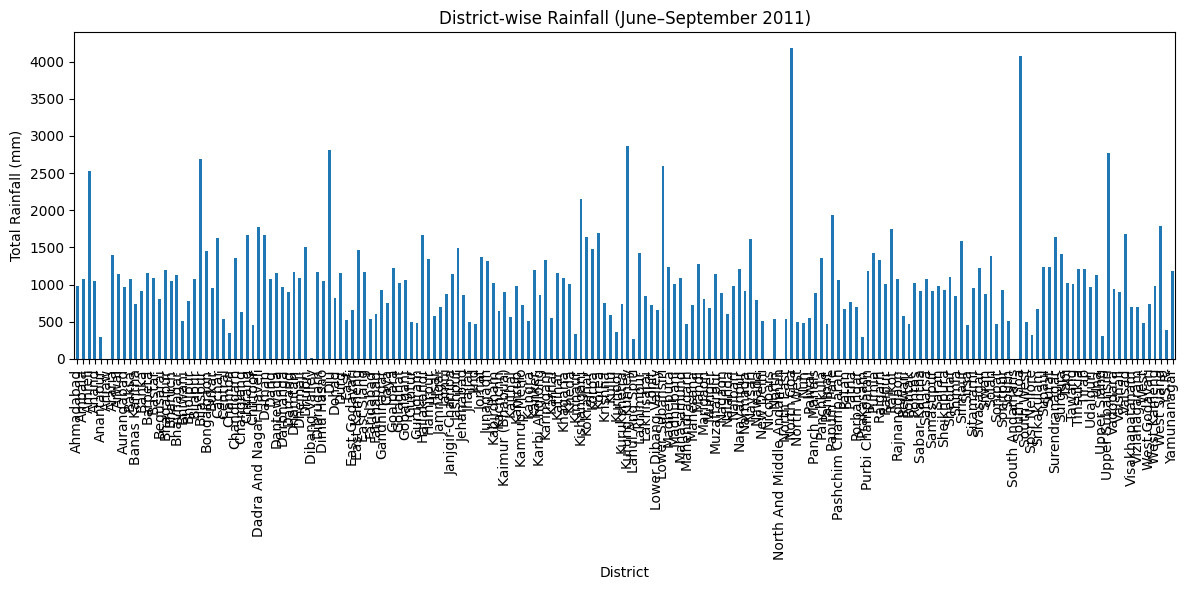

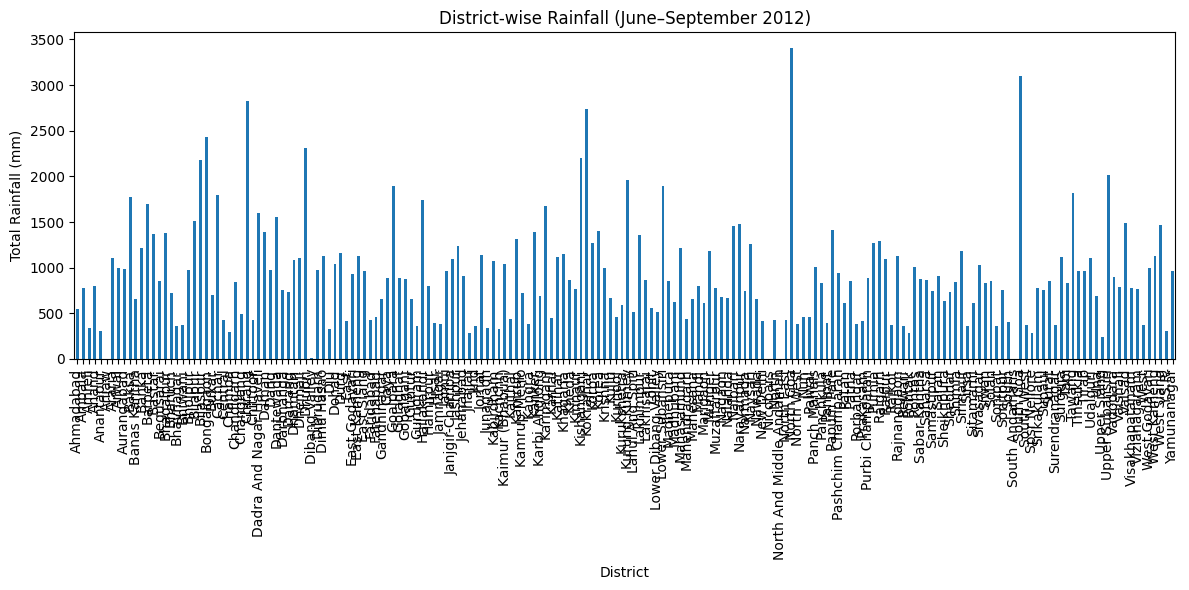

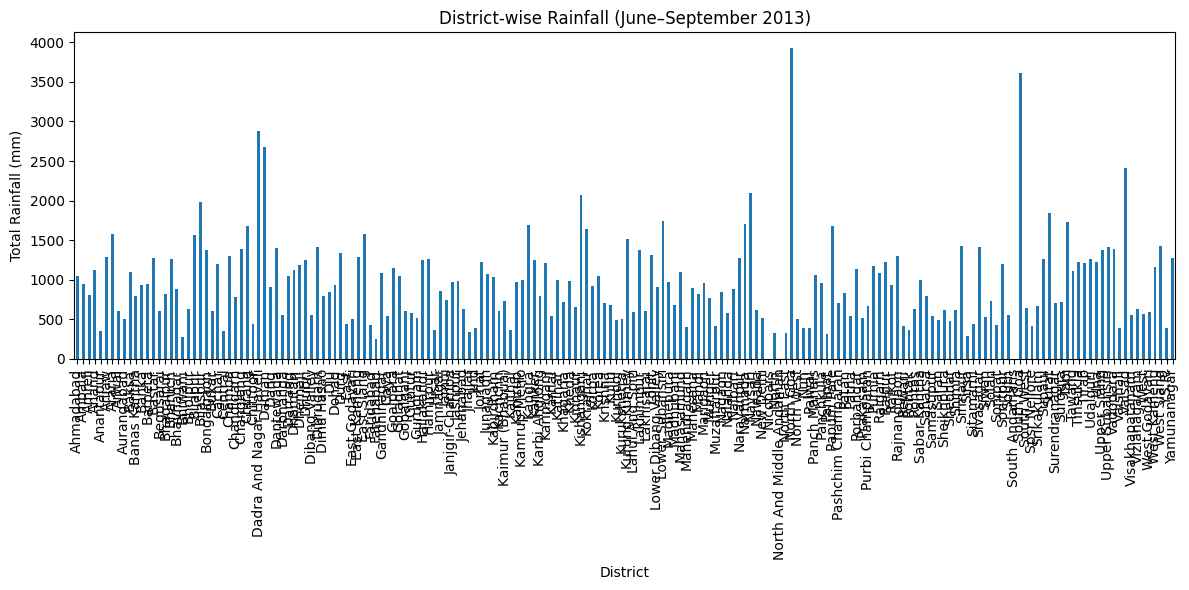

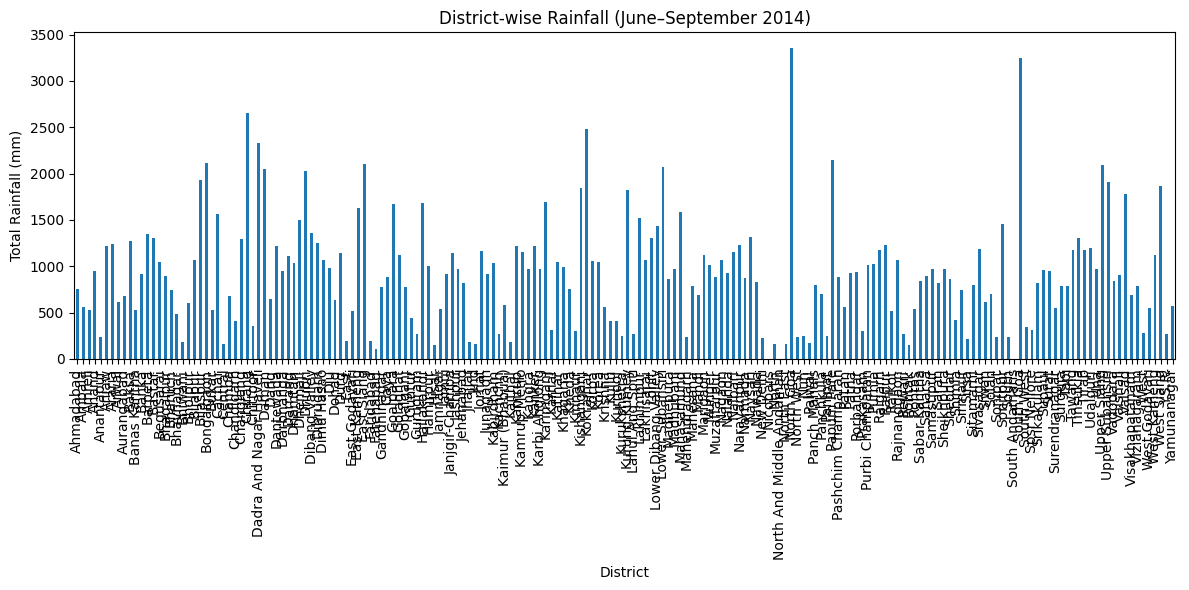

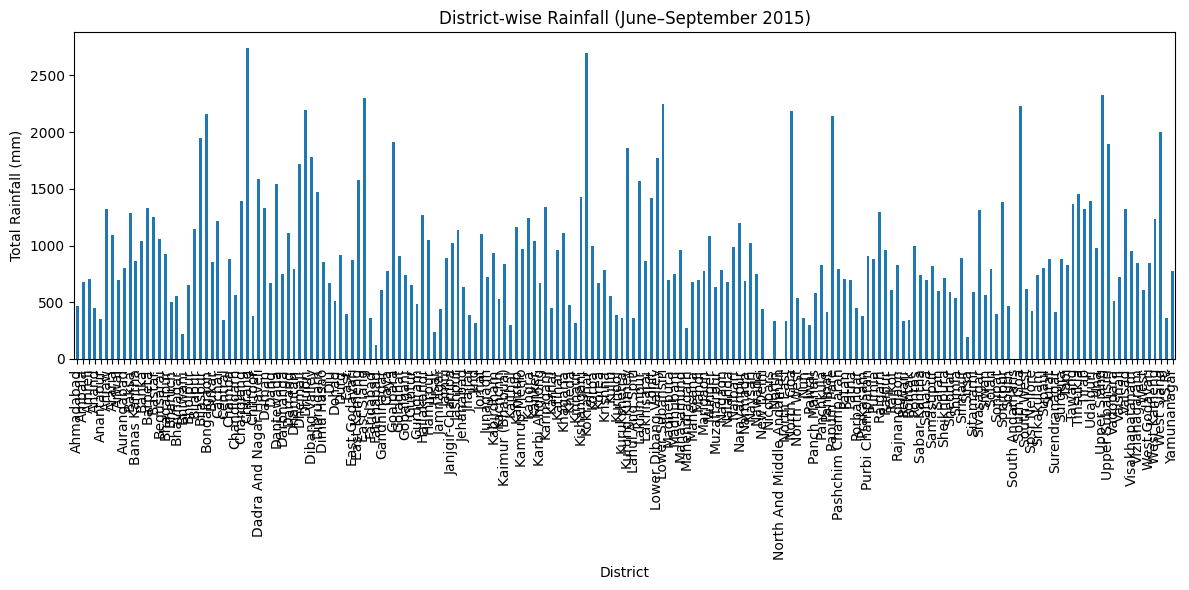

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'daily-rainfal.xlsx'
# Assuming the sheet name 'daily-rainfall-data-district-le' is correct based on your code
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure date is in datetime format
# Changed 'DATE' to 'date' to match the actual column name
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter months: June to September
# Changed 'DATE' to 'date'
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
# Changed 'DATE' to 'date'
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[(df['Year'] >= 2009) & (df['Year'] <= 2015)]

# Loop through each year and plot histograms
for year in range(2009, 2016):
    yearly_df = df[df['Year'] == year]

    # Group by district and sum rainfall
    # Ensure 'DISTRICT' and 'RAINFALL' are the correct column names if necessary
    # Replace 'District' and 'Actual_Rainfall' with the actual column names from your data
    district_rainfall = yearly_df.groupby('district_name')['actual'].sum() # <-- Corrected column names

    # Plot histogram
    plt.figure(figsize=(12, 6))
    district_rainfall.plot(kind='bar')
    plt.title(f'District-wise Rainfall (June–September {year})')
    plt.xlabel('District')
    plt.ylabel('Total Rainfall (mm)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

CREATION OF DISTRICTWISE RAINFALL AGAIN

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'daily-rainfal.xlsx'
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure DATE column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter for June to September
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
df['Year'] = df['date'].dt.year

# Filter for years 2009 to 2015
df = df[df['Year'].between(2009, 2015)]

# Sort first by DISTRICT, then by DATE
df = df.sort_values(by=['Year', 'district_name', 'date'])

# Write to Excel: one sheet per year, with districts grouped
with pd.ExcelWriter('Districtwise_Rainfall_samya.xlsx') as writer:
    for year in range(2009, 2016):
        yearly_df = df[df['Year'] == year]
        yearly_df.to_excel(writer, sheet_name=str(year), index=False)


<ipython-input-29-cfca07d37bf8>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


HISTOGRAM OF DIFFERENT DISTRICTWISE RAINFALL YEARLY 2009 TO 2015

Processing sheet: 2009


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


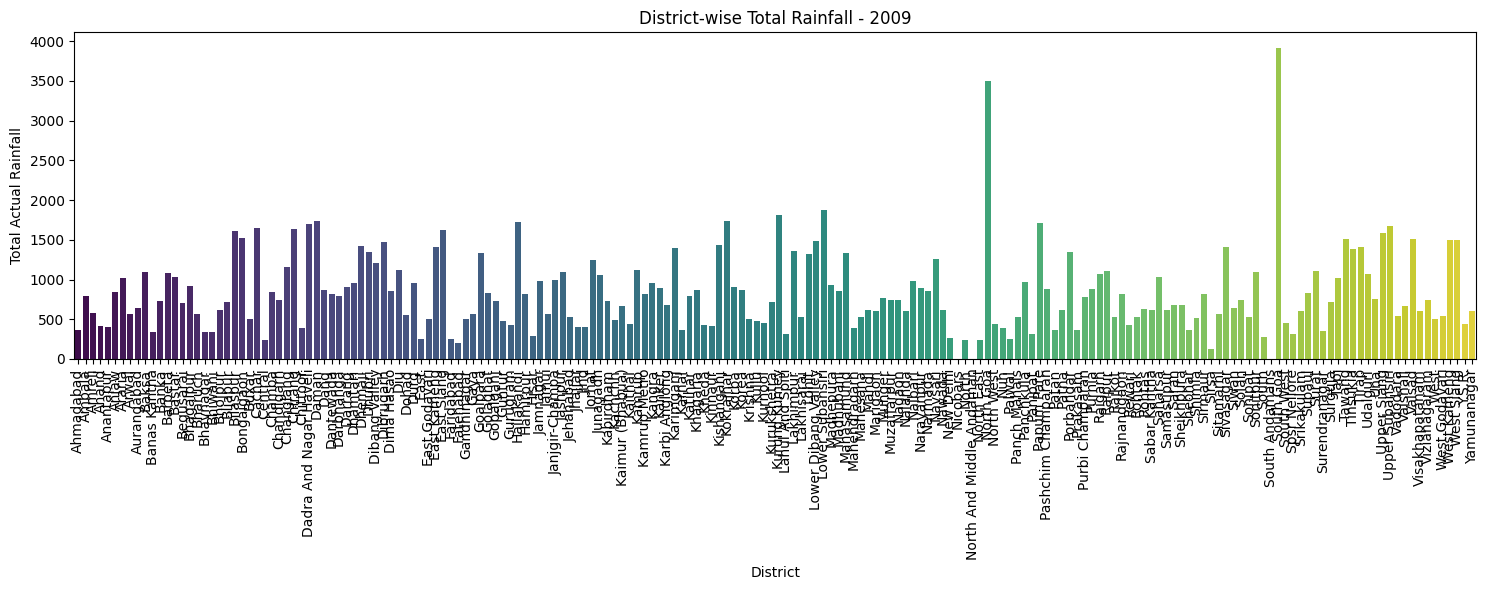

Processing sheet: 2010


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


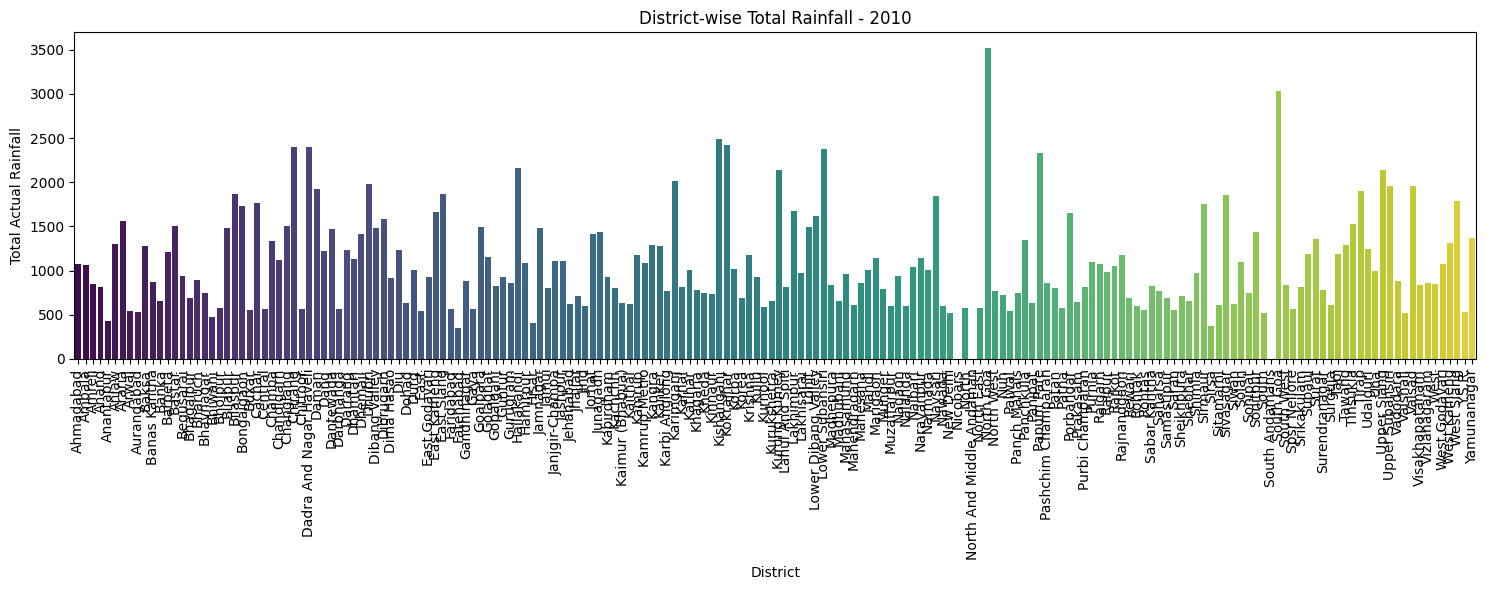

Processing sheet: 2011


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


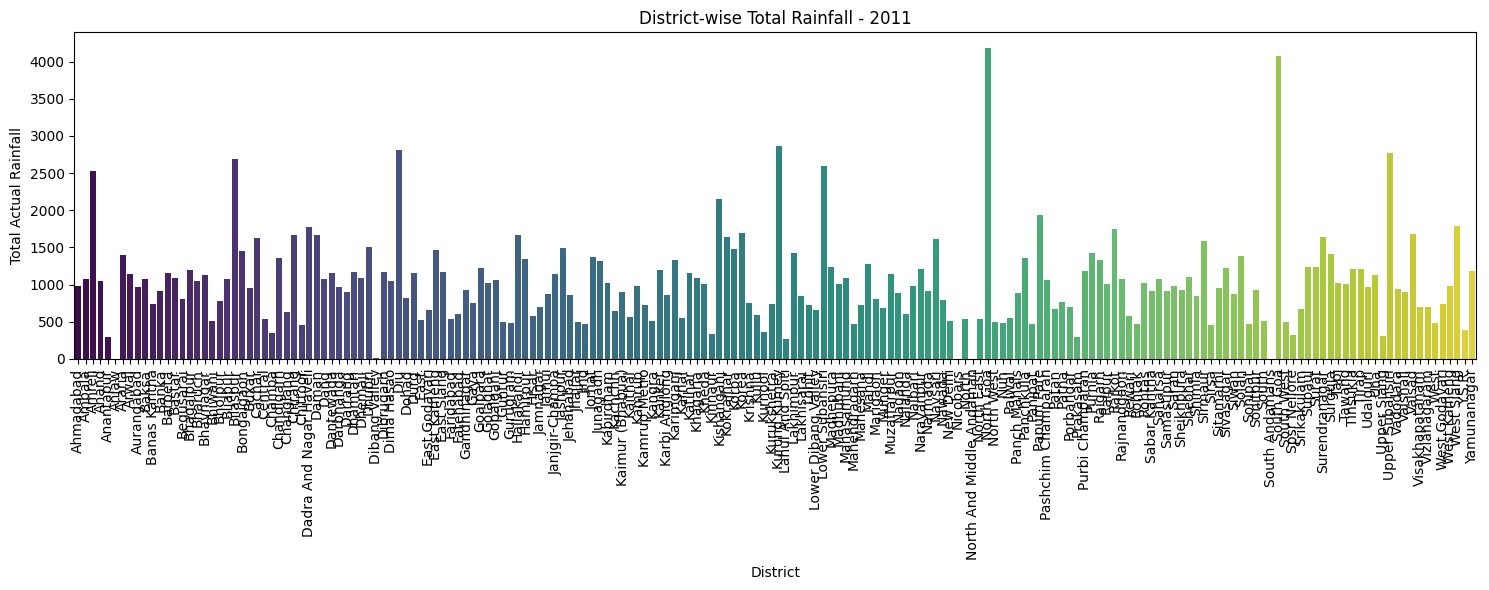

Processing sheet: 2012


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


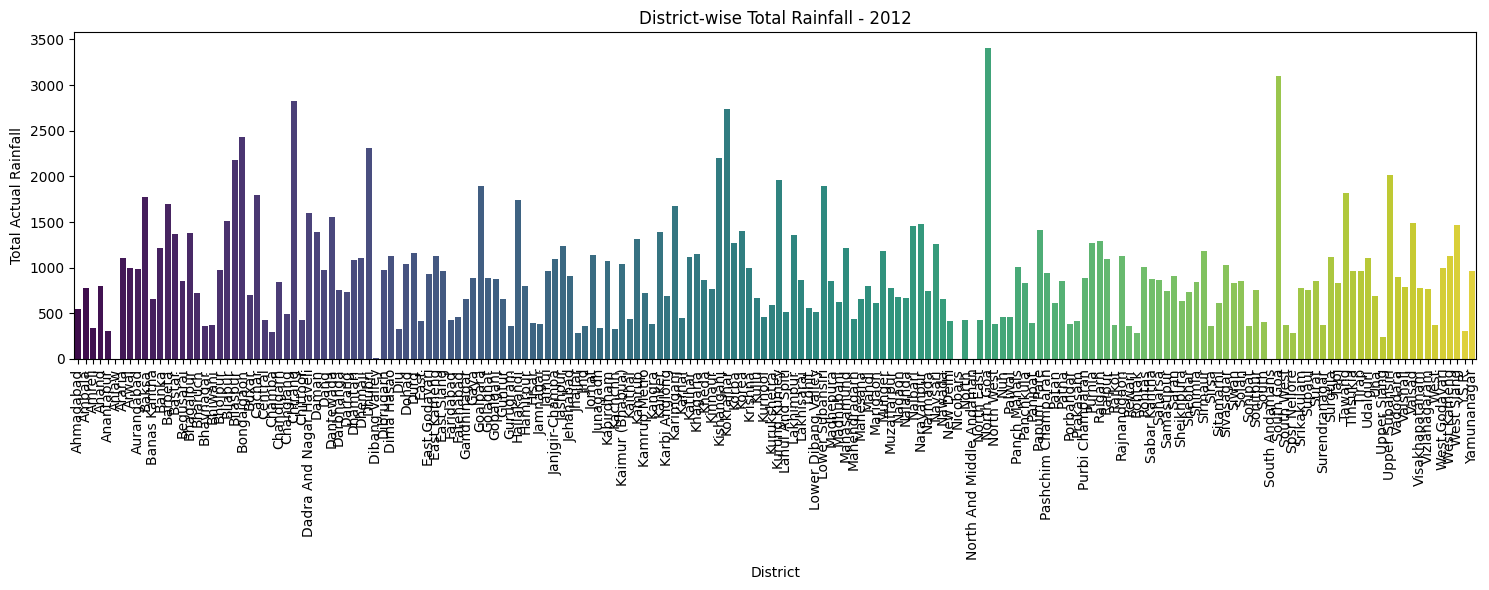

Processing sheet: 2013


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


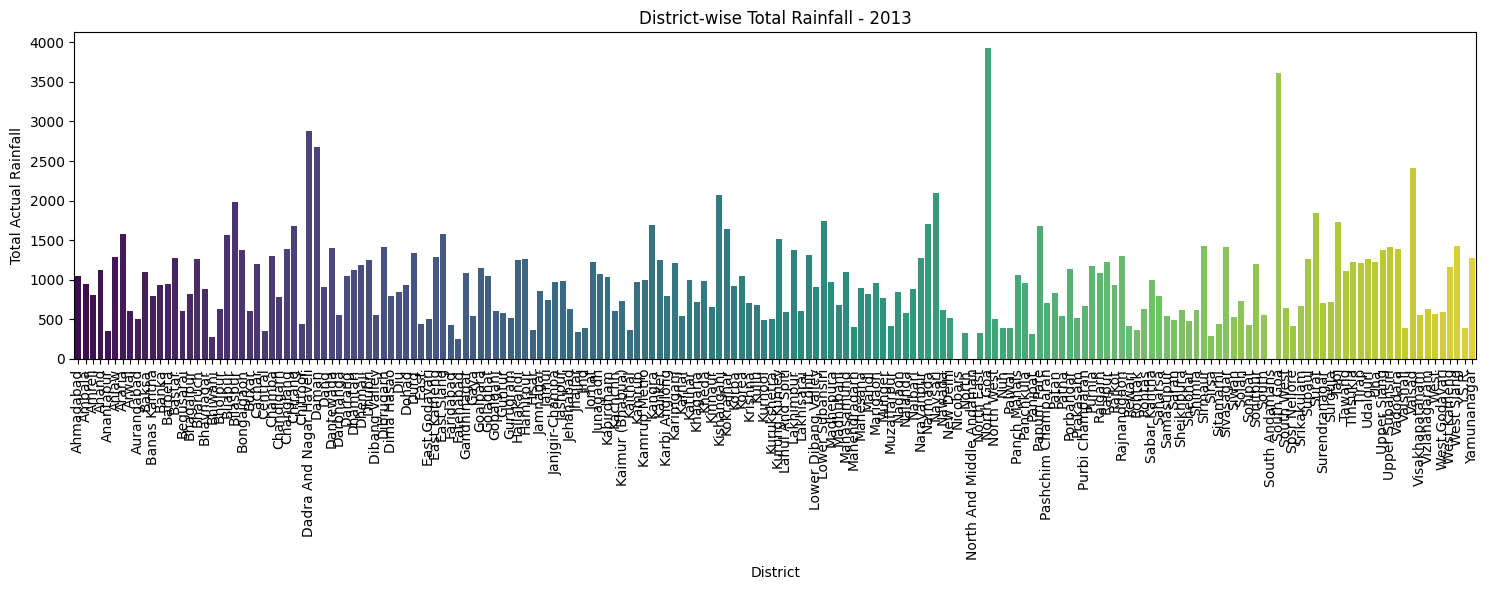

Processing sheet: 2014


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


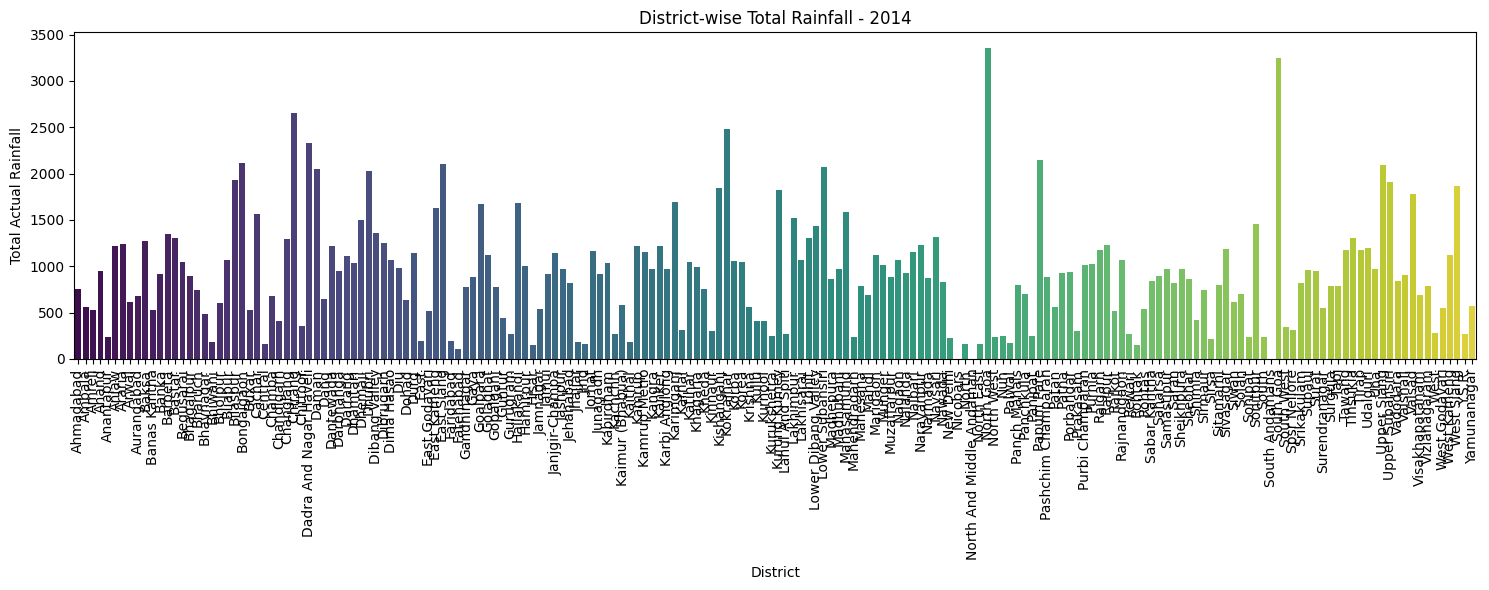

Processing sheet: 2015


<ipython-input-30-0645e0b0720e>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


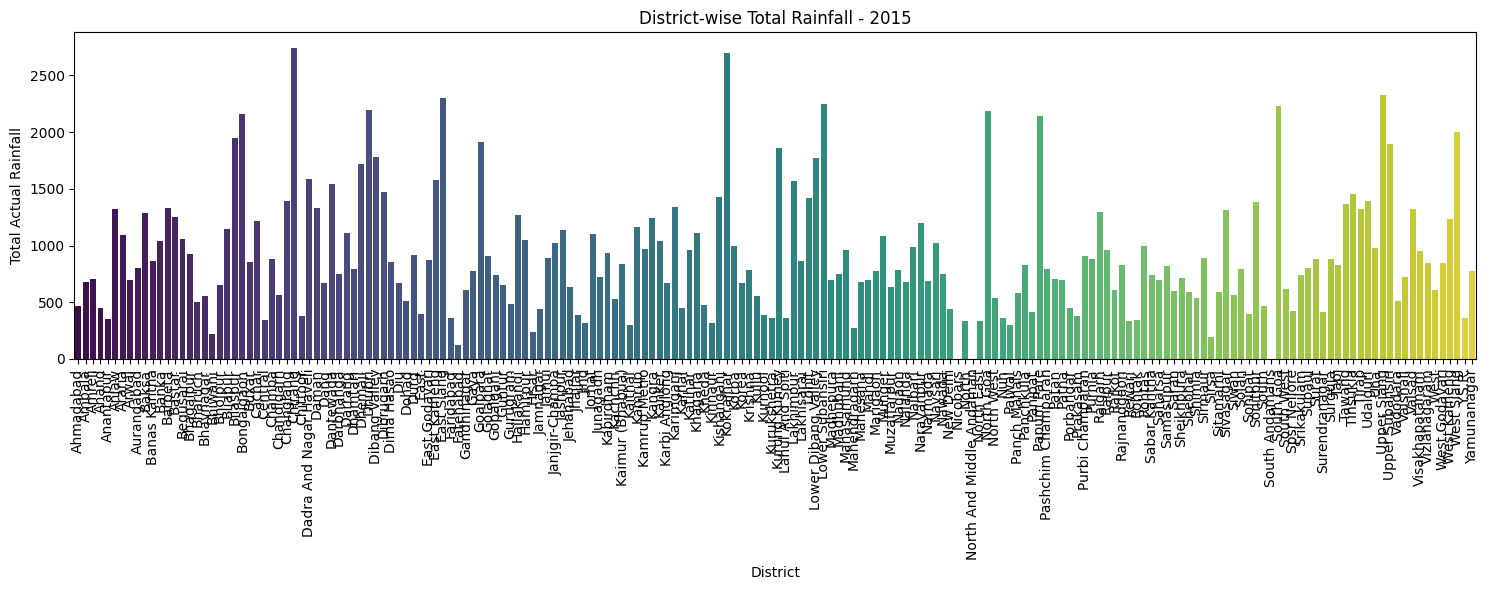

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all sheets into a dictionary
file_path = '/content/Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Iterate over each sheet
for sheet_name, df in all_sheets.items():
    print(f"Processing sheet: {sheet_name}")

    # Check if required columns exist
    if 'district_name' in df.columns and 'actual' in df.columns:
        # Group by district and sum rainfall
        district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()

        # Plotting
        plt.figure(figsize=(15,6))  # Increased width
        sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')

        plt.xlabel('District')
        plt.ylabel('Total Actual Rainfall')
        plt.title(f'District-wise Total Rainfall - {sheet_name}')
        plt.xticks(rotation=90)  # Vertical labels
        plt.tight_layout()
        plt.show()
    else:
        print(f"Columns 'district_name' or 'actual' not found in sheet {sheet_name}")

COMMENTS ON DISTRIBUTION FROM SKEWNESS


Processing sheet: 2009


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


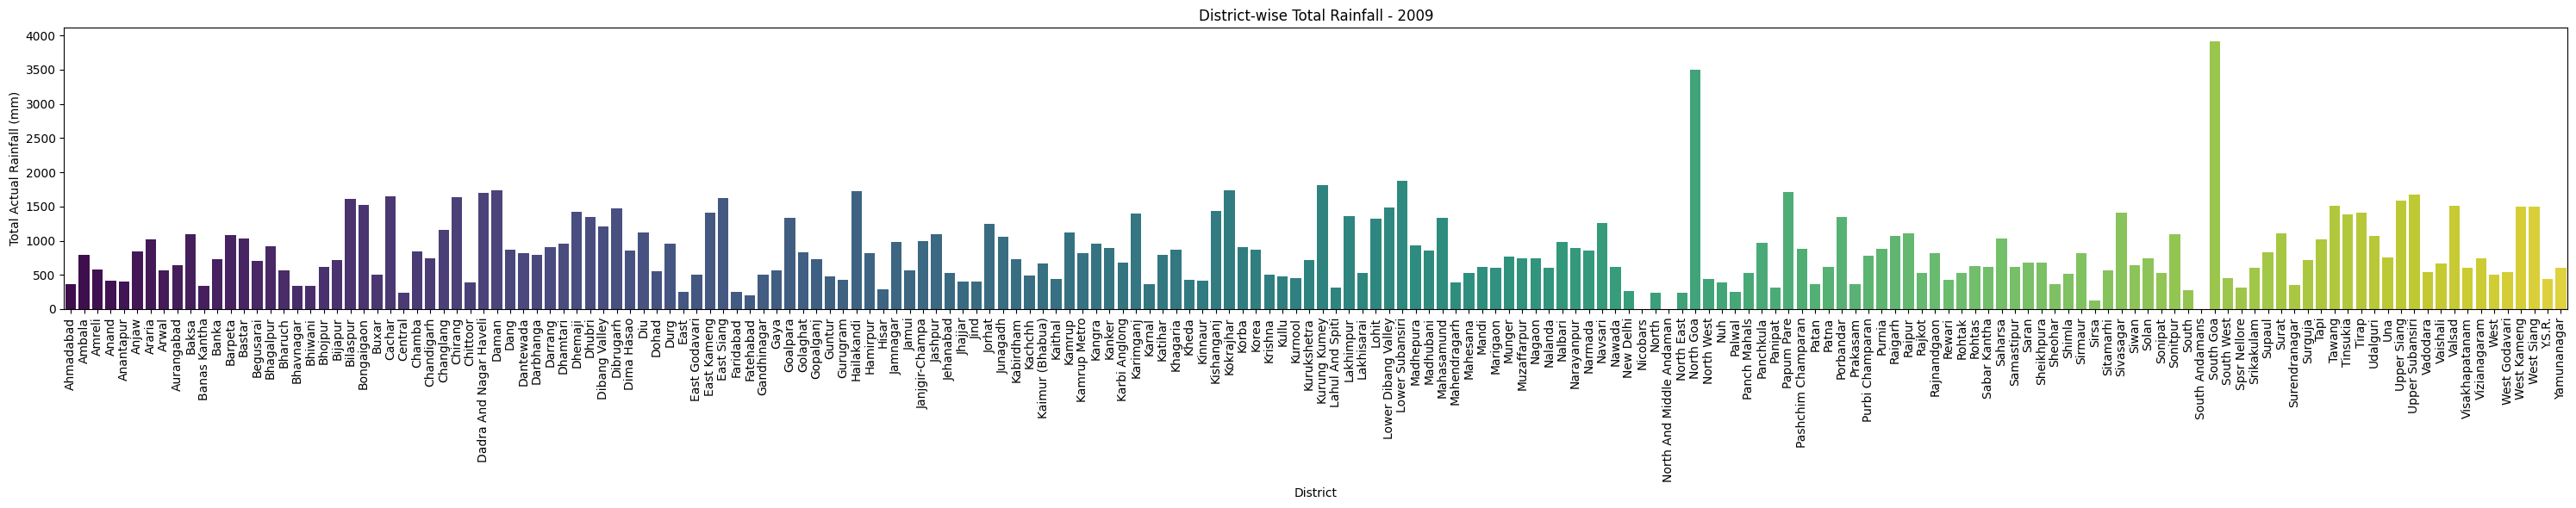


--- Distribution Analysis ---
Mean rainfall: 838.63 mm
Standard deviation: 515.34 mm
Skewness: 2.06
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


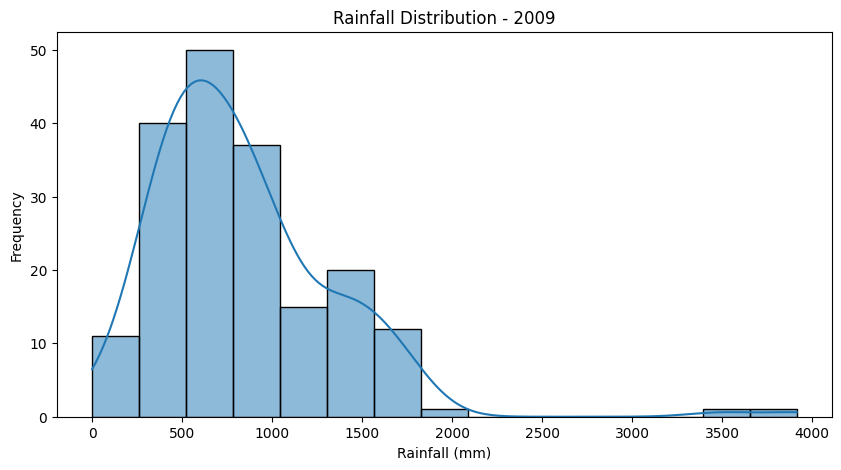


Processing sheet: 2010


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


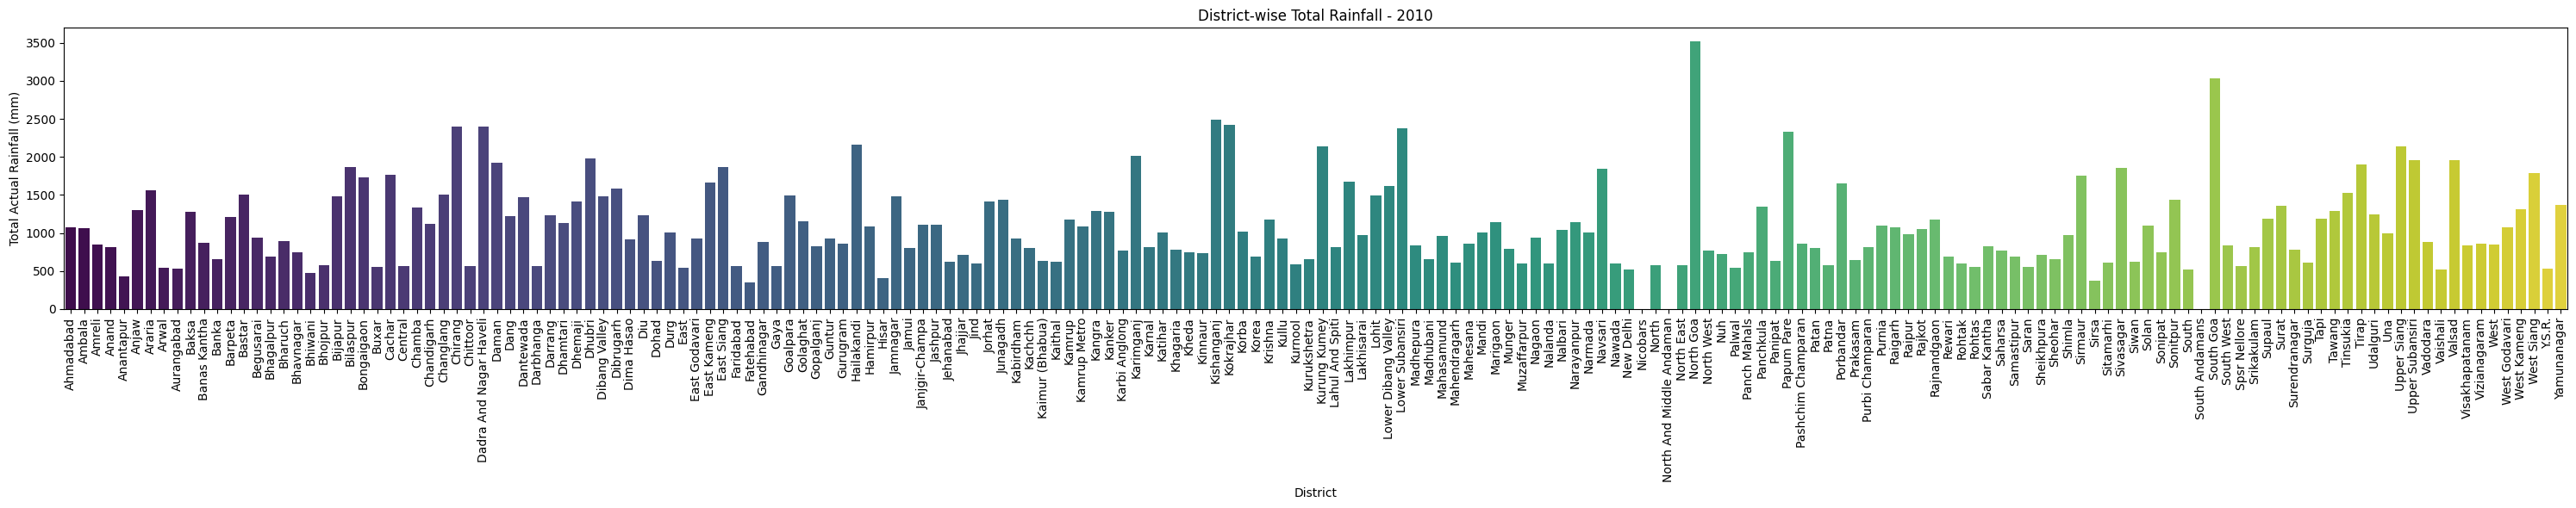


--- Distribution Analysis ---
Mean rainfall: 1071.61 mm
Standard deviation: 548.88 mm
Skewness: 1.25
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


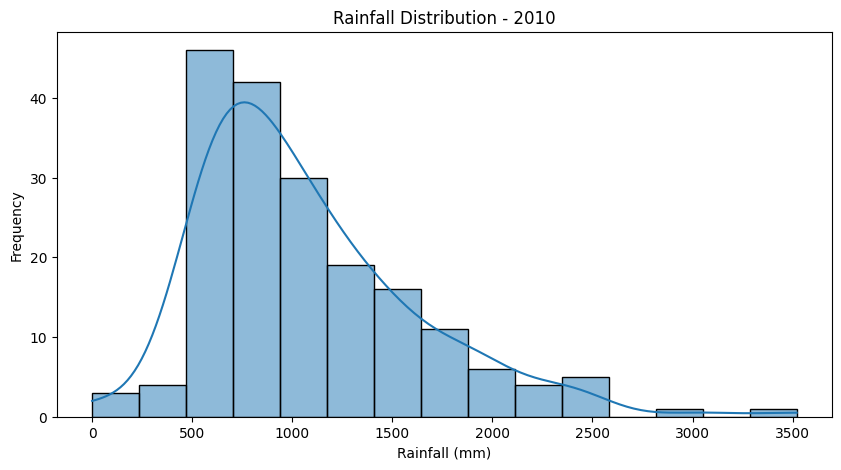


Processing sheet: 2011


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


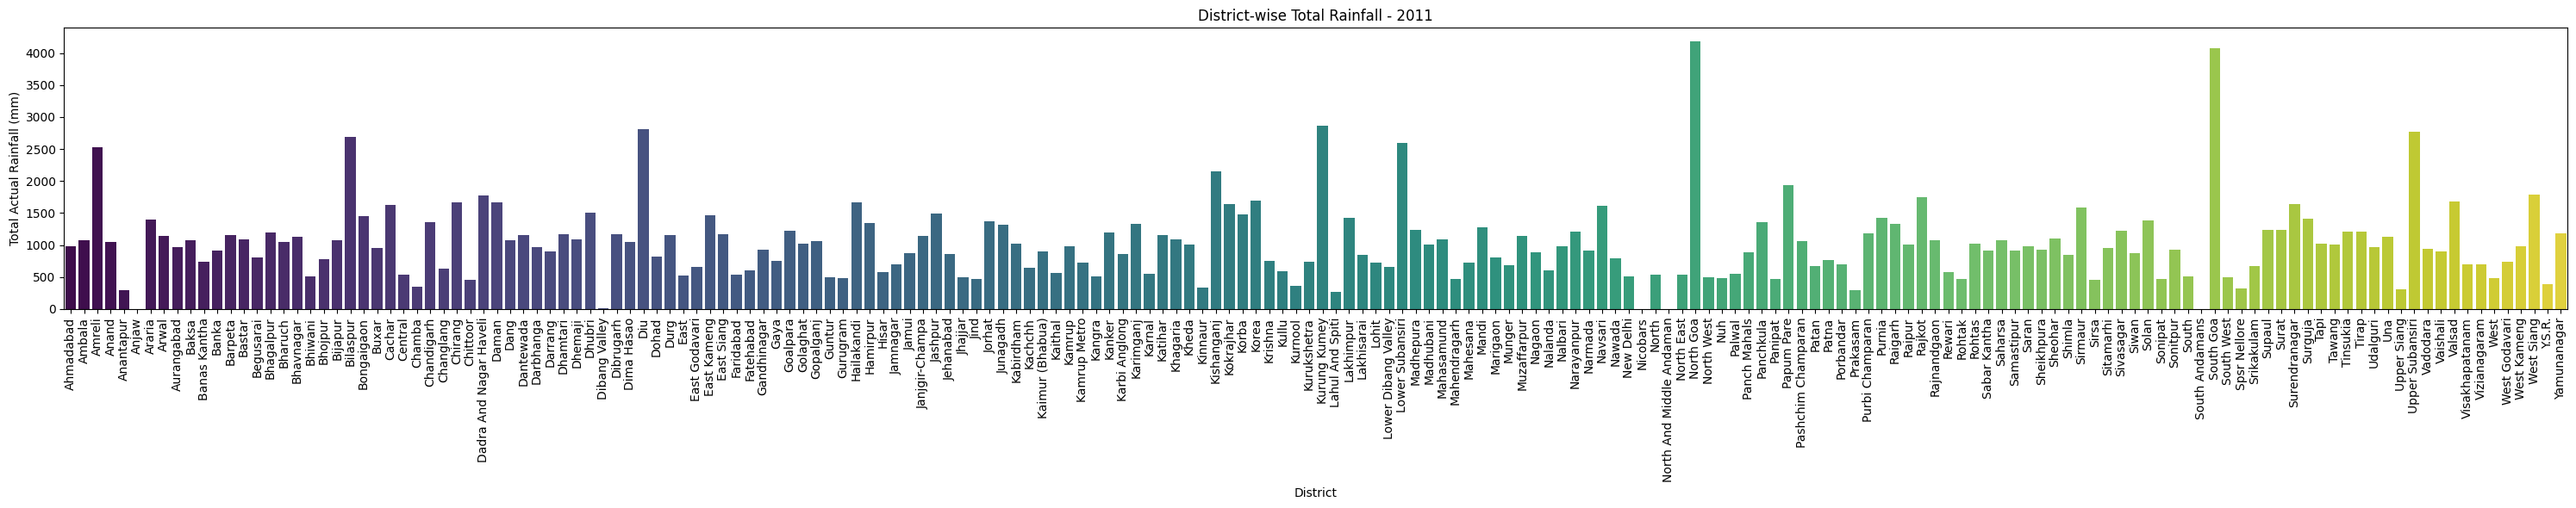


--- Distribution Analysis ---
Mean rainfall: 1027.07 mm
Standard deviation: 599.97 mm
Skewness: 2.03
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


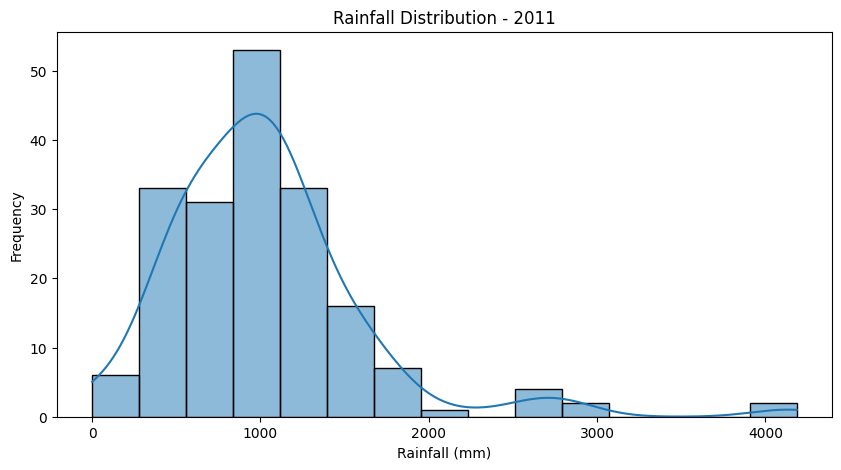


Processing sheet: 2012


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


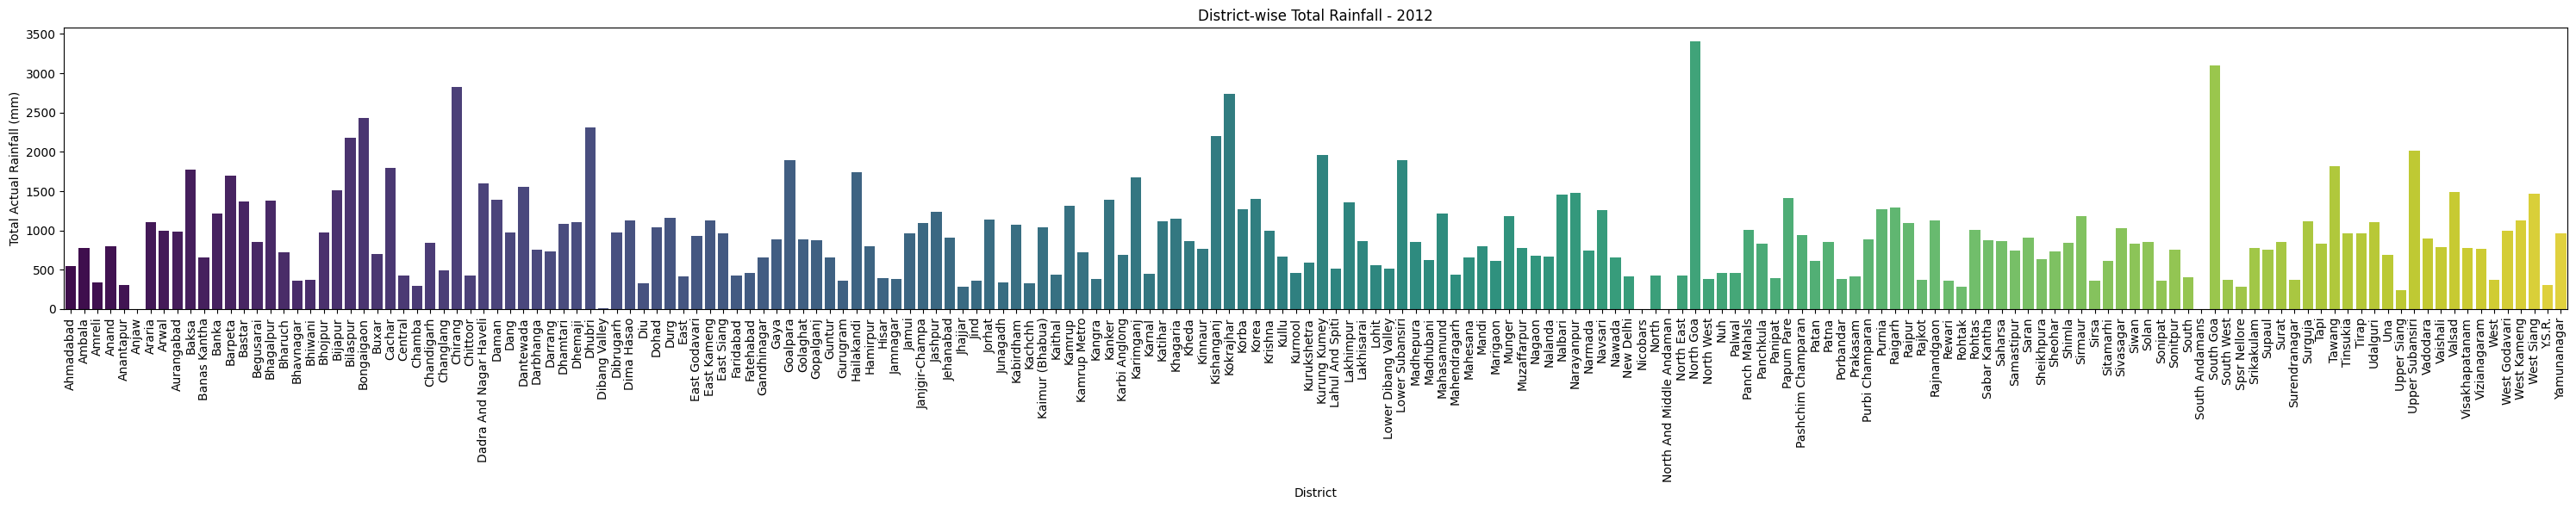


--- Distribution Analysis ---
Mean rainfall: 913.86 mm
Standard deviation: 561.38 mm
Skewness: 1.46
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


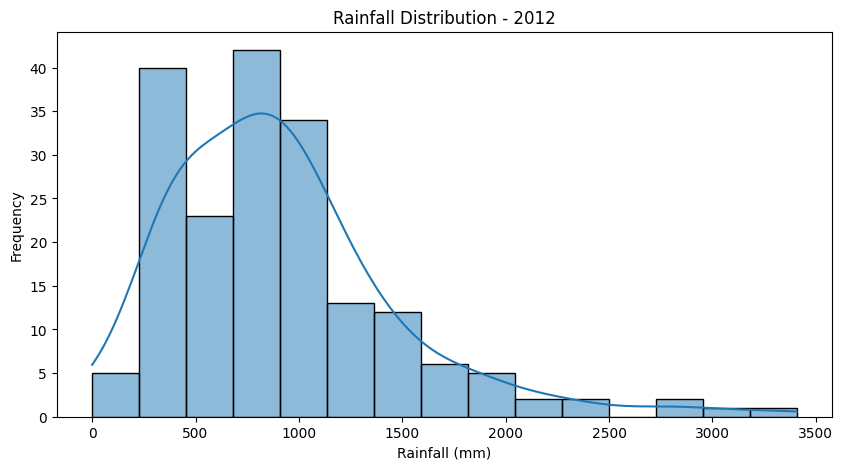


Processing sheet: 2013


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


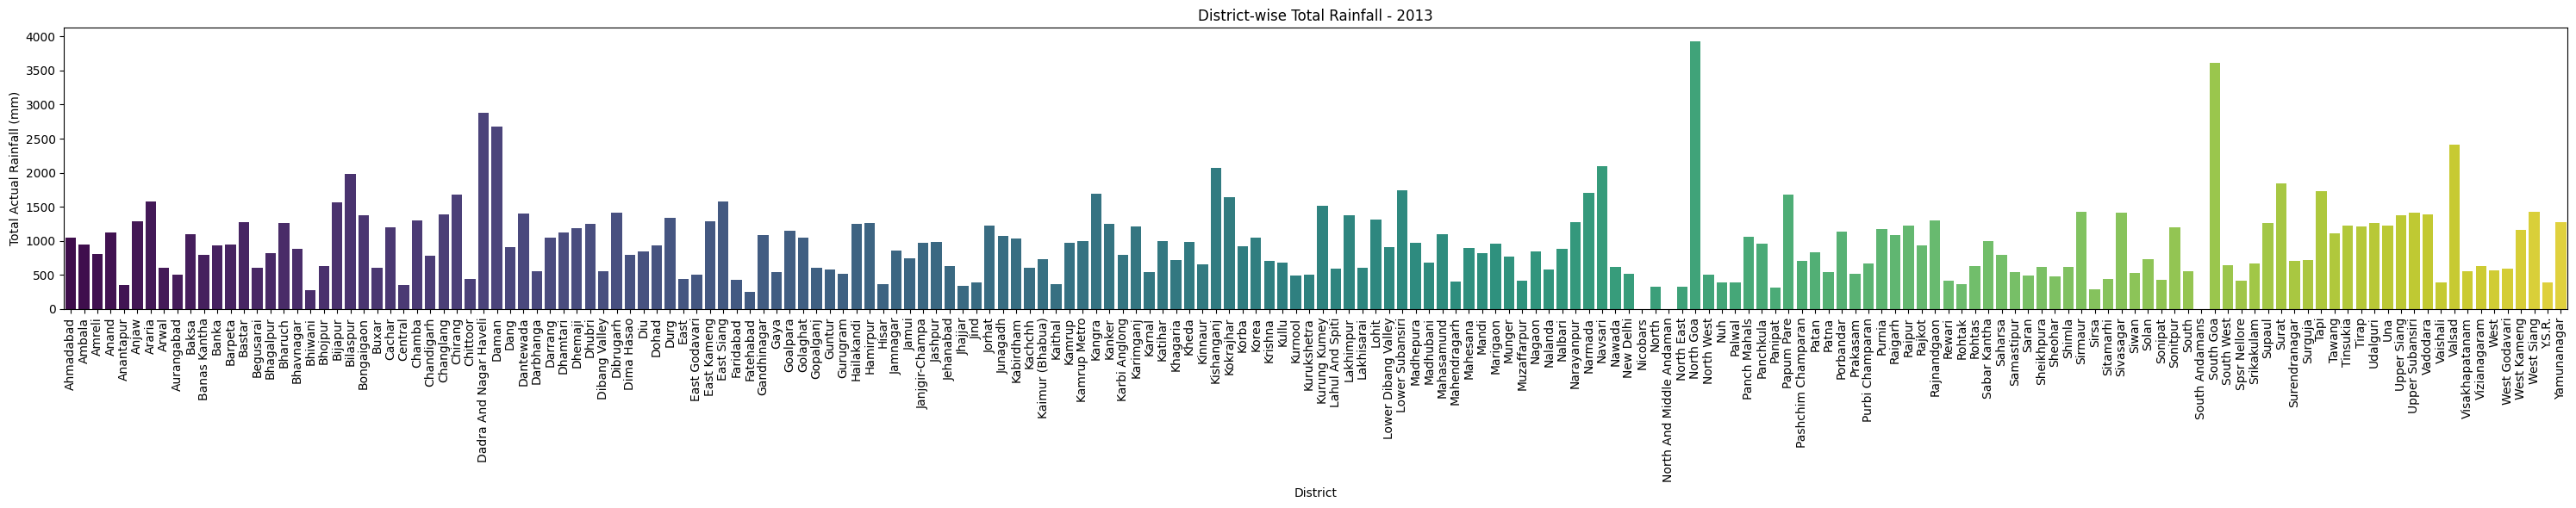


--- Distribution Analysis ---
Mean rainfall: 951.84 mm
Standard deviation: 554.10 mm
Skewness: 1.90
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


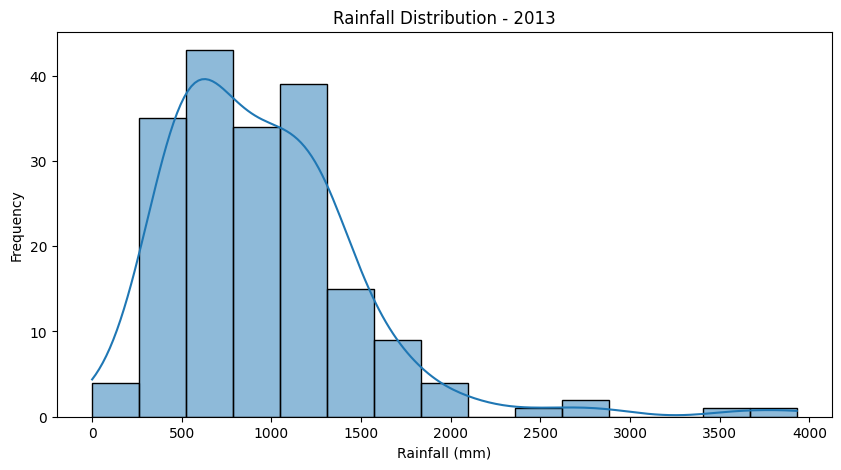


Processing sheet: 2014


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


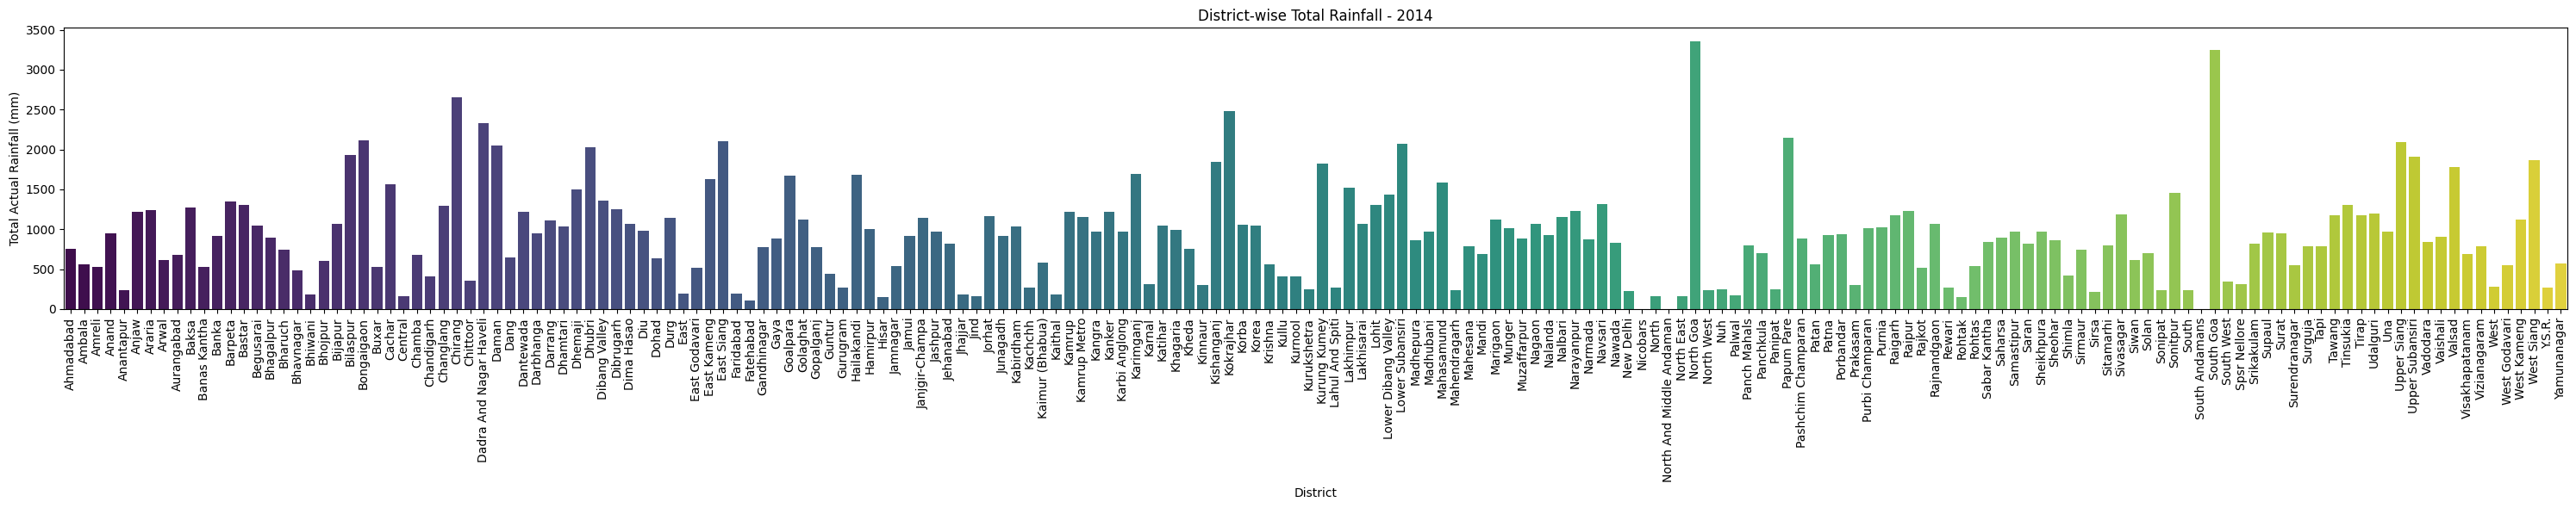


--- Distribution Analysis ---
Mean rainfall: 923.91 mm
Standard deviation: 587.06 mm
Skewness: 1.12
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data does not follow a normal distribution.


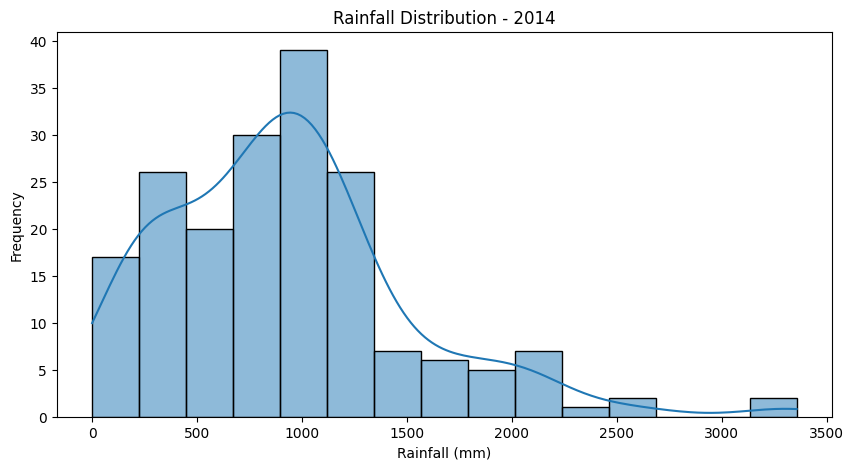


Processing sheet: 2015


<ipython-input-31-5269c2c04495>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')


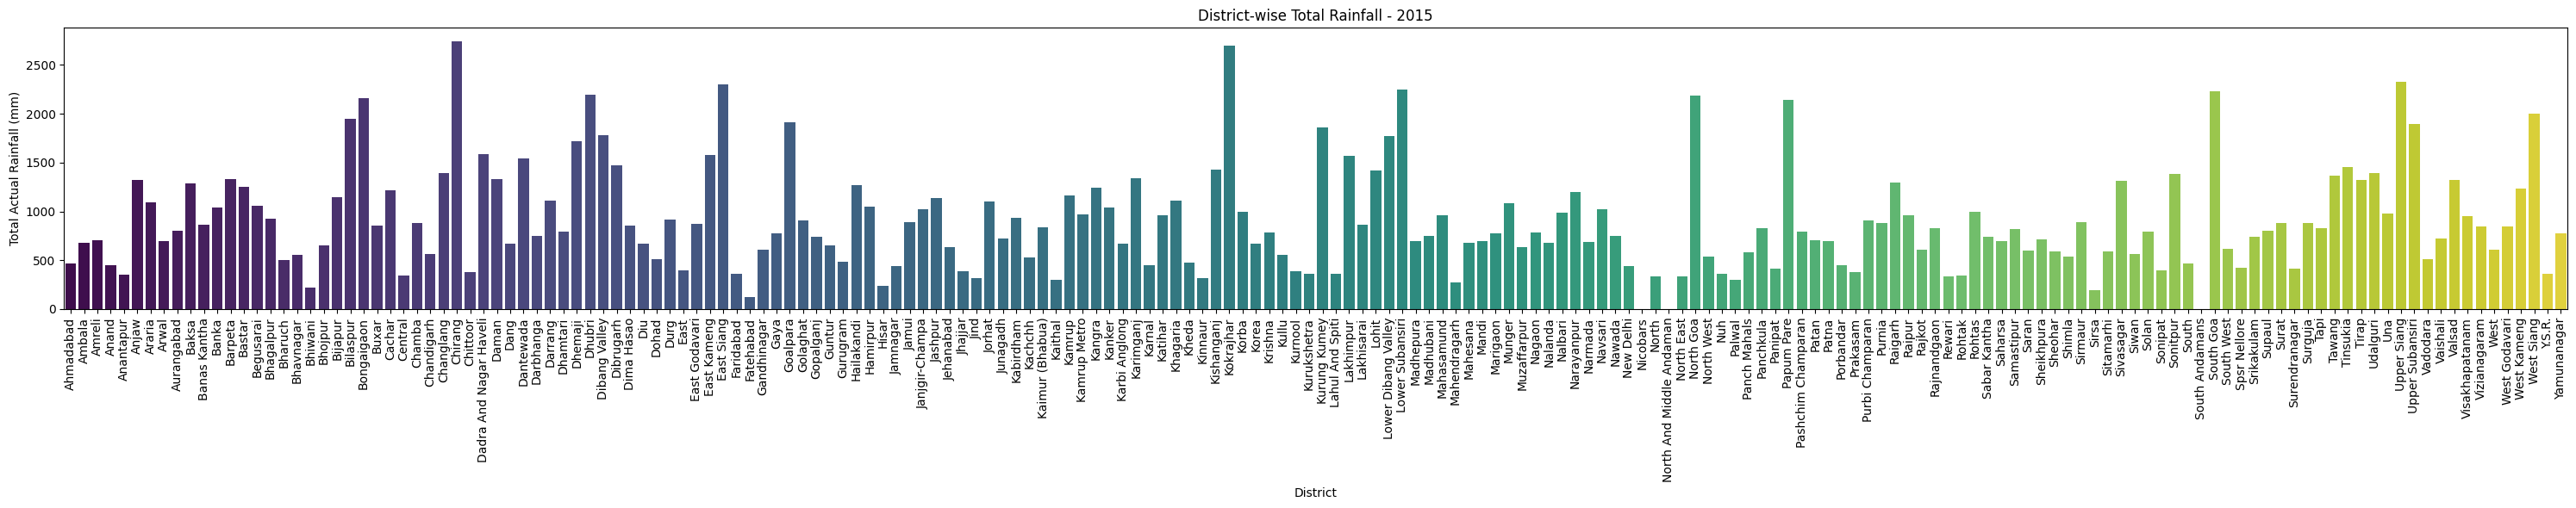


--- Distribution Analysis ---
Mean rainfall: 906.01 mm
Standard deviation: 525.19 mm
Skewness: 1.14
→ Data is right-skewed (possibly lognormal).
→ Log-transformed data follows a normal distribution (confirms lognormality).


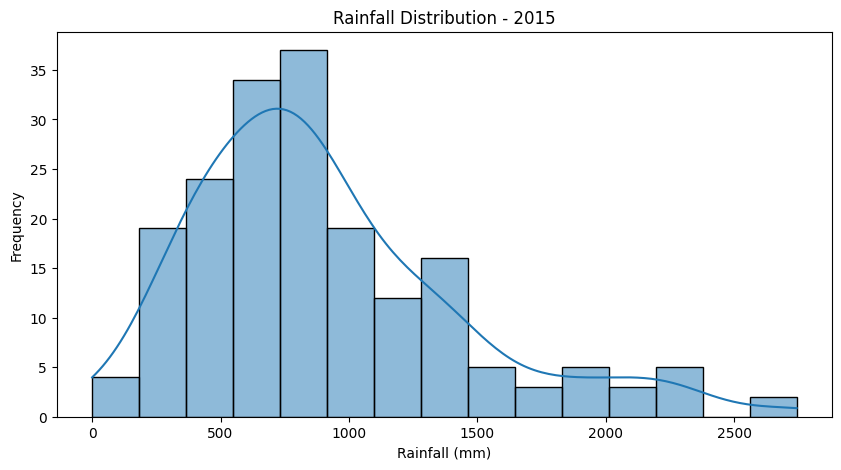

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load data
file_path = '/content/Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)

for sheet_name, df in all_sheets.items():
    print(f"\nProcessing sheet: {sheet_name}")

    if 'district_name' in df.columns and 'actual' in df.columns:
        district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()

        # Plotting
        plt.figure(figsize=(30, 6))
        sns.barplot(x='district_name', y='actual', data=district_rainfall, palette='viridis')
        plt.xlabel('District')
        plt.ylabel('Total Actual Rainfall (mm)')
        plt.title(f'District-wise Total Rainfall - {sheet_name}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

        # Distribution Analysis
        rainfall_data = district_rainfall['actual']
        mean = np.mean(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)

        print("\n--- Distribution Analysis ---")
        print(f"Mean rainfall: {mean:.2f} mm")
        print(f"Standard deviation: {std:.2f} mm")
        print(f"Skewness: {skewness:.2f}")

        # Check for lognormality
        if skewness > 1:
            print("→ Data is right-skewed (possibly lognormal).")
            # Log-transform and check normality
            log_data = np.log(rainfall_data[rainfall_data > 0])  # Avoid log(0)
            _, p_value = stats.normaltest(log_data)
            if p_value > 0.05:
                print("→ Log-transformed data follows a normal distribution (confirms lognormality).")
            else:
                print("→ Log-transformed data does not follow a normal distribution.")
        else:
            print("→ Data is not strongly skewed (possibly normal or another distribution).")

        # Plot histogram
        plt.figure(figsize=(10, 5))
        sns.histplot(rainfall_data, kde=True, bins=15)
        plt.title(f'Rainfall Distribution - {sheet_name}')
        plt.xlabel('Rainfall (mm)')
        plt.ylabel('Frequency')
        plt.show()

    else:
        print(f"Columns 'district_name' or 'actual' not found in sheet {sheet_name}")

5 PAGES ALL INDIA ANALYSIS OF RAINFALL WITH SUMMARY STAT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Load all sheets and combine data
file_path = 'Districtwise_Rainfall_samya.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)
all_data = pd.concat(all_sheets.values(), ignore_index=True)

# Group by district for India-wide analysis
india_rainfall = all_data.groupby('district_name')['actual'].sum().reset_index()
rainfall_data = india_rainfall['actual']

# --- Create PDF Report ---
pdf_path = "India_Rainfall_Analysis_Report.pdf"
with PdfPages(pdf_path) as pdf:
    # --- Plot 1: Bar Plot (All Districts) ---
    plt.figure(figsize=(20, 8))
    sns.barplot(x='district_name', y='actual', data=india_rainfall, palette='viridis')
    plt.title('All-India District-wise Total Rainfall', fontsize=16)
    plt.xlabel('District', fontsize=12)
    plt.ylabel('Total Rainfall (mm)', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Plot 2: Histogram + KDE ---
    plt.figure(figsize=(10, 6))
    sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
    plt.title('Rainfall Distribution Across India', fontsize=16)
    plt.xlabel('Rainfall (mm)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    pdf.savefig()
    plt.close()

    # --- Plot 3: Q-Q Plot (Normality Check) ---
    plt.figure(figsize=(10, 6))
    stats.probplot(rainfall_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot: Rainfall vs Normal Distribution', fontsize=16)
    pdf.savefig()
    plt.close()

    # --- Plot 4: Top 10 & Bottom 10 Districts ---
    top_10 = india_rainfall.nlargest(10, 'actual')
    bottom_10 = india_rainfall.nsmallest(10, 'actual')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(x='actual', y='district_name', data=top_10, ax=ax1, palette='Blues_d')
    ax1.set_title('Top 10 Districts by Rainfall', fontsize=14)
    ax1.set_xlabel('Rainfall (mm)', fontsize=12)
    ax1.set_ylabel('District', fontsize=12)

    sns.barplot(x='actual', y='district_name', data=bottom_10, ax=ax2, palette='Reds_d')
    ax2.set_title('Bottom 10 Districts by Rainfall', fontsize=14)
    ax2.set_xlabel('Rainfall (mm)', fontsize=12)
    ax2.set_ylabel('')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Statistical Summary ---
    mean = np.mean(rainfall_data)
    median = np.median(rainfall_data)
    std = np.std(rainfall_data)
    skewness = stats.skew(rainfall_data)
    kurtosis = stats.kurtosis(rainfall_data)

    # Log-normality test
    log_data = np.log(rainfall_data[rainfall_data > 0])
    _, p_value_log = stats.normaltest(log_data)

    summary_text = (
        "--- All-India Rainfall Statistical Summary ---\n"
        f"Mean Rainfall: {mean:.2f} mm\n"
        f"Median Rainfall: {median:.2f} mm\n"
        f"Standard Deviation: {std:.2f} mm\n"
        f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
        f"Kurtosis: {kurtosis:.2f}\n\n"
        "--- Distribution Test ---\n"
    )
    if skewness > 1:
        summary_text += (
            "The data is strongly right-skewed, suggesting a lognormal distribution.\n"
            f"Log-Normality Test p-value: {p_value_log:.4f}\n"
            "→ p-value > 0.05 confirms lognormal distribution.\n"
        )
    else:
        summary_text += "The data does not strongly deviate from normality.\n"

    # Add summary to PDF
    plt.figure(figsize=(10, 4))
    plt.text(0.1, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
    plt.axis('off')
    pdf.savefig()
    plt.close()

print(f"Report generated successfully: {pdf_path}")

<ipython-input-32-0c54380460b7>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district_name', y='actual', data=india_rainfall, palette='viridis')
<ipython-input-32-0c54380460b7>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actual', y='district_name', data=top_10, ax=ax1, palette='Blues_d')
<ipython-input-32-0c54380460b7>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actual', y='district_name', data=bottom_10, ax=ax2, palette='Reds_d')


Report generated successfully: India_Rainfall_Analysis_Report.pdf


21 PAGES OF YEARLY STUDY OF ALL INDIA RAINFALL WITH COMMENT ON LOG NORMAL DISTRIBUTION AND ALL TYPES OF SUMMARY STATISTICS WITH HISTOGRAM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Output PDF report
pdf_path = "India_Rainfall_Analysis(1)_Report.pdf"
with PdfPages(pdf_path) as pdf:
    for sheet_name, df in all_sheets.items():
        # Assuming 'actual' is the rainfall column
        # and 'district_name' is the district identifier
        # Adjust if your column names differ
        if 'district_name' in df.columns and 'actual' in df.columns:
            # Compute total rainfall per district
            district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
            rainfall_data = district_rainfall['actual']

            # --- Plot Histogram + KDE ---
            plt.figure(figsize=(10, 6))
            sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
            plt.title(f'Rainfall Distribution in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Plot Boxplot ---
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=rainfall_data, color='lightgreen')
            plt.title(f'Boxplot of Rainfall in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Statistical Summary ---
            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test on positive rainfall data
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan  # Not applicable if no positive data

            summary_text = (
                f"--- Statistical Summary for {sheet_name} ---\n"
                f"Number of districts: {len(rainfall_data)}\n"
                f"Mean Rainfall: {mean:.2f} mm\n"
                f"Median Rainfall: {median:.2f} mm\n"
                f"Standard Deviation: {std:.2f} mm\n"
                f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
                f"Kurtosis: {kurtosis:.2f}\n"
            )
            if skewness > 1:
                summary_text += (
                    f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                    f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                    "→ p-value > 0.05 confirms lognormal distribution.\n"
                )
            else:
                summary_text += "The data does not strongly deviate from normality.\n"

            # Add summary to PDF
            plt.figure(figsize=(10, 4))
            plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center')
            plt.axis('off')
            pdf.savefig()
            plt.close()
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

print(f"Report generated successfully: {pdf_path}")

Report generated successfully: India_Rainfall_Analysis(1)_Report.pdf


All-India District-wise Total Rainfall Distribution (3 PAGES)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Combine data from all sheets
all_data_list = []
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        all_data_list.append(df)

if not all_data_list:
    print("No valid data found in sheets.")
else:
    combined_df = pd.concat(all_data_list, ignore_index=True)
    # Compute total rainfall per district
    india_rainfall = combined_df.groupby('district_name')['actual'].sum().reset_index()
    rainfall_data = india_rainfall['actual']

    # Create PDF report
    pdf_path = "India_Level_Rainfall_Analysis_Report.pdf"
    with PdfPages(pdf_path) as pdf:
        # --- Histogram + KDE for all India ---
        plt.figure(figsize=(10, 6))
        sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
        plt.title('All-India District-wise Total Rainfall Distribution', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Boxplot for rainfall data ---
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=rainfall_data, color='lightgreen')
        plt.title('Boxplot of Total Rainfall Across Districts', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Statistical Summary ---
        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test on positive data
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        summary_text = (
            "--- All-India Rainfall Statistical Summary ---\n"
            f"Number of districts: {len(rainfall_data)}\n"
            f"Mean Rainfall: {mean:.2f} mm\n"
            f"Median Rainfall: {median:.2f} mm\n"
            f"Standard Deviation: {std:.2f} mm\n"
            f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
            f"Kurtosis: {kurtosis:.2f}\n"
        )
        if skewness > 1:
            summary_text += (
                f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                "→ p-value > 0.05 confirms lognormal distribution.\n"
            )
        else:
            summary_text += "The data does not strongly deviate from normality.\n"

        # Add summary to PDF
        plt.figure(figsize=(10, 4))
        plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
        plt.axis('off')
        pdf.savefig()
        plt.close()

    print(f"All-India report generated successfully: {pdf_path}")

All-India report generated successfully: India_Level_Rainfall_Analysis_Report.pdf


μ AND σ PLOT FROM YEAR 2009 TO 2015

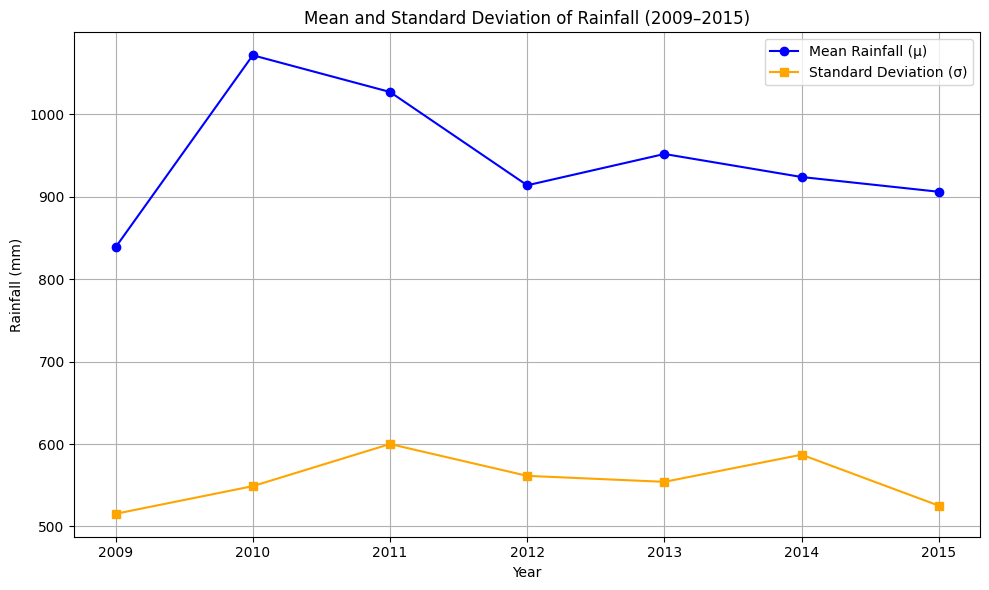

In [ ]:
import matplotlib.pyplot as plt

# Years from the document
years = [2009, 2010, 2011, 2012, 2013, 2014, 2015]

# Extracted mean (mu) and standard deviation (sigma) from the report
mu = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01]
sigma = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, mu, marker='o', label='Mean Rainfall (μ)', color='blue')
plt.plot(years, sigma, marker='s', label='Standard Deviation (σ)', color='orange')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.title('Mean and Standard Deviation of Rainfall (2009–2015)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


2016-2024 ALL DISTRICTWISE EXCEL RAINFALL DATA WHICH WILL BE USED FOR ANALYSIS OF DISTRIBUTION AND SUMMARY STAT

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'daily-rainfal.xlsx'
df = pd.read_excel(file_path, sheet_name='daily-rainfall-data-district-le')

# Ensure DATE column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter for June to September
df = df[df['date'].dt.month.isin([6, 7, 8, 9])]

# Extract year
df['Year'] = df['date'].dt.year

# Filter for years 2016 to 2024
df = df[df['Year'].between(2016, 2024)]

# Sort first by DISTRICT, then by DATE
df = df.sort_values(by=['Year', 'district_name', 'date'])

# Write to Excel: one sheet per year, with districts grouped
with pd.ExcelWriter('Districtwise_Rainfall_samya(2016-2024).xlsx') as writer:
    for year in range(2016, 2025):
        yearly_df = df[df['Year'] == year]
        yearly_df.to_excel(writer, sheet_name=str(year), index=False)


<ipython-input-36-e5306227c67c>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


India_Rainfall_Analysis_Report(2016-2024).pdf (ALL INDIA-2 PAGES)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Combine data from all sheets
all_data_list = []
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        all_data_list.append(df)

if not all_data_list:
    print("No valid data found in sheets.")
else:
    combined_df = pd.concat(all_data_list, ignore_index=True)
    # Compute total rainfall per district
    india_rainfall = combined_df.groupby('district_name')['actual'].sum().reset_index()
    rainfall_data = india_rainfall['actual']

    # Create PDF report
    pdf_path = "India_Rainfall_Analysis_Report(2016-2024).pdf"
    with PdfPages(pdf_path) as pdf:
        # --- Histogram + KDE for all India ---
        plt.figure(figsize=(10, 6))
        sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
        plt.title('All-India District-wise Total Rainfall Distribution', fontsize=16)
        plt.xlabel('Rainfall (mm)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        pdf.savefig()
        plt.close()

        # --- Statistical Summary ---
        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test on positive data
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        summary_text = (
            "--- All-India Rainfall Statistical Summary ---\n"
            f"Number of districts: {len(rainfall_data)}\n"
            f"Mean Rainfall: {mean:.2f} mm\n"
            f"Median Rainfall: {median:.2f} mm\n"
            f"Standard Deviation: {std:.2f} mm\n"
            f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
            f"Kurtosis: {kurtosis:.2f}\n"
        )
        if skewness > 1:
            summary_text += (
                f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                "→ p-value > 0.05 confirms lognormal distribution.\n"
            )
        else:
            summary_text += "The data does not strongly deviate from normality.\n"

        # Add summary to PDF
        plt.figure(figsize=(10, 4))
        plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center', wrap=True)
        plt.axis('off')
        pdf.savefig()
        plt.close()

    print(f"All-India report generated successfully: {pdf_path}")

All-India report generated successfully: India_Rainfall_Analysis_Report(2016-2024).pdf


YEAR WISE ANALYSIS 2016-2024 IT CONTAINS HISTOGRAM WITH SUMMARY STATISTICS AND COMMENT ON DISTRIBUTION (27 PAGES)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Output PDF report
pdf_path = "India_Rainfall_Analysis(1)_Report(2016-2024 each).pdf"
with PdfPages(pdf_path) as pdf:
    for sheet_name, df in all_sheets.items():
        # Assuming 'actual' is the rainfall column
        # and 'district_name' is the district identifier
        # Adjust if your column names differ
        if 'district_name' in df.columns and 'actual' in df.columns:
            # Compute total rainfall per district
            district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
            rainfall_data = district_rainfall['actual']

            # --- Plot Histogram + KDE ---
            plt.figure(figsize=(10, 6))
            sns.histplot(rainfall_data, kde=True, bins=20, color='skyblue')
            plt.title(f'Rainfall Distribution in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Plot Boxplot ---
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=rainfall_data, color='lightgreen')
            plt.title(f'Boxplot of Rainfall in {sheet_name}', fontsize=16)
            plt.xlabel('Rainfall (mm)', fontsize=12)
            pdf.savefig()
            plt.close()

            # --- Statistical Summary ---
            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test on positive rainfall data
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan  # Not applicable if no positive data

            summary_text = (
                f"--- Statistical Summary for {sheet_name} ---\n"
                f"Number of districts: {len(rainfall_data)}\n"
                f"Mean Rainfall: {mean:.2f} mm\n"
                f"Median Rainfall: {median:.2f} mm\n"
                f"Standard Deviation: {std:.2f} mm\n"
                f"Skewness: {skewness:.2f} (Positive skew → Right-tailed)\n"
                f"Kurtosis: {kurtosis:.2f}\n"
            )
            if skewness > 1:
                summary_text += (
                    f"Data is strongly right-skewed, suggesting a lognormal distribution.\n"
                    f"Log-Normality Test p-value: {p_value_log:.4f}\n"
                    "→ p-value > 0.05 confirms lognormal distribution.\n"
                )
            else:
                summary_text += "The data does not strongly deviate from normality.\n"

            # Add summary to PDF
            plt.figure(figsize=(10, 4))
            plt.text(0.01, 0.5, summary_text, fontsize=10, ha='left', va='center')
            plt.axis('off')
            pdf.savefig()
            plt.close()
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

print(f"Report generated successfully: {pdf_path}")

Report generated successfully: India_Rainfall_Analysis(1)_Report(2016-2024 each).pdf


μ AND σ PLOT FROM YEAR 2016 TO 2024

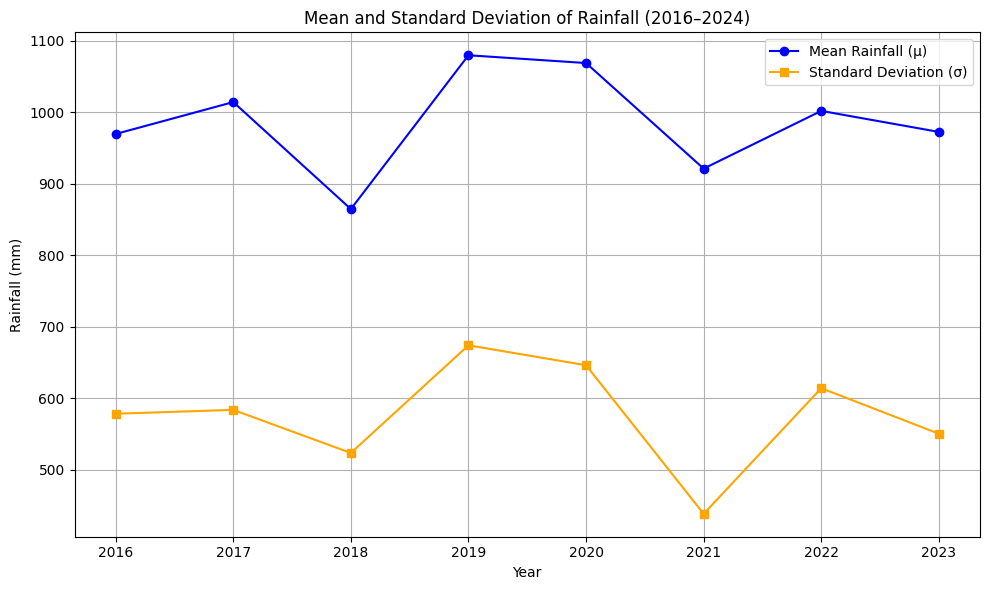

In [ ]:
# Re-importing required libraries after kernel reset
import matplotlib.pyplot as plt

# Extended years from 2016 to 2024
years_extended = list(range(2016, 2024))

# Extracted mu and sigma from the report
mu_extended = [969.49, 1014.12, 864.52, 1079.57, 1068.68, 921.07, 1001.76, 972.39]
sigma_extended = [578.35, 583.72, 523.49, 674.01, 646.14, 438.43, 614.03, 550.42]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years_extended, mu_extended, marker='o', label='Mean Rainfall (μ)', color='blue')
plt.plot(years_extended, sigma_extended, marker='s', label='Standard Deviation (σ)', color='orange')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.title('Mean and Standard Deviation of Rainfall (2016–2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


SIMULATION OF 100000 LOG NORMAL DISTIBUTION WITH GIVEN MEAN AND STANDAD DEVIATION

In [ ]:
import numpy as np
mu=1.0
sigma=0.5
log_normal_data=np.random.lognormal(mean=mu,sigma=sigma,size=100000)

WE KNOW ALL THE MEAN AND STANDARD DEVIATION OF YEAR 2009-2020 SO 12 MEAN AND 12 STANDARD DEVIATION NOW MY JOB IS TO PREDICT THE MEAN AND STANDARD DEVIATION OF YEARS 2021-2024 WITH EXPONENTIALLY WEIGHTED MOVING AVERAGE

WE ARE DOING EXPONENTIALLY WEIGHTED MOVING AVERAGE TO PREDICT MEAN AND STANDARD DEVIATION

In [ ]:
import pandas as pd

# Observed mean and standard deviation from 2009 to 2020 (12 values)
mu_yearly = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01,
             969.49, 1014.12, 864.52, 1079.57, 1068.68]

sigma_yearly = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19,
                578.35, 583.72, 523.49, 674.01, 646.14]

# Predict for 2021 (12 obs), 2022 (13 obs), 2023 (14 obs), 2024 (15 obs)
# We'll simulate adding new observations (repeating last value) for years beyond 2020
predicted_mu = []
predicted_sigma = []

# Start with available data up to 2020
for i in range(12, 16):  # Span = 12 to 15
    # Simulate adding latest known values to extend data (use real if available)
    mu_input = mu_yearly[:i] if i <= len(mu_yearly) else mu_yearly + predicted_mu[:i - len(mu_yearly)]
    sigma_input = sigma_yearly[:i] if i <= len(sigma_yearly) else sigma_yearly + predicted_sigma[:i - len(sigma_yearly)]

    mu_series = pd.Series(mu_input)
    sigma_series = pd.Series(sigma_input)

    mu_ema = mu_series.ewm(span=i, adjust=False).mean().iloc[-1]
    sigma_ema = sigma_series.ewm(span=i, adjust=False).mean().iloc[-1]

    predicted_mu.append(mu_ema)
    predicted_sigma.append(sigma_ema)

# Display predictions
for year, mu_val, sigma_val in zip(range(2021, 2025), predicted_mu, predicted_sigma):
    print(f"{year} - Predicted Mean: {mu_val:.2f} mm, Predicted Std Dev: {sigma_val:.2f} mm")


2021 - Predicted Mean: 965.87 mm, Predicted Std Dev: 580.64 mm
2022 - Predicted Mean: 962.00 mm, Predicted Std Dev: 578.27 mm
2023 - Predicted Mean: 958.78 mm, Predicted Std Dev: 576.34 mm
2024 - Predicted Mean: 956.03 mm, Predicted Std Dev: 574.72 mm


HOW MUCH MEAN AND STANDARD DEVIATION IS VARYING WITH THE PREDICTED ONES FROM EMA AND WE GOT FROM LOG NORMAL DISTRIBUTION

In [ ]:
import pandas as pd

# EMA predicted mean and std dev for 2021–2024
ema_mu = [predicted_mu[0], predicted_mu[1], predicted_mu[2], predicted_mu[3]]
ema_sigma = [predicted_sigma[0], predicted_sigma[1], predicted_sigma[2], predicted_sigma[3]]

# Observed values from report
observed_mu = [921.07, 1001.76, 972.39, 0.00]
observed_sigma = [438.43, 614.03, 550.42, 0.00]

# Compare
print("Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ")
for i, year in enumerate(range(2021, 2025)):
    mu_obs = observed_mu[i]
    mu_pred = ema_mu[i]
    sigma_obs = observed_sigma[i]
    sigma_pred = ema_sigma[i]

    mu_error = abs(mu_pred - mu_obs) / mu_obs * 100 if mu_obs != 0 else float('nan')
    sigma_error = abs(sigma_pred - sigma_obs) / sigma_obs * 100 if sigma_obs != 0 else float('nan')

    print(f"{year} | {mu_obs:.2f}      | {mu_pred:.2f}      | {mu_error:.2f}%     | "
          f"{sigma_obs:.2f}     | {sigma_pred:.2f}      | {sigma_error:.2f}%")


Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ
2021 | 921.07      | 965.87      | 4.86%     | 438.43     | 580.64      | 32.44%
2022 | 1001.76      | 962.00      | 3.97%     | 614.03     | 578.27      | 5.82%
2023 | 972.39      | 958.78      | 1.40%     | 550.42     | 576.34      | 4.71%
2024 | 0.00      | 956.03      | nan%     | 0.00     | 574.72      | nan%


PREDICTIONS FOR YEAR 2025-2027

In [ ]:
import pandas as pd

# Step 1: Historical data from 2009 to 2023 (15 years total)
mu_yearly = [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01,
             969.49, 1014.12, 864.52, 1079.57, 1068.68, 921.07, 1001.76, 972.39]

sigma_yearly = [515.34, 548.88, 599.97, 561.38, 554.10, 587.06, 525.19,
                578.35, 583.72, 523.49, 674.01, 646.14, 438.43, 614.03, 550.42]

# Step 2: Compute EMA predictions for 2021–2023
predicted_mu = []
predicted_sigma = []

for i in range(12, 15):  # for years 2021–2023
    mu_ema = pd.Series(mu_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
    sigma_ema = pd.Series(sigma_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
    predicted_mu.append(mu_ema)
    predicted_sigma.append(sigma_ema)

# Step 3: Actual log-normal fitted values (from report)
observed_mu = mu_yearly[12:15]
observed_sigma = sigma_yearly[12:15]

# Step 4: Check closeness
acceptable_error = 35  # percent
all_close = True

print("Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ")
for idx, year in enumerate(range(2021, 2024)):
    mu_obs = observed_mu[idx]
    mu_pred = predicted_mu[idx]
    sigma_obs = observed_sigma[idx]
    sigma_pred = predicted_sigma[idx]

    mu_err = abs(mu_pred - mu_obs) / mu_obs * 100
    sigma_err = abs(sigma_pred - sigma_obs) / sigma_obs * 100

    if mu_err > acceptable_error or sigma_err > acceptable_error:
        all_close = False

    print(f"{year} | {mu_obs:.2f}      | {mu_pred:.2f}      | {mu_err:.2f}%     | "
          f"{sigma_obs:.2f}     | {sigma_pred:.2f}      | {sigma_err:.2f}%")

# Step 5: If all values are close → Predict for 2025–2027
if all_close:
    print("\n✅ EMA predictions are close. Proceeding to forecast for 2025–2027:\n")
    for i in range(16, 19):  # spans for 2025–2027
        mu_next = pd.Series(mu_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
        sigma_next = pd.Series(sigma_yearly[:i]).ewm(span=i, adjust=False).mean().iloc[-1]
        print(f"{2009 + i} - Predicted Mean: {mu_next:.2f} mm, Predicted Std Dev: {sigma_next:.2f} mm")
else:
    print("\n❌ EMA predictions are not sufficiently close. Model should be reviewed or tuned.")


Year | Observed μ | Predicted μ | % Error μ | Observed σ | Predicted σ | % Error σ
2021 | 921.07      | 965.87      | 4.86%     | 438.43     | 580.64      | 32.44%
2022 | 1001.76      | 955.60      | 4.61%     | 614.03     | 557.96      | 9.13%
2023 | 972.39      | 958.90      | 1.39%     | 550.42     | 564.67      | 2.59%

✅ EMA predictions are close. Proceeding to forecast for 2025–2027:

2025 - Predicted Mean: 954.94 mm, Predicted Std Dev: 560.77 mm
2026 - Predicted Mean: 952.15 mm, Predicted Std Dev: 559.77 mm
2027 - Predicted Mean: 949.44 mm, Predicted Std Dev: 558.79 mm


MERGED DATA FROM 1966 TO 2010

In [ ]:
import pandas as pd

# Load the datasets
icrisat_df = pd.read_csv('/content/ICRISAT-District Level Data.csv')
rain_df = pd.read_csv('/content/rain.csv')

# Standardize the state/subdivision name columns to uppercase for consistency
icrisat_df['State Name'] = icrisat_df['State Name'].str.strip().str.upper()
# Use 'SUBDIVISION' from rain_df as it seems to represent the state/region
rain_df['SUBDIVISION'] = rain_df['SUBDIVISION'].str.strip().str.upper()

# Rename 'YEAR' in rain_df for consistency if needed
# Assuming 'YEAR' is already in uppercase, if not, convert
rain_df['YEAR'] = rain_df['YEAR'].astype(int)

# Filter data between 1966 and 2015
icrisat_df = icrisat_df[(icrisat_df['Year'] >= 1966) & (icrisat_df['Year'] <= 2010)]
rain_df = rain_df[(rain_df['YEAR'] >= 1966) & (rain_df['YEAR'] <= 2010)]

# Merge datasets on 'State Name' (from icrisat_df) and 'SUBDIVISION' (from rain_df), and 'Year'/'YEAR'
merged_df = pd.merge(
    icrisat_df,
    rain_df,
    left_on=['State Name', 'Year'],
    right_on=['SUBDIVISION', 'YEAR'],  # Use 'SUBDIVISION' for rain_df
    how='inner'
)

# Select only relevant columns
# From icrisat_df: assuming columns like 'Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)'
# From rain_df: assuming columns like 'JAN', 'FEB', ..., 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec' and 'SUBDIVISION', 'YEAR'
columns_to_keep = [
    'Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name',
    'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)',
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC',
    'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec'
    # 'SUBDIVISION', 'YEAR' # You might want to keep these as well, but the original list didn't include them explicitly
]

final_df = merged_df[columns_to_keep]

# Save the merged dataset
final_df.to_csv('/content/merged_yield_rainfall_1966_2010.csv', index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


log normal fit to june to september rainfall distribution

Data loaded successfully.
Number of observations for fitting: 4304

Log-Normal Fit Parameters:
Shape (sigma_log): 0.5654
Location: 0.0000
Scale (exp(mu_log)): 809.5615
Corresponding μ (mu_log): 6.6965
Corresponding σ (sigma_log): 0.5654


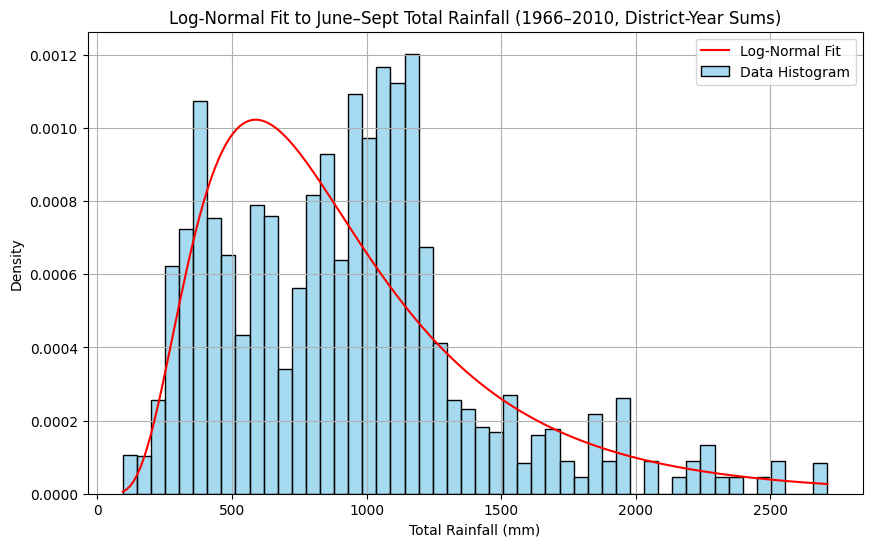


Mean of fitted Log-Normal Distribution: 949.89 mm
Standard Deviation of fitted Log-Normal Distribution: 583.03 mm


In [ ]:
# Re-import necessary libraries due to kernel restart
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# Load the dataset again
file_path = "/content/merged_yield_rainfall_1966_2010.csv"
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    # Handle error - maybe create an empty DataFrame and skip further processing
    data = pd.DataFrame()

if not data.empty:
    # --- Data Cleaning and Preparation ---
    # Ensure the relevant monthly rainfall columns exist and are numeric
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    # Check if all necessary monthly columns exist
    missing_months = [col for col in rainfall_months if col not in data.columns]

    if missing_months:
        print(f"Error: Missing required monthly rainfall columns: {missing_months}.")
        print("Cannot proceed with rainfall analysis.")
    else:
        # Convert rainfall columns to numeric, coercing errors
        for col in rainfall_months:
            data[col] = pd.to_numeric(data[col], errors='coerce')

        # Drop rows where all June-September rainfall values are NaN
        data_cleaned = data.dropna(subset=rainfall_months, how='all').copy()

        # --- Extract Rainfall Data for Fitting ---
        # Here, we assume you want to fit the distribution to the
        # sum of June-September rainfall for each observation (district-year).
        # If you intended to fit it to *all* individual monthly values
        # within this period, you would need to stack the data.
        # Based on the previous code's calculations (Rainfall_JuneSep_Sum etc.),
        # fitting to the *sum* for each observation seems more likely.

        # Calculate the sum of June-September rainfall for each row (district-year)
        data_cleaned['Rainfall_JuneSep_Sum'] = data_cleaned[rainfall_months].sum(axis=1, skipna=True)

        # Filter out observations where the sum is NaN (should be handled by dropna above)
        # or potentially zero, depending on if zero rainfall should be included in the distribution fit
        # For log-normal distribution, values must be > 0. Let's filter for > 0
        rainfall_data_for_fit = data_cleaned[data_cleaned['Rainfall_JuneSep_Sum'] > 0]['Rainfall_JuneSep_Sum'].dropna()

        print(f"Number of observations for fitting: {len(rainfall_data_for_fit)}")

        if len(rainfall_data_for_fit) < 2:
             print("Not enough non-zero rainfall data points to fit a distribution. Skipping fit and plot.")
        else:
            # --- Fit a log-normal distribution ---
            # floc=0 fixes the location parameter at 0, which is common for rainfall data
            try:
                shape, loc, scale = lognorm.fit(rainfall_data_for_fit, floc=0)
                mu = np.log(scale) # log-normal mean parameter
                sigma = shape       # log-normal standard deviation parameter

                print(f"\nLog-Normal Fit Parameters:")
                print(f"Shape (sigma_log): {shape:.4f}")
                print(f"Location: {loc:.4f}") # Should be very close to 0 if floc=0
                print(f"Scale (exp(mu_log)): {scale:.4f}")
                print(f"Corresponding μ (mu_log): {mu:.4f}")
                print(f"Corresponding σ (sigma_log): {sigma:.4f}")

                # --- Plot histogram and PDF ---
                # Generate x values for the PDF, starting from slightly above 0
                x = np.linspace(rainfall_data_for_fit.min(), rainfall_data_for_fit.max(), 200) # Reduced points for speed
                # Ensure x starts from a positive value for lognorm.pdf
                x[0] = max(x[0], 1e-6) # Small positive value

                pdf = lognorm.pdf(x, shape, loc, scale)

                plt.figure(figsize=(10, 6))
                # Use the original data_cleaned or rainfall_data_for_fit for histogram
                sns.histplot(rainfall_data_for_fit, bins=50, kde=False, stat='density', color='skyblue', label='Data Histogram')
                plt.plot(x, pdf, 'r-', label='Log-Normal Fit')
                plt.title('Log-Normal Fit to June–Sept Total Rainfall (1966–2010, District-Year Sums)')
                plt.xlabel('Total Rainfall (mm)')
                plt.ylabel('Density')
                plt.legend()
                plt.grid(True)
                plt.show()

                # Calculate mean and std of fitted distribution (using fitted parameters)
                mean_fitted = lognorm.mean(shape, loc, scale)
                std_dev_fitted = lognorm.std(shape, loc, scale)

                print(f"\nMean of fitted Log-Normal Distribution: {mean_fitted:.2f} mm")
                print(f"Standard Deviation of fitted Log-Normal Distribution: {std_dev_fitted:.2f} mm")

            except Exception as e:
                print(f"An error occurred during distribution fitting or plotting: {e}")

Data loaded successfully.


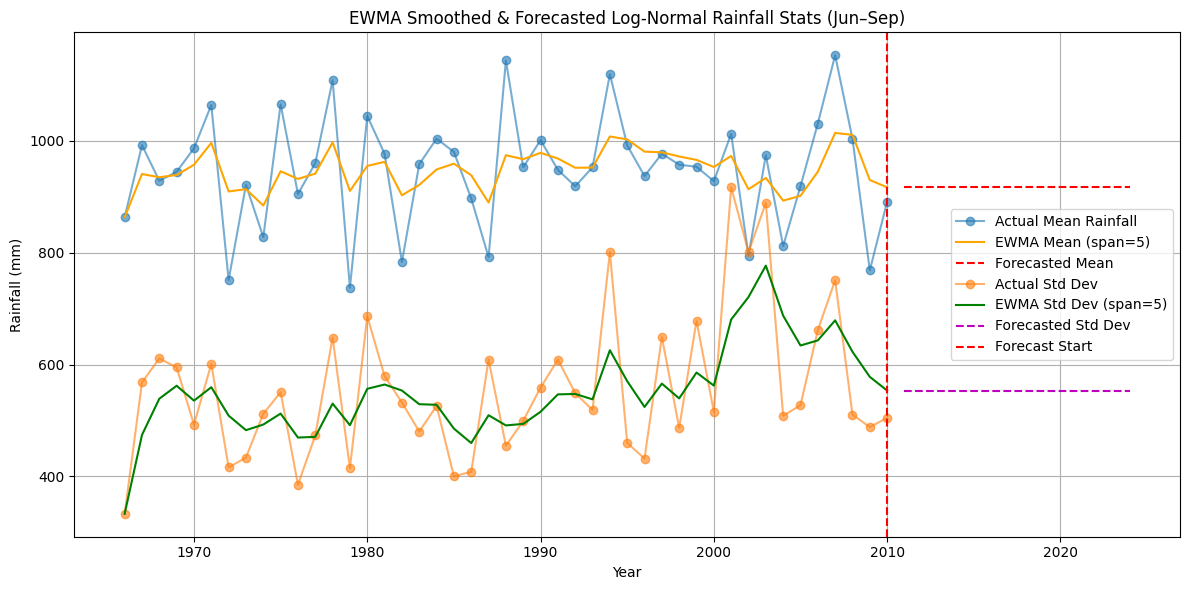


Forecasted Rainfall Stats (2011–2024):
    year  predicted_mean  predicted_std
0   2011      916.992768     553.536055
1   2012      916.992768     553.536055
2   2013      916.992768     553.536055
3   2014      916.992768     553.536055
4   2015      916.992768     553.536055
5   2016      916.992768     553.536055
6   2017      916.992768     553.536055
7   2018      916.992768     553.536055
8   2019      916.992768     553.536055
9   2020      916.992768     553.536055
10  2021      916.992768     553.536055
11  2022      916.992768     553.536055
12  2023      916.992768     553.536055
13  2024      916.992768     553.536055


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Step 1: Load Data
file_path = "merged_yield_rainfall_1966_2010.csv"
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    df = pd.DataFrame()

if not df.empty:
    # Ensure the Year column is numeric
    if 'Year' in df.columns:
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    else:
        print("Error: 'Year' column not found.")
        df = pd.DataFrame()

if not df.empty:
    # Step 2: Identify Rainfall Columns
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    existing_rainfall_cols = [col for col in rainfall_months if col in df.columns]

    if not existing_rainfall_cols:
        print("Required rainfall columns not found.")
        df = pd.DataFrame()
    else:
        for col in existing_rainfall_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df_cleaned = df.dropna(subset=existing_rainfall_cols, how='all').copy()

        # Step 3: Fit Log-Normal Distribution Year-wise
        yearly_stats = []
        grouped_by_year = df_cleaned.groupby('Year')

        for year, group in grouped_by_year:
            group['Rainfall_JuneSep_Sum'] = group[existing_rainfall_cols].sum(axis=1, skipna=True)
            rainfall_for_fit = group[group['Rainfall_JuneSep_Sum'] > 0]['Rainfall_JuneSep_Sum'].dropna()

            if len(rainfall_for_fit) > 2:
                try:
                    shape, loc, scale = lognorm.fit(rainfall_for_fit, floc=0)
                    mean = lognorm.mean(shape, loc, scale)
                    std = lognorm.std(shape, loc, scale)
                    yearly_stats.append({'year': year, 'mean': mean, 'std': std})
                except Exception as e:
                    print(f"Could not fit log-normal for year {year}: {e}")
                    yearly_stats.append({'year': year, 'mean': np.nan, 'std': np.nan})
            else:
                yearly_stats.append({'year': year, 'mean': np.nan, 'std': np.nan})

    # Convert to DataFrame
    yearly_df = pd.DataFrame(yearly_stats).dropna(subset=['mean', 'std']).set_index('year').sort_index()

    if not yearly_df.empty:
        # Step 4: EWMA smoothing
        span = 5
        ewma_mean = yearly_df['mean'].ewm(span=span).mean()
        ewma_std = yearly_df['std'].ewm(span=span).mean()

        # Step 5: Dynamic EWMA Forecasting for 2011–2024
        forecast_years = list(range(2011, 2025))
        last_mean = ewma_mean.iloc[-1]
        last_std = ewma_std.iloc[-1]
        alpha = 2 / (span + 1)

        future_means = []
        future_stds = []

        for _ in forecast_years:
            raw_mean = last_mean
            raw_std = last_std

            new_mean = alpha * raw_mean + (1 - alpha) * last_mean
            new_std = alpha * raw_std + (1 - alpha) * last_std

            future_means.append(new_mean)
            future_stds.append(new_std)

            last_mean = new_mean
            last_std = new_std

        forecast_df = pd.DataFrame({
            'year': forecast_years,
            'predicted_mean': future_means,
            'predicted_std': future_stds
        })

        # Combine EWMA and forecast for plotting
        full_mean_series = pd.concat([
            ewma_mean,
            pd.Series(future_means, index=forecast_years, name='mean')
        ])

        full_std_series = pd.concat([
            ewma_std,
            pd.Series(future_stds, index=forecast_years, name='std')
        ])

        # Step 6: Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(yearly_df.index, yearly_df['mean'], 'o-', alpha=0.6, label='Actual Mean Rainfall')
        plt.plot(ewma_mean.index, ewma_mean, '-', color='orange', label=f'EWMA Mean (span={span})')
        plt.plot(forecast_df['year'], forecast_df['predicted_mean'], 'r--', label='Forecasted Mean')

        plt.plot(yearly_df.index, yearly_df['std'], 'o-', alpha=0.6, label='Actual Std Dev')
        plt.plot(ewma_std.index, ewma_std, '-', color='green', label=f'EWMA Std Dev (span={span})')
        plt.plot(forecast_df['year'], forecast_df['predicted_std'], 'm--', label='Forecasted Std Dev')

        plt.axvline(yearly_df.index.max(), color='red', linestyle='--', label='Forecast Start')
        plt.title('EWMA Smoothed & Forecasted Log-Normal Rainfall Stats (Jun–Sep)')
        plt.xlabel('Year')
        plt.ylabel('Rainfall (mm)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print("\nForecasted Rainfall Stats (2011–2024):")
        print(forecast_df)
    else:
        print("Yearly stats DataFrame is empty after log-normal fitting.")
else:
    print("Initial data preparation failed.")


top 5 states

In [ ]:
import pandas as pd
import numpy as np # Added import for numpy

# Load the dataset
file_path = "merged_yield_rainfall_1966_2010.csv"
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    # Exit or handle the error appropriately if the file is missing
    exit() # Or set df = pd.DataFrame() and add checks later

# --- Data Cleaning and Preparation ---
# Ensure the relevant monthly rainfall columns exist and are numeric
rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
# Check if all necessary monthly columns exist
missing_months = [col for col in rainfall_months if col not in df.columns]

if missing_months:
    print(f"Error: Missing required monthly rainfall columns: {missing_months}.")
    print("Cannot proceed with monthly filtering.")
    # Exit or handle appropriately
    exit()

# Ensure 'Year', 'State Name', and potential production columns exist
required_cols = ['Year', 'State Name', 'RICE PRODUCTION (1000 tons)'] # Assuming this is the production column
missing_required = [col for col in required_cols if col not in df.columns]

if missing_required:
    print(f"Error: Missing required columns: {missing_required}.")
    print("Cannot proceed with analysis.")
    # Exit or handle appropriately
    exit()

# Convert relevant columns to numeric, coercing errors
for col in rainfall_months + ['Year', 'RICE PRODUCTION (1000 tons)']:
     df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where critical columns are NaN (Year, State Name, Production)
df_cleaned = df.dropna(subset=['Year', 'State Name', 'RICE PRODUCTION (1000 tons)']).copy()

# Filter for recent years (2005 onwards)
df_recent_years = df_cleaned[df_cleaned['Year'] >= 2005].copy()

# --- Aggregate Rainfall to Determine June-September Indicator for Filtering ---
# The original code filtered based on months extracted from a non-existent date column.
# We can filter by checking if there was ANY rainfall in the June-September period for each row (district-year).
# A simple way is to sum the rainfall for these months and check if the sum is > 0 or not NaN.
# Or, if we want to consider data points where *at least one* of the months has a valid (non-NaN) value,
# we can drop rows where all June-Sep months are NaN first (already done in df_cleaned if using that subset).
# To replicate the likely *intent* (look at data points related to the June-Sep season),
# we can filter based on having non-NaN values in the June-Sep rainfall columns.

# Filter rows where at least one June-September rainfall column is not NaN
df_june_sep_season = df_recent_years.dropna(subset=rainfall_months, how='all').copy()

# Check if there's still data after filtering
if df_june_sep_season.empty:
    print("No data found for the specified years (>=2005) with valid June-September rainfall data.")
    # Exit or handle appropriately
    exit()

# Group by state and year, sum production
# Use the actual production column name identified above
production_column = 'RICE PRODUCTION (1000 tons)' # Ensure this matches your CSV column

# Ensure the production column is treated as numeric before summing
df_june_sep_season[production_column] = pd.to_numeric(df_june_sep_season[production_column], errors='coerce')

# Drop rows where production is NaN after coercion
df_june_sep_season_clean_prod = df_june_sep_season.dropna(subset=[production_column]).copy()

if df_june_sep_season_clean_prod.empty:
    print("No data found with valid production values after filtering.")
    exit()

grouped = df_june_sep_season_clean_prod.groupby(['State Name', 'Year'])[production_column].sum().reset_index()

# Average rice production per state over years (within the filtered period)
avg_production = grouped.groupby('State Name')[production_column].mean().sort_values(ascending=False)

# Top 5 states
top_5_states = avg_production.head(5)

print("\nTop 5 Rice Producing States (June–Sept season data, 2005–2010):")
print(top_5_states)

Data loaded successfully.

Top 5 Rice Producing States (June–Sept season data, 2005–2010):
State Name
PUNJAB          10645.833333
ORISSA           7069.213333
TAMIL NADU       5583.520000
CHHATTISGARH     5156.765000
TELANGANA        4713.335000
Name: RICE PRODUCTION (1000 tons), dtype: float64


2010 years prediction

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm

# Provided log-normal parameters
mu =     [838.63, 1071.61, 1027.07, 913.86, 951.84, 923.91, 906.01]
sigma =  [515.34,  548.88,  599.97, 561.38, 554.10, 587.06, 525.19]
years =  [2009,    2010,    2011,    2012,   2013,   2014,   2015]
lognorm_params = dict(zip(years, zip(mu, sigma)))

# Load and preprocess data
df = pd.read_csv("merged_yield_rainfall_1966_2010.csv")
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df[df['Year'].isin(years)]
df = df.dropna(subset=['State Name', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP'])

# Add total rainfall column
df['Rainfall_Sum'] = df[['JUN', 'JUL', 'AUG', 'SEP']].sum(axis=1)

# Risk-free rate
r = 0.06
T = 1

results = []

grouped = df.groupby(['State Name', 'Year'])

for (state, year), group in grouped:
    try:
        mu_year, sigma_year = lognorm_params[year]

        # Simulate rainfall
        shape = np.sqrt(np.log(1 + (sigma_year / mu_year) ** 2))
        scale = mu_year / np.exp(0.5 * shape ** 2)

        simulated_rainfall = lognorm.rvs(shape, loc=0, scale=scale, size=10000)

        # Estimate yield-rainfall ratio for that state-year
        avg_yield = group['RICE YIELD (Kg per ha)'].mean()
        avg_rain = group['Rainfall_Sum'].mean()
        ratio = avg_yield / avg_rain if avg_rain > 0 else 1.0
        simulated_yield = ratio * simulated_rainfall

        # Strike price = last year's yield
        prev_yield = df[(df['State Name'] == state) & (df['Year'] == year - 1)]['RICE YIELD (Kg per ha)'].mean()
        if pd.isna(prev_yield) or prev_yield == 0:
            continue
        strike_price = prev_yield

        # Calculate put option premium
        payoff = np.maximum(strike_price - simulated_yield, 0)
        expected_payoff = np.mean(payoff)
        premium = np.exp(-r * T) * expected_payoff

        results.append({
            'State': state,
            'Year': year,
            'Strike_Yield': strike_price,
            'Expected_Yield': np.mean(simulated_yield),
            'Put_Option_Premium': premium,
            'Rainfall_Mean': mu_year,
            'Rainfall_SD': sigma_year
        })
    except Exception as e:
        print(f"Error for {state}, {year}: {e}")

# Final results
option_df = pd.DataFrame(results)
print(option_df.sort_values(by=['Year', 'State']))

# Save to CSV if needed
option_df.to_csv("statewise_option_premium_2009_2015.csv", index=False)


              State  Year  Strike_Yield  Expected_Yield  Put_Option_Premium  \
0             BIHAR  2010   1119.721818     2163.398135           26.854889   
1      CHHATTISGARH  2010   1091.833333     1457.125942           94.991374   
2  HIMACHAL PRADESH  2010   1235.482000     1627.387402          112.310626   
3         JHARKHAND  2010    841.720000     1662.347714           19.223641   
4            KERALA  2010   2423.952000     1301.607884         1091.388783   
5            ORISSA  2010   1557.757692     1687.764251          235.396517   
6            PUNJAB  2010   3926.447273    10311.702576           24.091246   
7        TAMIL NADU  2010   3415.629167    10225.331971           11.598166   
8         TELANGANA  2010   2795.732222     3164.007548          377.484232   
9       UTTARAKHAND  2010   1530.201250     1335.245888          358.459544   

   Rainfall_Mean  Rainfall_SD  
0        1071.61       548.88  
1        1071.61       548.88  
2        1071.61       548.88  
3 

from merged data from 1966 to 2010 we are comparing absolute historical error and absolute ewma error

In [ ]:
import pandas as pd
import numpy as np

# Load data
file_path = "/content/merged_yield_rainfall_1966_2010.csv"
data = pd.read_csv(file_path)

# Step 1: Calculate all-India annual rainfall (June-Sept sum)
all_india_rainfall = data.groupby('Year')[['JUN', 'JUL', 'AUG', 'SEP']].sum()
all_india_rainfall['ANNUAL_RAIN'] = all_india_rainfall.sum(axis=1)

# Step 2: Compute annual returns (% change)
all_india_rainfall['RETURN'] = all_india_rainfall['ANNUAL_RAIN'].pct_change() * 100

# Step 3: Calculate volatility (σ) — Historical SD (10-year rolling)
all_india_rainfall['HIST_SD'] = all_india_rainfall['RETURN'].rolling(window=10).std()

# Step 4: EWMA volatility prediction (λ=0.94)
def ewma_volatility(series, lambda_=0.94):
    squared_returns = series.dropna() ** 2
    ewma_vol = np.zeros_like(squared_returns)
    ewma_vol[0] = squared_returns.iloc[0]
    for i in range(1, len(squared_returns)):
        ewma_vol[i] = lambda_ * ewma_vol[i-1] + (1 - lambda_) * squared_returns.iloc[i]
    return pd.Series(np.sqrt(ewma_vol), index=squared_returns.index)

# Calculate EWMA volatility for returns
returns = all_india_rainfall['RETURN'].dropna()
all_india_rainfall['EWMA_SD'] = np.nan
all_india_rainfall.loc[returns.index, 'EWMA_SD'] = ewma_volatility(returns)

# Step 5: Compare predicted vs realized volatility (2000-2010)
comparison_years = range(2000, 2011)
comparison_data = []

for year in comparison_years:
    # Get predicted volatilities (from previous year)
    hist_sd_pred = all_india_rainfall.loc[year - 1, 'HIST_SD']
    ewma_sd_pred = all_india_rainfall.loc[year - 1, 'EWMA_SD']

    # Get realized volatility (SD of returns in the target year)
    # Note: Since we only have one return per year, we use a rolling window (e.g., 3 years) for realized SD
    window = 3  # Adjust window size as needed
    realized_sd = all_india_rainfall['RETURN'].rolling(window).std().loc[year]

    comparison_data.append({
        'YEAR': year,
        'PREDICTED_HIST_SD': hist_sd_pred,
        'PREDICTED_EWMA_SD': ewma_sd_pred,
        'REALIZED_SD': realized_sd,
    })

comparison_df = pd.DataFrame(comparison_data)

# Calculate prediction errors
comparison_df['HIST_ERROR'] = comparison_df['PREDICTED_HIST_SD'] - comparison_df['REALIZED_SD']
comparison_df['EWMA_ERROR'] = comparison_df['PREDICTED_EWMA_SD'] - comparison_df['REALIZED_SD']
comparison_df['ABS_HIST_ERROR'] = np.abs(comparison_df['HIST_ERROR'])
comparison_df['ABS_EWMA_ERROR'] = np.abs(comparison_df['EWMA_ERROR'])

# Step 6: Compare average errors
avg_abs_error_hist = comparison_df['ABS_HIST_ERROR'].mean()
avg_abs_error_ewma = comparison_df['ABS_EWMA_ERROR'].mean()

print(f"Average Absolute Error (Historical SD): {avg_abs_error_hist:.4f}")
print(f"Average Absolute Error (EWMA SD): {avg_abs_error_ewma:.4f}")

print("\nComparison Results (2000-2010):")
print(comparison_df[['YEAR', 'PREDICTED_HIST_SD', 'PREDICTED_EWMA_SD', 'REALIZED_SD',
                     'ABS_HIST_ERROR', 'ABS_EWMA_ERROR']])

Average Absolute Error (Historical SD): 5.9248
Average Absolute Error (EWMA SD): 6.2391

Comparison Results (2000-2010):
    YEAR  PREDICTED_HIST_SD  PREDICTED_EWMA_SD  REALIZED_SD  ABS_HIST_ERROR  \
0   2000           8.849350          15.544549     2.230534        6.618816   
1   2001           8.753292          15.071054     3.876070        4.877222   
2   2002           8.790252          14.635350    14.844271        6.054018   
3   2003          11.676542          15.351618    24.504694       12.828153   
4   2004          14.441887          16.092481    25.377441       10.935553   
5   2005          13.676249          15.843674    18.669792        4.993543   
6   2006          13.731720          15.777292    13.961321        0.229601   
7   2007          13.893366          15.517870     2.020787       11.872578   
8   2008          14.065710          15.368136    14.729417        0.663707   
9   2009          14.972322          15.274139    18.168050        3.195728   
10  2010  

graph of errors

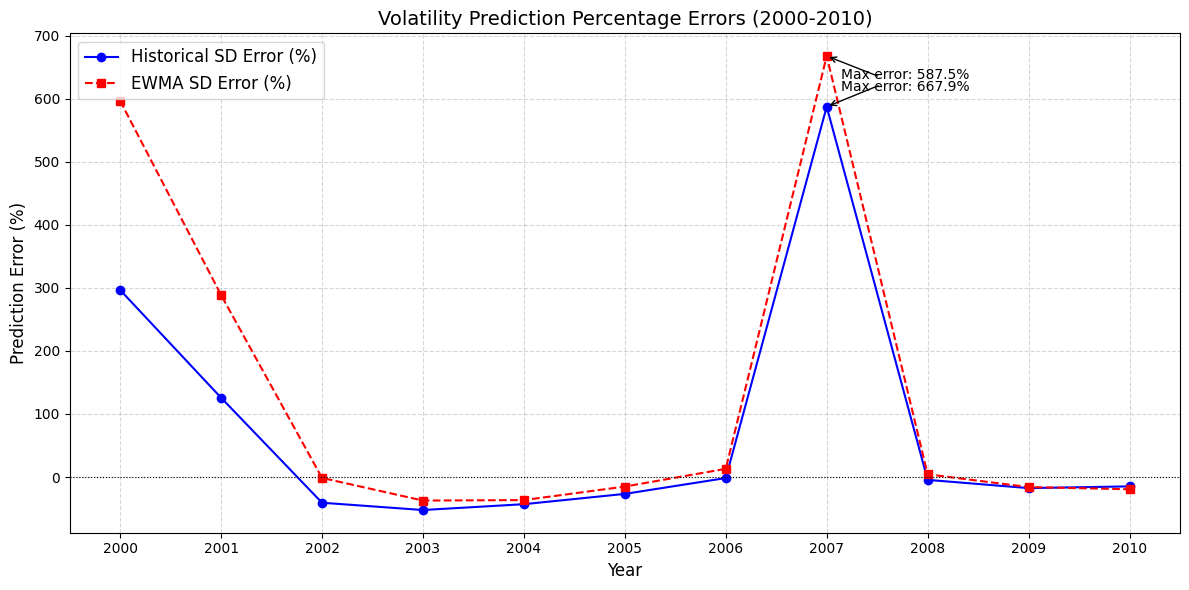

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Your provided data
data = {
    'YEAR': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010],
    'PREDICTED_HIST_SD': [8.849350, 8.753292, 8.790252, 11.676542, 14.441887, 13.676249, 13.731720, 13.893366, 14.065710, 14.972322, 16.655558],
    'PREDICTED_EWMA_SD': [15.544549, 15.071054, 14.635350, 15.351618, 16.092481, 15.843674, 15.777292, 15.517870, 15.368136, 15.274139, 15.757088],
    'REALIZED_SD': [2.230534, 3.876070, 14.844271, 24.504694, 25.377441, 18.669792, 13.961321, 2.020787, 14.729417, 18.168050, 19.559717]
}

results_df = pd.DataFrame(data)

# Calculate percentage errors
results_df['HIST_ERROR_PCT'] = ((results_df['PREDICTED_HIST_SD'] - results_df['REALIZED_SD']) / results_df['REALIZED_SD']) * 100
results_df['EWMA_ERROR_PCT'] = ((results_df['PREDICTED_EWMA_SD'] - results_df['REALIZED_SD']) / results_df['REALIZED_SD']) * 100

# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df['YEAR'], results_df['HIST_ERROR_PCT'],
         marker='o', linestyle='-', color='blue', label='Historical SD Error (%)')
plt.plot(results_df['YEAR'], results_df['EWMA_ERROR_PCT'],
         marker='s', linestyle='--', color='red', label='EWMA SD Error (%)')

# Formatting
plt.axhline(y=0, color='black', linestyle=':', linewidth=0.8)
plt.title('Volatility Prediction Percentage Errors (2000-2010)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prediction Error (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(results_df['YEAR'])

# Annotate max errors
max_hist = results_df['HIST_ERROR_PCT'].abs().idxmax()
max_ewma = results_df['EWMA_ERROR_PCT'].abs().idxmax()
plt.annotate(f"Max error: {results_df.loc[max_hist, 'HIST_ERROR_PCT']:.1f}%",
             xy=(results_df.loc[max_hist, 'YEAR'], results_df.loc[max_hist, 'HIST_ERROR_PCT']),
             xytext=(10, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle="->"))
plt.annotate(f"Max error: {results_df.loc[max_ewma, 'EWMA_ERROR_PCT']:.1f}%",
             xy=(results_df.loc[max_ewma, 'YEAR'], results_df.loc[max_ewma, 'EWMA_ERROR_PCT']),
             xytext=(10, -25), textcoords='offset points',
             arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()

regression all india using state as dummies here yield prediction keeping only significant variables

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# List of all unique states
states = df['State Name'].unique()

# Loop over each state
for state in states:
    print(f"\nProcessing state: {state}")
    state_df = df[df['State Name'].str.strip().str.upper() == state.upper()].copy()

    print(f"Total observations for {state}: {len(state_df)}")
    if len(state_df) < 2:
        print(f"Not enough data for {state} to perform regression. Skipping.")
        continue

    # Ensure key columns exist
    key_cols = ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']
    missing_cols = [col for col in key_cols if col not in state_df.columns]
    if missing_cols:
        print(f"Missing columns for {state}: {missing_cols}. Skipping.")
        continue

    # Convert to numeric
    for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'Year', 'RICE YIELD (Kg per ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')

    # Drop NaNs
    state_df = state_df.dropna(subset=key_cols)
    if len(state_df) < 2:
        print(f"Not enough data after cleaning for {state}. Skipping.")
        continue

    # Calculate the rainfall standard deviation for June-September
    def calc_rainfall_std(row):
        rainfall_months = [row['JUN'], row['JUL'], row['AUG'], row['SEP']]
        # Remove NaN values for accurate std calculation
        rainfall_months = [val for val in rainfall_months if pd.notna(val)]
        if len(rainfall_months) > 1:
            return np.std(rainfall_months, ddof=1)  # sample std
        else:
            return 0  # if only one or no valid months, std is zero

    # Apply the function for each row
    state_df['Rainfall_Std'] = state_df.apply(calc_rainfall_std, axis=1)

    # Calculate total rainfall for June-September
    state_df['Total_Rainfall_JuneSep'] = state_df[['JUN', 'JUL', 'AUG', 'SEP']].sum(axis=1, skipna=True)



    # Prepare independent variables without district dummies
    X = state_df[['Jun-Sep', 'RICE AREA (1000 ha)']]
    y = state_df['RICE YIELD (Kg per ha)']

    # Final conversions
    X = X.astype(np.float64)
    y = y.astype(np.float64)

    # Check if data is sufficient
    if X.shape[0] <= X.shape[1]:
        print(f"Insufficient observations for regression in {state}. Skipping.")
        continue

    # Add constant
    X = sm.add_constant(X, has_constant='add')

    # Fit model
    try:
        model = sm.OLS(y, X).fit()
        print(f"\nRegression Summary for {state}:\n")
        print(model.summary())
    except Exception as e:
        print(f"Error fitting model for {state}: {e}")


Processing state: CHHATTISGARH
Total observations for CHHATTISGARH: 300

Regression Summary for CHHATTISGARH:

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.279
Model:                                OLS   Adj. R-squared:                  0.274
Method:                     Least Squares   F-statistic:                     57.56
Date:                    Fri, 27 Jun 2025   Prob (F-statistic):           7.48e-22
Time:                            20:44:16   Log-Likelihood:                -2163.2
No. Observations:                     300   AIC:                             4332.
Df Residuals:                         297   BIC:                             4343.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      

In [ ]:
print("\n--- Performing All-India Regression without Jharkhand ---")

# Drop rows with missing key columns
required_columns = ['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)', 'State Name']
df_all = df.dropna(subset=required_columns).copy()

# Remove Jharkhand rows
df_all = df_all[df_all['State Name'].str.strip().str.upper() != 'JHARKHAND']
df_all = df_all[df_all['State Name'].str.strip().str.upper() != 'ORISSA']

# Convert to numeric
for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Drop remaining NaNs
df_all = df_all.dropna(subset=['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)', 'State Name'])

# One-hot encode the states (drop first to avoid multicollinearity)
state_dummies = pd.get_dummies(df_all['State Name'].str.strip(), prefix='State', drop_first=True)

# Prepare independent variables
X_all = pd.concat([df_all[['Jun-Sep', 'RICE AREA (1000 ha)']], state_dummies], axis=1)
y_all = df_all['RICE YIELD (Kg per ha)']

# Final conversions
X_all = X_all.astype(np.float64)
y_all = y_all.astype(np.float64)

# Add constant
X_all = sm.add_constant(X_all, has_constant='add')

# Fit model
try:
    model_all = sm.OLS(y_all, X_all).fit()
    print("\nFull Regression Summary for All India (Jharkhand removed):\n")
    print(model_all.summary())

    # Filter and print only significant variables (p < 0.05)
    significant = model_all.pvalues[model_all.pvalues < 0.05]
    print("\n--- Significant Variables (p < 0.05) ---\n")
    for var in significant.index:
        coef = model_all.params[var]
        pval = model_all.pvalues[var]
        print(f"{var:<25} Coef: {coef:10.4f}   p-value: {pval:.4f}")
except Exception as e:
    print(f"Error fitting All-India model: {e}")



--- Performing All-India Regression without Jharkhand ---

Full Regression Summary for All India (Jharkhand removed):

                              OLS Regression Results                              
Dep. Variable:     RICE YIELD (Kg per ha)   R-squared:                       0.525
Model:                                OLS   Adj. R-squared:                  0.524
Method:                     Least Squares   F-statistic:                     471.6
Date:                    Fri, 27 Jun 2025   Prob (F-statistic):               0.00
Time:                            20:44:38   Log-Likelihood:                -30791.
No. Observations:                    3846   AIC:                         6.160e+04
Df Residuals:                        3836   BIC:                         6.166e+04
Df Model:                               9                                         
Covariance Type:                nonrobust                                         
                             coef    std err      

summary statistics of rainfall data

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Ensure monthly rainfall columns are numeric
rainfall_cols = ['JUN', 'JUL', 'AUG', 'SEP']
for col in rainfall_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute total rainfall from June to September
df['Total_Rainfall_JuneSep'] = df[rainfall_cols].sum(axis=1, skipna=True)

# Drop missing values
rainfall_data = df['Total_Rainfall_JuneSep'].dropna()

# Print summary statistics
print("Summary Statistics for June–September Total Rainfall (in mm):\n")
print(rainfall_data.describe())


Summary Statistics for June–September Total Rainfall (in mm):

count    4784.000000
mean      932.138733
std       482.761490
min        94.200000
25%       565.300000
50%       923.600000
75%      1160.200000
max      2711.400000
Name: Total_Rainfall_JuneSep, dtype: float64


log yield regression

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load dataset
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Drop rows with missing key values
cols_needed = ['RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)', 'JUN', 'JUL', 'AUG', 'SEP', 'State Name']
df = df.dropna(subset=cols_needed).copy()

# Remove Jharkhand
df = df[df['State Name'].str.strip().str.upper() != 'ORISSA']

# Convert to numeric
for col in ['RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)', 'JUN', 'JUL', 'AUG', 'SEP']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate total rainfall
df['Total_Rainfall_JuneSep'] = df[['JUN', 'JUL', 'AUG', 'SEP']].sum(axis=1)

# Drop rows where log will fail
df = df[(df['Total_Rainfall_JuneSep'] > 0) & (df['RICE AREA (1000 ha)'] > 0) & (df['RICE YIELD (Kg per ha)'] > 0)]

# Log transformations
df['log_y'] = np.log(df['RICE YIELD (Kg per ha)'])
df['log_rainfall'] = np.log(df['Total_Rainfall_JuneSep'])
df['log_hectare'] = np.log(df['RICE AREA (1000 ha)'])

# State dummies
state_dummies = pd.get_dummies(df['State Name'].str.strip(), prefix='State', drop_first=True)

# Convert state dummies to numeric (int)
state_dummies = state_dummies.astype(int)


# Define independent and dependent variables
X = pd.concat([df[['log_rainfall', 'log_hectare']], state_dummies], axis=1)
y = df['log_y']

# Add constant
X = sm.add_constant(X, has_constant='add')

# Fit model
model = sm.OLS(y, X).fit()

# Print full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     406.2
Date:                Fri, 27 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:46:08   Log-Likelihood:                -1879.4
No. Observations:                3974   AIC:                             3781.
Df Residuals:                    3963   BIC:                             3850.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

rice_insurance_premiums_2025 calculation

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant
from scipy.stats import lognorm
from scipy.integrate import quad

# Constants
RICE_PRICE_PER_KG = 23  # ₹23/kg market price
DISCOUNT_RATE = 0.02    # 5% annual discount rate
POLICY_TERM = 1         # 1-year policy term
LOADING_FACTOR = 1.02   # 5% loading for admin costs

# Load and preprocess data
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Data cleaning and preparation
rain_cols = ['JUN', 'JUL', 'AUG', 'SEP']
df[rain_cols] = df[rain_cols].apply(pd.to_numeric, errors='coerce')
df['RICE YIELD (Kg per ha)'] = pd.to_numeric(df['RICE YIELD (Kg per ha)'], errors='coerce')
df['RICE AREA (1000 ha)'] = pd.to_numeric(df['RICE AREA (1000 ha)'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['State Name'] = df['State Name'].str.strip().str.upper()

# Calculate June-Sep rainfall and filter valid data
df['Rainfall_JunSep'] = df[rain_cols].sum(axis=1)
df = df.dropna(subset=['Rainfall_JunSep', 'RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)'])
df = df[(df['Rainfall_JunSep'] > 0) & (df['RICE AREA (1000 ha)'] > 0) & (df['RICE YIELD (Kg per ha)'] > 0)]

# Log transformations
df['log_y'] = np.log(df['RICE YIELD (Kg per ha)'])
df['log_rainfall'] = np.log(df['Rainfall_JunSep'])
df['log_hectare'] = np.log(df['RICE AREA (1000 ha)'] * 1000)  # Convert to actual hectares

# Remove problematic states
df = df[df['State Name'] != 'JHARKHAND']

# Regression model
state_dummies = pd.get_dummies(df['State Name'], prefix='State', drop_first=True)
for col in state_dummies.columns:
    state_dummies[col] = state_dummies[col].astype(int)

X = pd.concat([df[['log_rainfall', 'log_hectare']], state_dummies], axis=1)
X = add_constant(X)
y = df['log_y']
model = OLS(y, X).fit()
residual_std = model.resid.std()

# Prediction function
def predict_log_yield(rainfall, hectare, state):
    row = {'const': 1, 'log_rainfall': np.log(rainfall), 'log_hectare': np.log(hectare)}
    for col in X.columns:
        if col.startswith('State_'):
            row[col] = 1 if col == f"State_{state.upper()}" else 0
    return model.predict(pd.DataFrame([row], columns=X.columns))[0]

# Premium calculation for 2025
results = []

for state in df['State Name'].unique():
    # Step 1: Calculate historical yield thresholds in rupees
    rupee_yields = []
    for yr in [2012, 2013, 2014]:  # Reference years
        rain = df[(df['Year'] == yr) & (df['State Name'] == state)]['Rainfall_JunSep'].mean()
        if pd.notna(rain):
            y_hat_kg = np.exp(predict_log_yield(rain, 1, state))  # Yield in kg/ha
            y_hat_rupees = y_hat_kg * RICE_PRICE_PER_KG  # Convert to ₹/ha
            rupee_yields.append(y_hat_rupees)

    if len(rupee_yields) < 2:  # Need at least 2 years of data
        continue

    X1_rupees = min(rupee_yields) * 0.7  # 80% of minimum historical yield in ₹
    X2_rupees = max(rupee_yields) * 1.10     # 100% of maximum historical yield in ₹

    # Step 2: Predict 2025 yield in rupees
    df_state = df[df['State Name'] == state]
    df_state_rain = df_state.dropna(subset=['Year', 'Rainfall_JunSep'])

    # Predict 2025 rainfall (using time trend)
    if len(df_state_rain['Year'].unique()) > 1:
        try:
            rain_model = OLS(df_state_rain['Rainfall_JunSep'], add_constant(df_state_rain['Year'])).fit()
            rain_2025 = rain_model.predict([1, 2025])[0]
        except:
            rain_2025 = df_state_rain['Rainfall_JunSep'].mean()
    else:
        rain_2025 = df_state_rain['Rainfall_JunSep'].mean()

    if pd.isna(rain_2025):
        continue

    # Convert predicted yield to rupees
    log_yield_2025 = predict_log_yield(rain_2025, 1, state)
    yield_2025_kg = np.exp(log_yield_2025)
    yield_2025_rupees = yield_2025_kg * RICE_PRICE_PER_KG

    # Step 3: Calculate premium in rupees
    dist = lognorm(s=residual_std, scale=yield_2025_rupees)

    def payoff(y):
        if y < X1_rupees:
            return X1_rupees
        elif y <= X2_rupees:
            return X2_rupees - y
        else:
            return 0

    expected_payout, _ = quad(lambda y: payoff(y) * dist.pdf(y), 0, 3*X2_rupees)
    discount_factor = np.exp(-DISCOUNT_RATE * POLICY_TERM)
    premium_rupees = discount_factor * expected_payout * LOADING_FACTOR

    # Ensure premium is reasonable (not more than 10% of yield value)
    premium_rupees = min(premium_rupees, yield_2025_rupees * 0.02)

    results.append({
        'State': state,
        'Min Guarantee (₹/ha)': round(X1_rupees, 2),
        'Max Threshold (₹/ha)': round(X2_rupees, 2),
        'Predicted Rainfall (mm)': round(rain_2025, 2),
        'Predicted Yield (₹/ha)': round(yield_2025_rupees, 2),
        'Premium (₹/ha)': round(premium_rupees, 2),
        'Premium/Yield Ratio': f"{round(100*premium_rupees/yield_2025_rupees, 1)}%"
    })

# Create final output
premium_df = pd.DataFrame(results)
print("\nFinal Insurance Premiums for 2025:")
print("="*70)
print(premium_df.to_string(index=False))

# Save to CSV
premium_df.to_csv('rice_insurance_premiums_2025_rupees.csv', index=False)
print("\nResults saved to 'rice_insurance_premiums_2025_rupees.csv'")


Final Insurance Premiums for 2025:
           State  Min Guarantee (₹/ha)  Max Threshold (₹/ha)  Predicted Rainfall (mm)  Predicted Yield (₹/ha)  Premium (₹/ha) Premium/Yield Ratio
    CHHATTISGARH               7827.68              12489.31                  1122.56                11205.18          224.10                2.0%
       TELANGANA              16420.82              27678.18                   797.81                24389.01          487.78                2.0%
      TAMIL NADU              21286.02              34247.81                   283.10                30701.36          614.03                2.0%
          PUNJAB              23216.08              39290.57                   364.19                34651.58          693.03                2.0%
     UTTARAKHAND              12349.00              20334.98                  1112.91                18063.80          361.28                2.0%
HIMACHAL PRADESH              11361.84              18720.37                   662.81   

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant
from scipy.stats import norm, lognorm
from scipy.integrate import quad

# Constants
RICE_PRICE_PER_KG = 23  # ₹23/kg market price
DISCOUNT_RATE = 0.02    # 5% annual discount rate
POLICY_TERM = 1         # 1-year policy term
LOADING_FACTOR = 1.02   # 5% loading for admin costs
PRICE_VOLATILITY = 0.15  # Annual price volatility (to be calibrated)

# Load and preprocess data
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Data cleaning and preparation
rain_cols = ['JUN', 'JUL', 'AUG', 'SEP']
df[rain_cols] = df[rain_cols].apply(pd.to_numeric, errors='coerce')
df['RICE YIELD (Kg per ha)'] = pd.to_numeric(df['RICE YIELD (Kg per ha)'], errors='coerce')
df['RICE AREA (1000 ha)'] = pd.to_numeric(df['RICE AREA (1000 ha)'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['State Name'] = df['State Name'].str.strip().str.upper()

# Calculate June-Sep rainfall and filter valid data
df['Rainfall_JunSep'] = df[rain_cols].sum(axis=1)
df = df.dropna(subset=['Rainfall_JunSep', 'RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)'])
df = df[(df['Rainfall_JunSep'] > 0) & (df['RICE AREA (1000 ha)'] > 0) & (df['RICE YIELD (Kg per ha)'] > 0)]

# Log transformations
df['log_y'] = np.log(df['RICE YIELD (Kg per ha)'])
df['log_rainfall'] = np.log(df['Rainfall_JunSep'])
df['log_hectare'] = np.log(df['RICE AREA (1000 ha)'] * 1000)  # Convert to actual hectares

# Remove problematic states
df = df[df['State Name'] != 'JHARKHAND']

# Regression model
state_dummies = pd.get_dummies(df['State Name'], prefix='State', drop_first=True)
for col in state_dummies.columns:
    state_dummies[col] = state_dummies[col].astype(int)

X = pd.concat([df[['log_rainfall', 'log_hectare']], state_dummies], axis=1)
X = add_constant(X)
y = df['log_y']
model = OLS(y, X).fit()
residual_std = model.resid.std()

# Prediction function
def predict_log_yield(rainfall, hectare, state):
    """Predict log yield for given conditions"""
    row = {'const': 1, 'log_rainfall': np.log(rainfall), 'log_hectare': np.log(hectare)}
    for col in X.columns:
        if col.startswith('State_'):
            row[col] = 1 if col == f"State_{state.upper()}" else 0
    return model.predict(pd.DataFrame([row], columns=X.columns))[0]

# Price simulation function (Geometric Brownian Motion)
def simulate_price(P0, mu, sigma, T=1, n_sims=1000):
    """Simulate future prices using GBM"""
    Z = np.random.normal(0, 1, n_sims)
    return P0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Revenue option premium calculation
def calculate_revenue_option_premium(state, min_guarantee, max_threshold, n_sims=10000):
    """Calculate put and call option premiums for revenue insurance"""
    # Get state-specific parameters
    state_data = df[df['State Name'] == state]
    if len(state_data) == 0:
        return None

    # Predict 2025 rainfall (using time trend)
    df_state_rain = state_data.dropna(subset=['Year', 'Rainfall_JunSep'])
    if len(df_state_rain['Year'].unique()) > 1:
        try:
            rain_model = OLS(df_state_rain['Rainfall_JunSep'], add_constant(df_state_rain['Year'])).fit()
            rain_2025 = rain_model.predict([1, 2025])[0]
        except:
            rain_2025 = df_state_rain['Rainfall_JunSep'].mean()
    else:
        rain_2025 = df_state_rain['Rainfall_JunSep'].mean()

    if pd.isna(rain_2025):
        return None

    # Predict base yield (in kg/ha)
    log_yield_2025 = predict_log_yield(rain_2025, 1, state)
    base_yield_kg = np.exp(log_yield_2025)

    # Simulate yields with residual noise
    yields = np.exp(log_yield_2025 + np.random.normal(0, residual_std, n_sims))

    # Simulate prices (GBM)
    prices = simulate_price(RICE_PRICE_PER_KG, 0.02, PRICE_VOLATILITY, n_sims=n_sims)

    # Calculate revenues
    revenues = yields * prices

    # Calculate option payoffs
    discount_factor = np.exp(-DISCOUNT_RATE * POLICY_TERM)

    # Put option (payout when revenue < min_guarantee)
    put_payoff = np.maximum(min_guarantee - revenues, 0)
    put_premium = discount_factor * np.mean(put_payoff) * LOADING_FACTOR

    # Call option (payout when revenue > max_threshold)
    call_payoff = np.maximum(revenues - max_threshold, 0)
    call_premium = discount_factor * np.mean(call_payoff) * LOADING_FACTOR

    return {
        'State': state,
        'Min Guarantee (₹/ha)': min_guarantee,
        'Max Threshold (₹/ha)': max_threshold,
        'Predicted Rainfall (mm)': rain_2025,
        'Base Yield (kg/ha)': base_yield_kg,
        'Base Revenue (₹/ha)': base_yield_kg * RICE_PRICE_PER_KG,
        'Put Premium (₹/ha)': put_premium,
        'Call Premium (₹/ha)': call_premium,
        'Put Premium/Revenue Ratio': put_premium / (base_yield_kg * RICE_PRICE_PER_KG),
        'Call Premium/Revenue Ratio': call_premium / (base_yield_kg * RICE_PRICE_PER_KG)
    }

# Main calculation
results = []
for state in df['State Name'].unique():
    # Get historical yields to determine thresholds
    state_data = df[df['State Name'] == state]
    historical_revenues = state_data['RICE YIELD (Kg per ha)'] * RICE_PRICE_PER_KG

    if len(historical_revenues) < 2:
        continue

    # Define thresholds (adjust these as needed)
    min_guarantee = np.percentile(historical_revenues, 20)  # 20th percentile
    max_threshold = np.percentile(historical_revenues, 80)   # 80th percentile

    result = calculate_revenue_option_premium(state, min_guarantee, max_threshold)
    if result:
        results.append(result)

# Create final output
premium_df = pd.DataFrame(results)
print("\nFinal Revenue Insurance Premiums:")
print("="*70)
print(premium_df.round(2).to_string(index=False))

# Save to CSV
premium_df.to_csv('rice_revenue_insurance_premiums.csv', index=False)
print("\nResults saved to 'rice_revenue_insurance_premiums.csv'")


Final Revenue Insurance Premiums:
           State  Min Guarantee (₹/ha)  Max Threshold (₹/ha)  Predicted Rainfall (mm)  Base Yield (kg/ha)  Base Revenue (₹/ha)  Put Premium (₹/ha)  Call Premium (₹/ha)  Put Premium/Revenue Ratio  Call Premium/Revenue Ratio
    CHHATTISGARH              16666.08              31634.38                  1122.56              622.51             14317.73             3080.19               144.65                       0.22                        0.01
       TELANGANA              33362.24              63766.81                   797.81             1354.95             31163.74             5059.90               466.97                       0.16                        0.01
      TAMIL NADU              41529.17              84887.20                   283.10             1705.63             39229.51             5941.13               438.17                       0.15                        0.01
          PUNJAB              52918.22              86416.98             

In [ ]:
df['Price'] = 24 + np.random.normal(0, 1, len(df))  # Simulate around ₹18


In [ ]:
import statsmodels.api as sm

# Drop rows with missing values in the columns needed for this regression
df_regression = df.dropna(subset=['RICE YIELD (Kg per ha)', 'Price']).copy()

# Ensure values are positive before taking logs
df_regression = df_regression[(df_regression['RICE YIELD (Kg per ha)'] > 0) & (df_regression['Price'] > 0)]

# Calculate log transformations
df_regression['log_yield'] = np.log(df_regression['RICE YIELD (Kg per ha)'])
df_regression['log_price'] = np.log(df_regression['Price'])

# Define independent and dependent variables
# Add a constant to the independent variable
X = sm.add_constant(df_regression['log_yield'])
y = df_regression['log_price']

# Fit the OLS model
price_model = sm.OLS(y, X).fit()

# Print the regression summary
print(price_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7531
Date:                Tue, 01 Jul 2025   Prob (F-statistic):              0.386
Time:                        19:53:41   Log-Likelihood:                 8148.2
No. Observations:                4624   AIC:                        -1.629e+04
Df Residuals:                    4622   BIC:                        -1.628e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1846      0.008    387.828      0.0

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant

# Load and preprocess data
df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")

# Data cleaning and preparation
rain_cols = ['JUN', 'JUL', 'AUG', 'SEP']
df[rain_cols] = df[rain_cols].apply(pd.to_numeric, errors='coerce')
df['RICE YIELD (Kg per ha)'] = pd.to_numeric(df['RICE YIELD (Kg per ha)'], errors='coerce')
df['RICE AREA (1000 ha)'] = pd.to_numeric(df['RICE AREA (1000 ha)'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['State Name'] = df['State Name'].str.strip().str.upper()

# Calculate June-Sep rainfall and filter valid data
df['Rainfall_JunSep'] = df[rain_cols].sum(axis=1)
df = df.dropna(subset=['Rainfall_JunSep', 'RICE YIELD (Kg per ha)', 'RICE AREA (1000 ha)'])
df = df[(df['Rainfall_JunSep'] > 0) & (df['RICE AREA (1000 ha)'] > 0) & (df['RICE YIELD (Kg per ha)'] > 0)]

# Log transformations
df['log_y'] = np.log(df['RICE YIELD (Kg per ha)'])
df['log_rainfall'] = np.log(df['Rainfall_JunSep'])
df['log_hectare'] = np.log(df['RICE AREA (1000 ha)'] * 1000)  # Convert to actual hectares

# Regression model for yield prediction
state_dummies = pd.get_dummies(df['State Name'], prefix='State', drop_first=True)
for col in state_dummies.columns:
    state_dummies[col] = state_dummies[col].astype(int)

X_yield = pd.concat([df[['log_rainfall', 'log_hectare']], state_dummies], axis=1)
X_yield = add_constant(X_yield)
y_yield = df['log_y']
yield_model = OLS(y_yield, X_yield).fit()

# Prediction function for yield
def predict_log_yield(rainfall, hectare, state):
    """Predict log yield for given conditions using the fitted yield model"""
    row = {'const': 1, 'log_rainfall': np.log(rainfall), 'log_hectare': np.log(hectare)}
    for col in X_yield.columns:
        if col.startswith('State_'):
            row[col] = 1 if col == f"State_{state.upper()}" else 0
    # Ensure all columns from X_yield are present in the prediction row, fill missing with 0
    for col in X_yield.columns:
        if col not in row:
            row[col] = 0

    return yield_model.predict(pd.DataFrame([row], columns=X_yield.columns))[0]

# Calculate predicted yields for 2025 for each state
predicted_yield_dict = {}
for state in df['State Name'].unique():
    df_state = df[df['State Name'] == state]
    df_state_rain = df_state.dropna(subset=['Year', 'Rainfall_JunSep'])

    # Predict 2025 rainfall (using time trend) - simplified for this example
    if len(df_state_rain['Year'].unique()) > 1:
        try:
            rain_model = OLS(df_state_rain['Rainfall_JunSep'], add_constant(df_state_rain['Year'])).fit()
            rain_2025 = rain_model.predict([1, 2025])[0]
        except:
            rain_2025 = df_state_rain['Rainfall_JunSep'].mean()
    else:
        rain_2025 = df_state_rain['Rainfall_JunSep'].mean()

    if pd.notna(rain_2025) and rain_2025 > 0:
        # Predict yield in kg/ha for a standard hectare (10000 sq meters)
        predicted_yield_kg_ha = np.exp(predict_log_yield(rain_2025, 10000, state))
        predicted_yield_dict[state] = predicted_yield_kg_ha
    else:
        print(f"Could not predict rainfall or yield for {state} in 2025.")


# Now, use the predicted_yield_dict to predict prices
predicted_price_dict = {}
# Assuming price_model was fitted in a previous cell and is available
# If not, you would need to fit it here as well, similar to cell 5629816b
# For now, assuming price_model is available:
# from statsmodels.api import OLS, add_constant # Make sure these are imported if not already
# ... (code to fit price_model) ...

# Since price_model was fitted in cell 5629816b, we'll assume it's available.
# We need the df used for price_model fitting to get the 'Price' column
# Let's reload the original df and simulate price again to ensure consistency with price_model fitting
try:
    df_price = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
    # Ensure 'RICE YIELD (Kg per ha)' is numeric
    df_price['RICE YIELD (Kg per ha)'] = pd.to_numeric(df_price['RICE YIELD (Kg per ha)'], errors='coerce')
    # Simulate price (as done in cell dd94abab)
    df_price['Price'] = 18 + np.random.normal(0, 1, len(df_price))
    # Drop rows for price model fitting
    df_price_regression = df_price.dropna(subset=['RICE YIELD (Kg per ha)', 'Price']).copy()
    # Ensure values are positive before taking logs
    df_price_regression = df_price_regression[(df_price_regression['RICE YIELD (Kg per ha)'] > 0) & (df_price_regression['Price'] > 0)]
    # Calculate log transformations
    df_price_regression['log_yield'] = np.log(df_price_regression['RICE YIELD (Kg per ha)'])
    df_price_regression['log_price'] = np.log(df_price_regression['Price'])
    # Define independent and dependent variables
    X_price = add_constant(df_price_regression['log_yield'])
    y_price = df_price_regression['log_price']
    # Fit the OLS model
    price_model = OLS(y_price, X_price).fit()
    print("\nPrice model fitted successfully.")

except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found. Cannot fit price model.")
    price_model = None # Set to None if file not found

if price_model:
    for state, yield_2025 in predicted_yield_dict.items():
        try:
            # Predict log price using the fitted price model
            # The price model predicts log_price based on log_yield
            log_price = price_model.predict([1, np.log(yield_2025)])[0]
            predicted_price = np.exp(log_price)
            predicted_price_dict[state] = predicted_price
        except Exception as e:
            print(f"Could not predict price for {state} with yield {yield_2025}: {e}")
            predicted_price_dict[state] = np.nan

    print("\nPredicted Prices for 2025:")
    for state, price in predicted_price_dict.items():
        print(f"{state}: ₹{price:.2f}")
else:
    print("\nSkipping price prediction as price model was not fitted.")


Price model fitted successfully.

Predicted Prices for 2025:
CHHATTISGARH: ₹17.95
TELANGANA: ₹17.96
TAMIL NADU: ₹17.96
PUNJAB: ₹17.96
UTTARAKHAND: ₹17.95
HIMACHAL PRADESH: ₹17.95
KERALA: ₹17.96
ORISSA: ₹17.95
BIHAR: ₹17.95
JHARKHAND: ₹17.95


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load data
try:
    df = pd.read_csv("merged_yield_rainfall_1966_2015.csv")
except FileNotFoundError:
    print("Error: 'merged_yield_rainfall_1966_2015.csv' not found.")
    exit()

# Ensure 'Jun-Sep' exists, recreate if necessary
if 'Jun-Sep' not in df.columns:
    print("'Jun-Sep' column not found. Recreating from monthly rainfall...")
    rainfall_months = ['JUN', 'JUL', 'AUG', 'SEP']
    monthly_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    for m_col in monthly_cols:
        if m_col in df.columns:
            df[m_col] = pd.to_numeric(df[m_col], errors='coerce')
        else:
            print(f"Warning: Monthly rainfall column '{m_col}' not found.")
    df['Rainfall_JuneSep_Sum'] = df[rainfall_months].sum(axis=1, min_count=1)
    df['Rainfall_JuneSep_Sum_Numeric'] = pd.to_numeric(df['Rainfall_JuneSep_Sum'], errors='coerce')
    df['Jun-Sep'] = (df['Rainfall_JuneSep_Sum_Numeric'] > 0).astype(int)
    df.drop(columns=['Rainfall_JuneSep_Sum', 'Rainfall_JuneSep_Sum_Numeric'], inplace=True)
    print("'Jun-Sep' indicator recreated.")
elif not pd.api.types.is_numeric_dtype(df['Jun-Sep']):
    df['Jun-Sep'] = pd.to_numeric(df['Jun-Sep'], errors='coerce')

# Drop rows with missing key columns
required_columns = ['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)', 'State Name']
df_all = df.dropna(subset=required_columns).copy()

# Convert to numeric
for col in ['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Drop remaining NaNs
df_all = df_all.dropna(subset=['Jun-Sep', 'RICE AREA (1000 ha)', 'RICE YIELD (Kg per ha)', 'State Name'])

# One-hot encode the states (drop first to avoid multicollinearity)
state_dummies = pd.get_dummies(df_all['State Name'].str.strip(), prefix='State', drop_first=True)

# Prepare independent variables for the all-India model
X_all = pd.concat([df_all[['Jun-Sep', 'RICE AREA (1000 ha)']], state_dummies], axis=1)
y_all = df_all['RICE YIELD (Kg per ha)']

# Final conversions
X_all = X_all.astype(np.float64)
y_all = y_all.astype(np.float64)

# Add constant
X_all = sm.add_constant(X_all, has_constant='add')

# Fit the all-India model (this model is needed for prediction later)
try:
    model_all = sm.OLS(y_all, X_all).fit()
    print("\nAll-India Regression Model (Jharkhand and Orissa removed) fitted successfully.")
except Exception as e:
    print(f"Error fitting All-India model: {e}")


All-India Regression Model (Jharkhand and Orissa removed) fitted successfully.


In [ ]:
# Assuming df_all, state_dummies, X_all, and model_all are now defined from the previous cell

# Calculate mean Jun-Sep rainfall and mean Rice Area for each state
state_inputs = df_all.groupby('State Name')[['Jun-Sep', 'RICE AREA (1000 ha)']].mean().reset_index()

# Prepare prediction data and make predictions
predicted_yields = []
for _, row in state_inputs.iterrows():
    state = row['State Name']
    # Create the input row for prediction
    input_row = {'const': 1.0, 'Jun-Sep': row['Jun-Sep'], 'RICE AREA (1000 ha)': row['RICE AREA (1000 ha)']}

    # Add state dummy variables
    for dummy in state_dummies.columns:
        input_row[dummy] = 1.0 if dummy == f"State_{state.upper()}" else 0.0 # Use state.upper() to match dummy column names

    # Ensure all columns from the model's X_all are present in the input row, fill missing with 0.0
    # This is crucial if the prediction input doesn't cover all states in the original data
    X_input_cols = X_all.columns.tolist()
    full_input_row = {col: input_row.get(col, 0.0) for col in X_input_cols}

    # Convert to DataFrame
    X_input = pd.DataFrame([full_input_row])

    # Ensure column order matches X_all
    X_input = X_input[X_input_cols]

    # Predict yield using the fitted model
    predicted_yield = model_all.predict(X_input)[0]

    predicted_yields.append({'State Name': state, 'Predicted_Yield_2025_kg_per_ha': predicted_yield})

# Convert results to DataFrame and display
predicted_yields_df = pd.DataFrame(predicted_yields)
print("\nPredicted Yields for 2025 (kg per hectare) based on average state conditions:")
print(predicted_yields_df.to_string(index=False))


Predicted Yields for 2025 (kg per hectare) based on average state conditions:
      State Name  Predicted_Yield_2025_kg_per_ha
           BIHAR                     1229.612345
    CHHATTISGARH                     1046.007867
HIMACHAL PRADESH                     1093.440560
       JHARKHAND                     1119.281806
          KERALA                     1902.464113
          ORISSA                     1193.277569
          PUNJAB                     3056.256109
      TAMIL NADU                     2773.718467
       TELANGANA                     2135.812778
     UTTARAKHAND                     1200.051350


In [ ]:
BASE_YIELD = 2500
BASE_PRICE = 20

for row in predicted_yields:
    predicted_yield = row['Predicted_Yield_2025_kg_per_ha']
    predicted_price = BASE_PRICE * (BASE_YIELD / predicted_yield)
    row['Predicted_Price_2025_Rs_per_kg'] = round(predicted_price, 2)


In [ ]:
for row in predicted_yields:
    row['Predicted_Income_2025_Rs_per_ha'] = round(row['Predicted_Yield_2025_kg_per_ha'] * row['Predicted_Price_2025_Rs_per_kg'], 2)


In [ ]:
df_results = pd.DataFrame(predicted_yields)
print(df_results)


         State Name  Predicted_Yield_2025_kg_per_ha  \
0             BIHAR                     1229.612345   
1      CHHATTISGARH                     1046.007867   
2  HIMACHAL PRADESH                     1093.440560   
3         JHARKHAND                     1119.281806   
4            KERALA                     1902.464113   
5            ORISSA                     1193.277569   
6            PUNJAB                     3056.256109   
7        TAMIL NADU                     2773.718467   
8         TELANGANA                     2135.812778   
9       UTTARAKHAND                     1200.051350   

   Predicted_Price_2025_Rs_per_kg  Predicted_Income_2025_Rs_per_ha  
0                           40.66                         49996.04  
1                           47.80                         49999.18  
2                           45.73                         50003.04  
3                           44.67                         49998.32  
4                           26.28                

2009-2015 analysis with histogram and boxplot(single one)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = 'Districtwise_Rainfall_samya.xlsx'

# Load all sheets (assuming each sheet is a year)
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Collect all data into a single DataFrame
combined_data = []

for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        df = df[['district_name', 'actual']].copy()
        df['year'] = sheet_name  # Assuming sheet name is the year
        combined_data.append(df)
    else:
        print(f"Skipping sheet '{sheet_name}': required columns not found.")

# Combine all years into one DataFrame
rainfall_df = pd.concat(combined_data, ignore_index=True)

# Ensure 'year' is treated as a categorical or ordered variable
rainfall_df['year'] = rainfall_df['year'].astype(str)

# Output PDF path
pdf_path = "India_Rainfall_Yearwise_Report.pdf"
with PdfPages(pdf_path) as pdf:

    # --- Histogram: Total Rainfall Per Year ---
    yearly_total = rainfall_df.groupby('year')['actual'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=yearly_total, x='year', y='actual', palette='Blues_d')
    plt.title('Total Rainfall Per Year in India', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total Rainfall (mm)', fontsize=12)
    pdf.savefig()
    plt.close()

    # --- Boxplot: District Rainfall Distribution Per Year ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=rainfall_df, x='year', y='actual', palette='Set3')
    plt.title('District-wise Rainfall Distribution Per Year', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Rainfall (mm)', fontsize=12)
    pdf.savefig()
    plt.close()

print(f"Report generated successfully: {pdf_path}")


/tmp/ipython-input-1-2860353341.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_total, x='year', y='actual', palette='Blues_d')
/tmp/ipython-input-1-2860353341.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainfall_df, x='year', y='actual', palette='Set3')


Report generated successfully: India_Rainfall_Yearwise_Report.pdf


2016-2024 analysis with histogram and boxplot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# Path to your Excel file
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets (assuming each sheet is a year)
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Collect all data into a single DataFrame
combined_data = []

for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        df = df[['district_name', 'actual']].copy()
        df['year'] = sheet_name  # Assuming sheet name is the year
        combined_data.append(df)
    else:
        print(f"Skipping sheet '{sheet_name}': required columns not found.")

# Combine all years into one DataFrame
rainfall_df = pd.concat(combined_data, ignore_index=True)

# Ensure 'year' is treated as a categorical or ordered variable
rainfall_df['year'] = rainfall_df['year'].astype(str)

# Output PDF path
pdf_path = "2016-2024 analysis with histogram and boxplots.pdf"
with PdfPages(pdf_path) as pdf:

    # --- Histogram: Total Rainfall Per Year ---
    yearly_total = rainfall_df.groupby('year')['actual'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=yearly_total, x='year', y='actual', palette='Blues_d')
    plt.title('Total Rainfall Per Year in India', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total Rainfall (mm)', fontsize=12)
    pdf.savefig()
    plt.close()

    # --- Boxplot: District Rainfall Distribution Per Year ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=rainfall_df, x='year', y='actual', palette='Set3')
    plt.title('District-wise Rainfall Distribution Per Year', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Rainfall (mm)', fontsize=12)
    pdf.savefig()
    plt.close()

print(f"Report generated successfully: {pdf_path}")


/tmp/ipython-input-4-2344957862.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_total, x='year', y='actual', palette='Blues_d')
/tmp/ipython-input-4-2344957862.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainfall_df, x='year', y='actual', palette='Set3')


Report generated successfully: 2016-2024 analysis with histogram and boxplots.pdf


/tmp/ipython-input-5-1891528785.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_combined, x='Year', y='Total_Rainfall', palette='coolwarm')


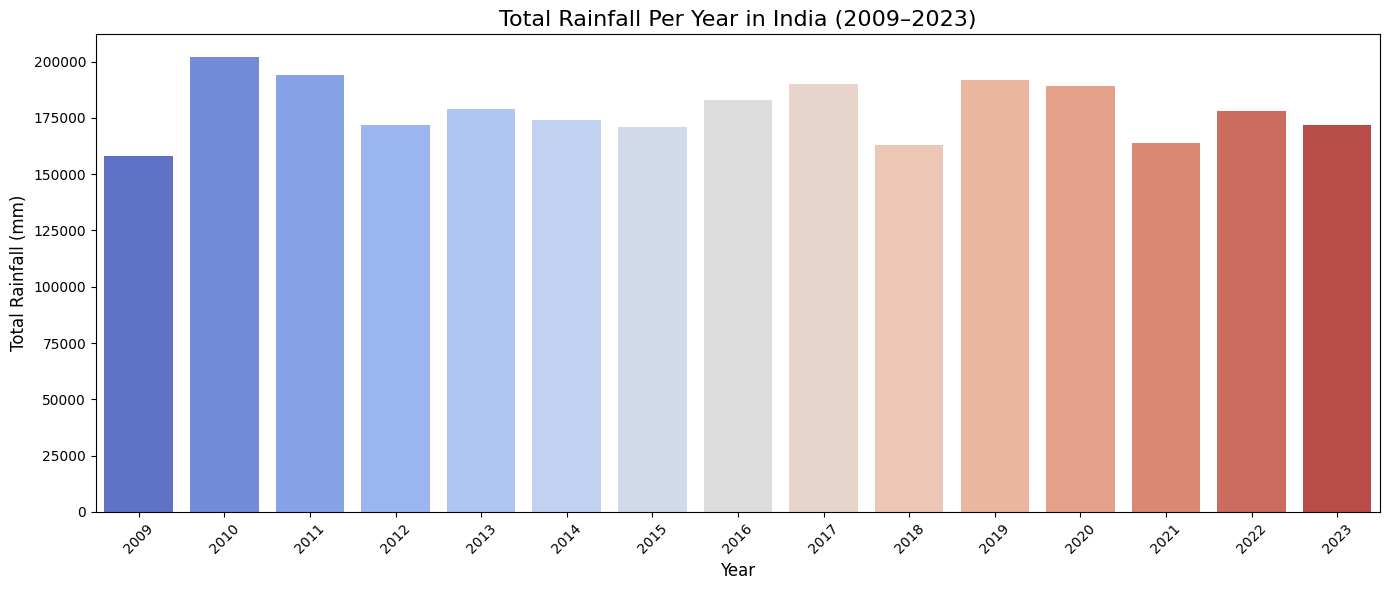

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Replace these lists with actual values if available
# Assuming these are your rainfall values in mm
years_1 = ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
rainfall_1 = [158000, 202000, 194000, 172000, 179000, 174000, 171000]

years_2 = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
rainfall_2 = [183000, 190000, 163000, 192000, 189000, 164000, 178000, 172000]

# Combine data
years = years_1 + years_2
rainfall = rainfall_1 + rainfall_2

df_combined = pd.DataFrame({'Year': years, 'Total_Rainfall': rainfall})

# Plot combined bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_combined, x='Year', y='Total_Rainfall', palette='coolwarm')
plt.title('Total Rainfall Per Year in India (2009–2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-6-3469272330.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x='year', y='actual', palette='Set3')


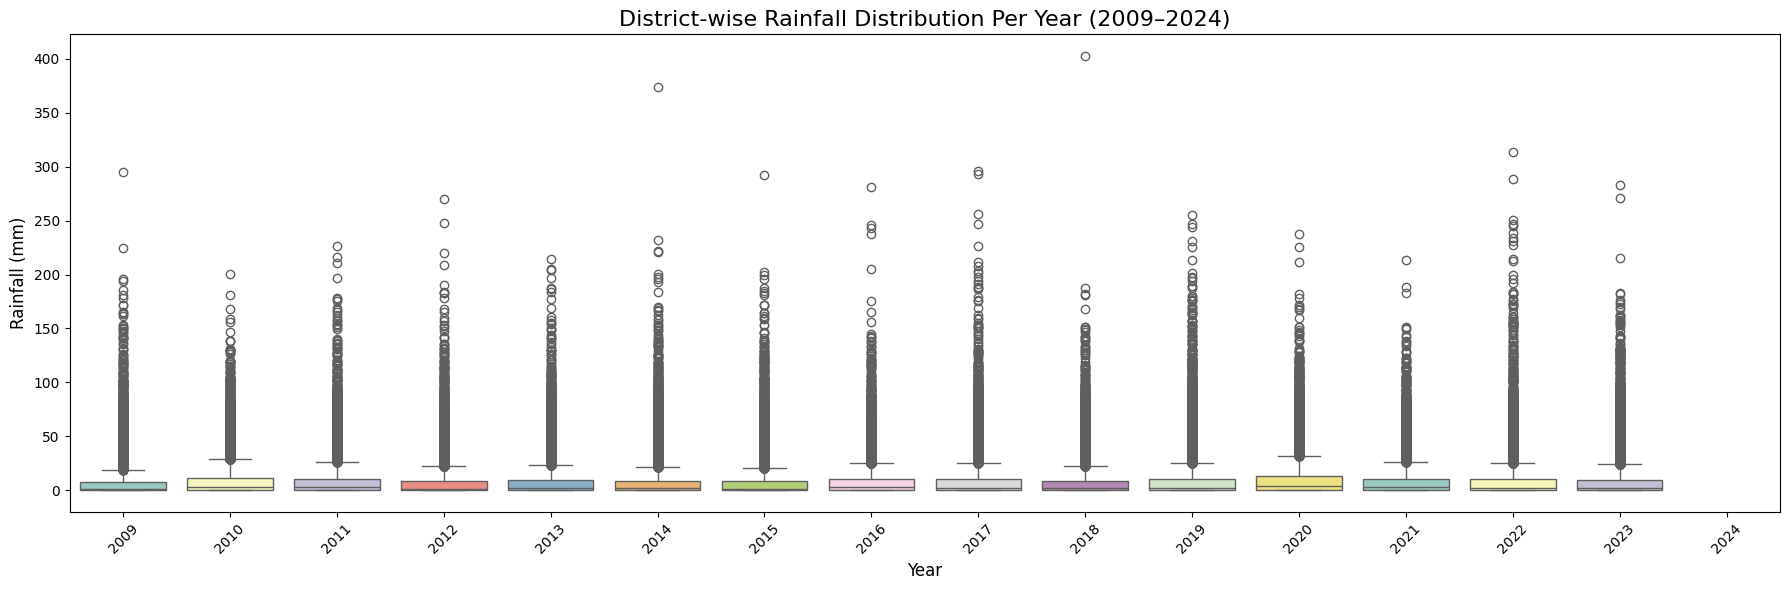

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_2009_2015 = '/content/Districtwise_Rainfall_samya.xlsx'
file_2016_2024 = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'

# Load all sheets from both files
sheets_2009_2015 = pd.read_excel(file_2009_2015, sheet_name=None)
sheets_2016_2024 = pd.read_excel(file_2016_2024, sheet_name=None)

# Combine both dictionaries
all_sheets = {**sheets_2009_2015, **sheets_2016_2024}

# Prepare list for combined data
combined_data = []

for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        df_subset = df[['district_name', 'actual']].copy()
        df_subset['year'] = sheet_name  # Assume sheet name is the year
        combined_data.append(df_subset)
    else:
        print(f"Skipping sheet '{sheet_name}': required columns not found.")

# Merge all years
final_df = pd.concat(combined_data, ignore_index=True)

# Ensure proper order of years
final_df['year'] = final_df['year'].astype(str)
final_df = final_df.sort_values('year')

# Plot the boxplot
plt.figure(figsize=(18, 6))
sns.boxplot(data=final_df, x='year', y='actual', palette='Set3')
plt.title('District-wise Rainfall Distribution Per Year (2009–2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


histograms correct one

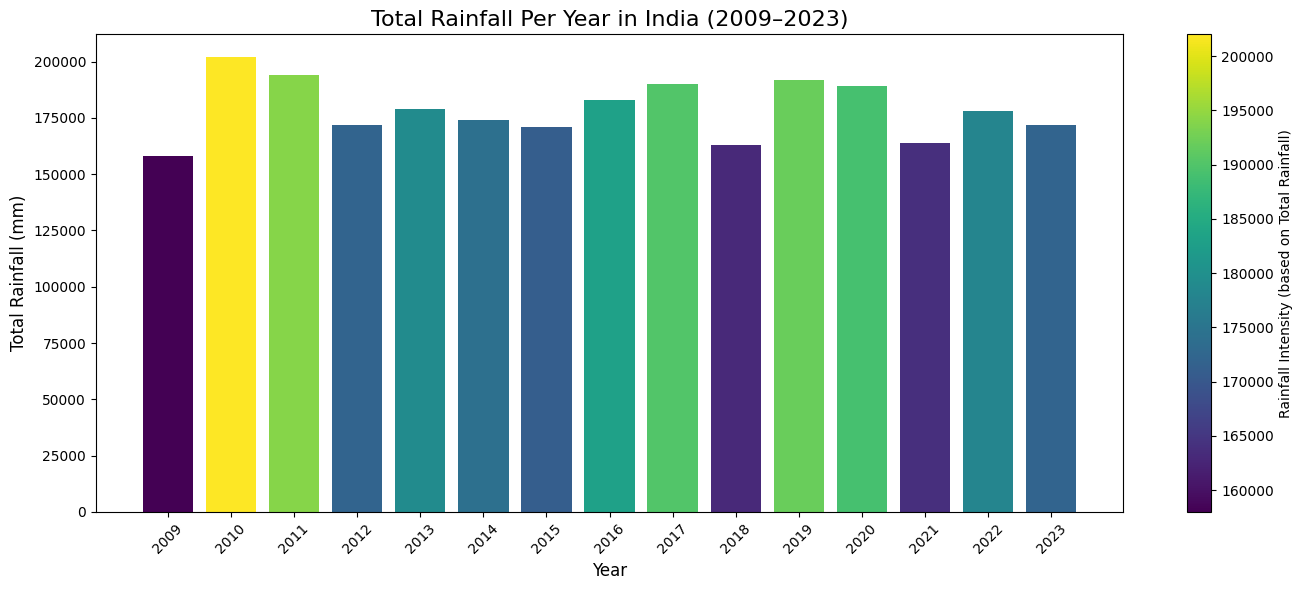

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

# Data
years_1 = ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
rainfall_1 = [158000, 202000, 194000, 172000, 179000, 174000, 171000]

years_2 = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
rainfall_2 = [183000, 190000, 163000, 192000, 189000, 164000, 178000, 172000]

# Combine into DataFrame
years = years_1 + years_2
rainfall = rainfall_1 + rainfall_2
df = pd.DataFrame({'Year': years, 'Total_Rainfall': rainfall})

# Normalize rainfall for colormap
norm = colors.Normalize(vmin=df['Total_Rainfall'].min(), vmax=df['Total_Rainfall'].max())
cmap = cm.viridis
bar_colors = cmap(norm(df['Total_Rainfall']))

# Create plot and axis
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(df['Year'], df['Total_Rainfall'], color=bar_colors)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy mappable to create colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Rainfall Intensity (based on Total Rainfall)')

# Labels and layout
ax.set_title('Total Rainfall Per Year in India (2009–2023)', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# === File Paths ===
file_path = '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'
pdf_path = "Rainfall_Summary_Report(2016-2024).pdf"
excel_summary_path = "Rainfall_Summary_Table(2016-2024).xlsx"

# === Read all sheets ===
all_sheets = pd.read_excel(file_path, sheet_name=None)

# === Store summary statistics here ===
summary_list = []

# === Process each sheet ===
for sheet_name, df in all_sheets.items():
    if 'district_name' in df.columns and 'actual' in df.columns:
        district_rainfall = df.groupby('district_name')['actual'].sum().reset_index()
        rainfall_data = district_rainfall['actual']

        mean = np.mean(rainfall_data)
        median = np.median(rainfall_data)
        std = np.std(rainfall_data)
        skewness = stats.skew(rainfall_data)
        kurtosis = stats.kurtosis(rainfall_data)

        # Log-normality test
        positive_data = rainfall_data[rainfall_data > 0]
        if len(positive_data) > 0:
            log_data = np.log(positive_data)
            _, p_value_log = stats.normaltest(log_data)
        else:
            p_value_log = np.nan

        # Distribution interpretation
        if skewness > 1 and p_value_log > 0.05:
            dist_suggestion = "Lognormal"
        else:
            dist_suggestion = "Approximately Normal"

        # Add row to summary table
        summary_list.append({
            'Year': sheet_name,
            'Mean': round(mean, 2),
            'Median': round(median, 2),
            'Std Dev': round(std, 2),
            'Skewness': round(skewness, 2),
            'Kurtosis': round(kurtosis, 2),
            'Log-Normal p-value': round(p_value_log, 4) if not np.isnan(p_value_log) else 'NA',
            'Distribution Suggestion': dist_suggestion
        })
    else:
        print(f"Skipping sheet '{sheet_name}': required columns not found.")

# === Convert to DataFrame ===
summary_df = pd.DataFrame(summary_list)

# === Save to Excel ===
summary_df.to_excel(excel_summary_path, index=False)

# === Save summary table to PDF ===
with PdfPages(pdf_path) as pdf:
    plt.figure(figsize=(12, 0.5 + 0.3 * len(summary_df)))
    plt.axis('off')
    table = plt.table(cellText=summary_df.values,
                      colLabels=summary_df.columns,
                      loc='center',
                      cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    pdf.savefig()
    plt.close()

print(f"✅ Summary Excel saved: {excel_summary_path}")
print(f"✅ Summary PDF saved: {pdf_path}")


✅ Summary Excel saved: Rainfall_Summary_Table(2016-2024).xlsx
✅ Summary PDF saved: Rainfall_Summary_Report(2016-2024).pdf


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# === File paths ===
file_paths = [
    '/content/Districtwise_Rainfall_Grouped_2009_2015.xlsx',
    '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'
]

summary_list = []

# === Loop through both files ===
for file_path in file_paths:
    all_sheets = pd.read_excel(file_path, sheet_name=None)

    for sheet_name, df in all_sheets.items():
        if 'district_name' in df.columns and 'actual' in df.columns:
            rainfall_data = df.groupby('district_name')['actual'].sum().reset_index()['actual']

            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Test for log-normality (on positive values)
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan

            dist_suggestion = "Lognormal" if skewness > 1 and (p_value_log > 0.05 if not np.isnan(p_value_log) else False) else "Approximately Normal"

            summary_list.append({
                'Year': sheet_name,
                'Mean': round(mean, 2),
                'Median': round(median, 2),
                'Std Dev': round(std, 2),
                'Skewness': round(skewness, 2),
                'Kurtosis': round(kurtosis, 2),
                'Log-Normal p-value': round(p_value_log, 4) if not np.isnan(p_value_log) else 'NA',
                'Distribution Suggestion': dist_suggestion
            })
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

# === Create final summary DataFrame ===
summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.sort_values('Year')  # Sort by year

# === Save to Excel ===
summary_df.to_excel("Rainfall_Combined_Summary_Table(2009-2024).xlsx", index=False)

# === Optional: Save to PDF as table ===
with PdfPages("Rainfall_Combined_Summary_Report(2009-2024).pdf") as pdf:
    plt.figure(figsize=(12, 0.5 + 0.3 * len(summary_df)))
    plt.axis('off')
    table = plt.table(cellText=summary_df.values,
                      colLabels=summary_df.columns,
                      loc='center',
                      cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    pdf.savefig()
    plt.close()

print("✅ Combined summary generated for 2009–2024 in both Excel and PDF.")


✅ Combined summary generated for 2009–2024 in both Excel and PDF.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# === File paths ===
file_paths = [
    '/content/Districtwise_Rainfall_Grouped_2009_2015.xlsx',
    '/content/Districtwise_Rainfall_samya(2016-2024).xlsx'
]

summary_list = []

# === Loop through both files ===
for file_path in file_paths:
    all_sheets = pd.read_excel(file_path, sheet_name=None)

    for sheet_name, df in all_sheets.items():
        if 'district_name' in df.columns and 'actual' in df.columns:
            rainfall_data = df.groupby('district_name')['actual'].sum().reset_index()['actual']

            mean = np.mean(rainfall_data)
            median = np.median(rainfall_data)
            std = np.std(rainfall_data)
            skewness = stats.skew(rainfall_data)
            kurtosis = stats.kurtosis(rainfall_data)

            # Log-normality test
            positive_data = rainfall_data[rainfall_data > 0]
            if len(positive_data) > 0:
                log_data = np.log(positive_data)
                _, p_value_log = stats.normaltest(log_data)
            else:
                p_value_log = np.nan

            dist_suggestion = "Lognormal" if skewness > 1 and (p_value_log > 0.05 if not np.isnan(p_value_log) else False) else "Approximately Normal"

            summary_list.append({
                'Year': sheet_name,
                'Mean': round(mean, 2),
                'Median': round(median, 2),
                'Std Dev': round(std, 2),
                'Skewness': round(skewness, 2),
                'Kurtosis': round(kurtosis, 2),
                'Log-Normal p-value': round(p_value_log, 4) if not np.isnan(p_value_log) else 'NA',
                'Distribution Suggestion': dist_suggestion
            })
        else:
            print(f"Skipping sheet '{sheet_name}': required columns not found.")

# === Create summary table ===
summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.sort_values('Year')

# === Save to Excel ===
summary_df.to_excel("Rainfall_Combined_Summary_Table(2009-2024).xlsx", index=False)

# === Save to PDF (optional) ===
with PdfPages("Rainfall_Combined_Summary_Report(2009-2024).pdf") as pdf:
    plt.figure(figsize=(12, 0.5 + 0.3 * len(summary_df)))
    plt.axis('off')
    table = plt.table(cellText=summary_df.values,
                      colLabels=summary_df.columns,
                      loc='center',
                      cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    pdf.savefig()
    plt.close()

# === Print the table in terminal/output ===
print(summary_df.to_string(index=False))


Year    Mean  Median  Std Dev  Skewness  Kurtosis Log-Normal p-value Distribution Suggestion
2009  838.63  737.14   515.34      2.06      8.61             0.7813               Lognormal
2010 1071.61  927.98   548.88      1.25      2.19             0.0682               Lognormal
2011 1027.07  976.21   599.97      2.03      7.31                0.0    Approximately Normal
2012  913.86  845.08   561.38      1.46      3.26                0.0    Approximately Normal
2013  951.84  886.96   554.10      1.90      6.65             0.8146               Lognormal
2014  923.91  898.06   587.06      1.12      2.13             0.0027    Approximately Normal
2015  906.01  792.76   525.19      1.14      1.26             0.5318               Lognormal
2016  969.49  882.42   578.35      1.12      1.39              0.133               Lognormal
2017 1014.12  877.62   583.72      1.22      1.54             0.5275               Lognormal
2018  864.52  766.64   523.49      1.14      1.94             0.0005  